In [77]:
# Import pandas and load the raw medical insurance CSV dataset into a DataFrame
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("C:\\Users\\Radwa\\Downloads\\archive (1)\\medical_insurance.csv")

df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [2]:
df.describe(include='all')

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,100000,100000,100000,1.000000e+05,100000,100000,100000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
unique,NaN,NaN,3,5,3,NaN,6,4,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Female,South,Urban,NaN,Bachelors,Married,Employed,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,49193,28029,60019,NaN,27996,53252,55269,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,50000.500000,47.521500,NaN,NaN,NaN,4.987390e+04,NaN,NaN,NaN,2.430900,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,NaN,NaN,NaN,4.680021e+04,NaN,NaN,NaN,1.075126,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,NaN,NaN,NaN,1.100000e+03,NaN,NaN,NaN,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,NaN,NaN,NaN,2.110000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,NaN,NaN,NaN,3.620000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,NaN,NaN,NaN,6.220000e+04,NaN,NaN,NaN,3.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000


In [3]:
import warnings
warnings.filterwarnings("ignore")

## cleaning

## Age Validation and Median-Based Imputation Preparation

In this step, the dataset is examined to identify records with unrealistic age values that are likely caused by data entry errors. Individuals younger than 16 or aged 95 and above are flagged as suspicious when their demographic, health, or lifestyle characteristics do not match their reported age. Rather than removing these records, they are marked for further correction.

After excluding the suspicious records, the remaining clean dataset is used to calculate the median age for different demographic groups based on education, employment status, marital status, alcohol consumption, and smoking status. These group-specific median ages provide reliable reference values for replacing suspicious age values. In addition, an overall median age is calculated from the clean dataset to serve as a fallback whenever a matching demographic group is not available during the imputation process

In [4]:
# Flag suspicious rows: people aged 95+ or below MIN_AGE who show signs of being data entry errors
# (e.g., still employed, few medications, no chronic diseases, or active smokers)

MIN_AGE = 16

suspicious_mask = (
    (
        (df['age'] >= 95) |
        (df['age'] < MIN_AGE)
    ) &
    (
        df['employment_status'].isin(['Employed', 'Self-employed']) |
        (df['medication_count'] < 3) |
        (df[['hypertension','diabetes','asthma','copd',
             'cardiovascular_disease','cancer_history',
             'kidney_disease','liver_disease',
             'arthritis','mental_health']].sum(axis=1) == 0) |
        (df['smoker'] == 'Current')
    )
)

df['is_suspicious'] = suspicious_mask
print(f"Suspicious rows: {suspicious_mask.sum()}")

Suspicious rows: 2382


In [5]:
# On the clean (non-suspicious) subset, compute median age grouped by 5 demographic columns
# and also by 4 columns as a fallback — these will be used to impute suspicious ages

clean = df[~df['is_suspicious']].copy()

group5 = ['education', 'employment_status', 'marital_status', 'alcohol_freq', 'smoker']
med5 = clean.groupby(group5)['age'].median().reset_index()
med5.columns = group5 + ['median_5']

group4 = ['education', 'employment_status', 'marital_status', 'alcohol_freq']
med4 = clean.groupby(group4)['age'].median().reset_index()
med4.columns = group4 + ['median_4']

global_med = clean['age'].median()
print(f"Global median age: {global_med}")

Global median age: 48.0


In [6]:
# Merge median tables onto df
df = df.merge(med5, on=group5, how='left')
df = df.merge(med4, on=group4, how='left')

# Pick best available median for each row
imputed_age = df['median_5'].fillna(df['median_4']).fillna(global_med)

# Replace age only for suspicious rows
df['age'] = df['age'].where(~df['is_suspicious'], imputed_age)

# Safety net: enforce the minimum age floor
df['age'] = df['age'].clip(lower=MIN_AGE)

# Drop helper columns
df = df.drop(columns=['median_5', 'median_4'])

In [7]:
print(f"Min age after correction: {df['age'].min()}")
print(f"Max age after correction: {df['age'].max()}")
print(f"Rows still below MIN_AGE: {(df['age'] < MIN_AGE).sum()}")

Min age after correction: 16.0
Max age after correction: 100.0
Rows still below MIN_AGE: 0


In [8]:
print(f"Average age after correction: {df['age'].mean():.2f}")
print(f"Median age after correction: {df['age'].median()}")

Average age after correction: 48.30
Median age after correction: 48.0


In [9]:
print("--- After correction ---")
print(f"Mean: {df['age'].mean():.2f} | Median: {df['age'].median()} | Min: {df['age'].min()} | Max: {df['age'].max()}")

--- After correction ---
Mean: 48.30 | Median: 48.0 | Min: 16.0 | Max: 100.0


In [10]:
# For each suspicious row, look up the most specific contextual median age available
# (5-group match → 4-group match → global median) and store as the replacement age
suspicious_df = df[df['is_suspicious']].copy()

suspicious_df = suspicious_df.merge(med5, on=group5, how='left')

suspicious_df = suspicious_df.merge(med4, on=group4, how='left')

suspicious_df['contextual_median'] = (
    suspicious_df['median_5']
    .combine_first(suspicious_df['median_4'])
    .combine_first(pd.Series(global_med, index=suspicious_df.index))
)

suspicious_df['new_age'] = suspicious_df['contextual_median'].clip(lower=MIN_AGE).round()

print(suspicious_df[['person_id','age','contextual_median','new_age']].head(10))

   person_id   age  contextual_median  new_age
0      76700  48.0               48.0     48.0
1        576  47.0               47.0     47.0
2      30713  48.0               48.0     48.0
3      13800  48.0               48.0     48.0
4       3232  48.0               48.0     48.0
5      15295  49.0               49.0     49.0
6      10981  53.0               53.0     53.0
7      63486  48.0               48.0     48.0
8      33076  48.0               48.0     48.0
9       7678  49.0               49.0     49.0


In [11]:
# Apply the computed replacement ages back to the original DataFrame and remove the flag column

df.loc[df['is_suspicious'], 'age'] = (
    suspicious_df.set_index('person_id')['new_age']
    .reindex(df.loc[df['is_suspicious'], 'person_id'].values)
    .values
)
df.drop(columns=['is_suspicious'], inplace=True)

print("Done!")
print(df['age'].describe())

Done!
count    100000.00000
mean         48.29513
std          14.78946
min          16.00000
25%          38.00000
50%          48.00000
75%          58.00000
max         100.00000
Name: age, dtype: float64


In [12]:

age_missing_mask = df['age'].isna()
print(f" NaN: {age_missing_mask.sum()}")

missing_age_df = df[age_missing_mask].copy()
missing_age_df = missing_age_df.merge(med5, on=group5, how='left')
missing_age_df = missing_age_df.merge(med4, on=group4, how='left')

missing_age_df['contextual_median'] = (
    missing_age_df['median_5']
    .combine_first(missing_age_df['median_4'])
    .combine_first(pd.Series(global_med, index=missing_age_df.index))
)
missing_age_df['new_age'] = missing_age_df['contextual_median'].clip(lower=MIN_AGE).round()

df.loc[age_missing_mask, 'age'] = (
    missing_age_df.set_index('person_id')['new_age']
    .reindex(df.loc[age_missing_mask, 'person_id'].values)
    .values
)

print(f" age: {df['age'].isna().sum()}")

 NaN: 0
 age: 0


## Diabetes and HbA1c Consistency Check

In this step, the dataset is validated to identify inconsistencies between the diabetes diagnosis and the HbA1c laboratory result. According to standard medical guidelines, an HbA1c value below 6.5% does not support a diabetes diagnosis. Therefore, records where diabetes = 1 but HbA1c < 6.5 are flagged as inconsistent. These flagged cases are then corrected by updating the diabetes status to 0, ensuring that the diagnosis aligns with the clinical evidence. Finally, the dataset is rechecked to verify that all inconsistencies have been successfully resolved and no invalid diabetes–HbA1c combinations remain.

In [13]:
# Flag rows where diabetes = 1 but HbA1c < 6.5 (medically inconsistent — not actually diabetic)

flag = (df['diabetes'] == 1) & (df['hba1c'] < 6.5)
df['diabetes_hba1c_flag'] = flag.astype(int)

print(f"Flagged rows: {flag.sum()}")
print(df['diabetes_hba1c_flag'].value_counts())

Flagged rows: 1162
diabetes_hba1c_flag
0    98838
1     1162
Name: count, dtype: int64


In [14]:
# Correct the inconsistency: set diabetes = 0 for flagged rows where HbA1c doesn't support the diagnosis
df.loc[(df['diabetes'] == 1) & (df['hba1c'] < 6.5), 'diabetes'] = 0

In [15]:
# Verify the fix: confirm no remaining diabetes/HbA1c mismatches exist
flag = (df['diabetes'] == 1) & (df['hba1c'] < 6.5)

print(f"Remaining flagged rows: {flag.sum()}")

Remaining flagged rows: 0


In [16]:
# Flag rows where 'had_major_procedure' = 1 but surgery count = 0 (contradictory data)

mismatch = (df['had_major_procedure'] == 1) & (df['proc_surgery_count'] == 0)
df['procedure_mismatch_flag'] = mismatch.astype(int)

print(f"Flagged rows: {mismatch.sum()}")
print(df['procedure_mismatch_flag'].value_counts())

Flagged rows: 4451
procedure_mismatch_flag
0    95549
1     4451
Name: count, dtype: int64


In [17]:
# Correct the mismatch: set had_major_procedure = 0 where no surgery was recorded
df.loc[(df['had_major_procedure'] == 1) & (df['proc_surgery_count'] == 0), 'had_major_procedure'] = 0

In [18]:
# Verify the procedure mismatch fix — should now return 0 remaining conflicts
mismatch = (df['had_major_procedure'] == 1) & (df['proc_surgery_count'] == 0)
print(mismatch.sum())

0


In [19]:

df['alcohol_freq'] = df['alcohol_freq'].fillna('Unknown')

print(df['alcohol_freq'].value_counts())
print(f"alcohol_freq: {df['alcohol_freq'].isna().sum()}")

alcohol_freq
Occasional    45078
Unknown       30083
Weekly        19833
Daily          5006
Name: count, dtype: int64
alcohol_freq: 0


## Modiling

## Star Schema Data Modeling

In this step, the cleaned and transformed dataset is organized into a Star Schema to improve data organization, scalability, and analytical performance. The central fact table (fact_insurance) stores all measurable business metrics, including medical costs, insurance claims, premiums, utilization, and risk indicators. Surrounding it are multiple dimension tables that describe different aspects of the data, such as demographic information, socioeconomic characteristics, lifestyle factors, clinical measurements, chronic diseases, and policy details. The relationships between the fact table and the dimension tables are established using primary and foreign keys, creating a well-structured data model that minimizes redundancy and supports efficient reporting, dashboard creation, and business intelligence analysis. This model provides a clear foundation for performing multidimensional analysis and generating accurate insights from the insurance dataset.

In [20]:
import sys
print(sys.executable)

D:\Anaconda3\python.exe


In [21]:
df.columns.tolist()

['person_id',
 'age',
 'sex',
 'region',
 'urban_rural',
 'income',
 'education',
 'marital_status',
 'employment_status',
 'household_size',
 'dependents',
 'bmi',
 'smoker',
 'alcohol_freq',
 'visits_last_year',
 'hospitalizations_last_3yrs',
 'days_hospitalized_last_3yrs',
 'medication_count',
 'systolic_bp',
 'diastolic_bp',
 'ldl',
 'hba1c',
 'plan_type',
 'network_tier',
 'deductible',
 'copay',
 'policy_term_years',
 'policy_changes_last_2yrs',
 'provider_quality',
 'risk_score',
 'annual_medical_cost',
 'annual_premium',
 'monthly_premium',
 'claims_count',
 'avg_claim_amount',
 'total_claims_paid',
 'chronic_count',
 'hypertension',
 'diabetes',
 'asthma',
 'copd',
 'cardiovascular_disease',
 'cancer_history',
 'kidney_disease',
 'liver_disease',
 'arthritis',
 'mental_health',
 'proc_imaging_count',
 'proc_surgery_count',
 'proc_physio_count',
 'proc_consult_count',
 'proc_lab_count',
 'is_high_risk',
 'had_major_procedure',
 'diabetes_hba1c_flag',
 'procedure_mismatch_flag']

In [22]:
dim_person_info = df[
    [
        "person_id",
        "age",
        "sex",
        "region",
        "urban_rural"
    ]
].copy()

dim_person_info.insert(0, "person_info_key", range(1, len(dim_person_info)+1))

In [23]:
dim_socioeconomic = df[
    [
        "income",
        "education",
        "marital_status",
        "employment_status",
        "household_size",
        "dependents"
    ]
].copy()

dim_socioeconomic.insert(0, "socio_key", range(1, len(dim_socioeconomic)+1))

In [24]:
bins = [0, 18.5, 25, 30, float("inf")]
labels = ["Underweight", "Normal", "Overweight", "Obese"]

df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=bins,
    labels=labels
)

In [25]:
dim_lifestyle = df[
    [
        "bmi",
        "smoker",
        "alcohol_freq"
    ]
].copy()

dim_lifestyle.insert(0, "lifestyle_key", range(1, len(dim_lifestyle)+1))

In [26]:
dim_clinical = df[
    [
        "visits_last_year",
        "hospitalizations_last_3yrs",
        "days_hospitalized_last_3yrs",
        "medication_count",
        "systolic_bp",
        "diastolic_bp",
        "ldl",
        "hba1c"
    ]
].copy()

dim_clinical.insert(0, "clinical_key", range(1, len(dim_clinical)+1))

In [27]:
dim_policy = df[
    [
        "plan_type",
        "network_tier",
        "deductible",
        "copay",
        "policy_term_years",
        "policy_changes_last_2yrs",
        "provider_quality"
    ]
].copy()

dim_policy.insert(0, "policy_key", range(1, len(dim_policy)+1))

In [28]:
dim_chronic = df[
    [
        "chronic_count",
        "hypertension",
        "diabetes",
        "asthma",
        "copd",
        "cardiovascular_disease",
        "cancer_history",
        "kidney_disease",
        "liver_disease",
        "arthritis",
        "mental_health"
    ]
].copy()

dim_chronic.insert(0, "chronic_key", range(1, len(dim_chronic)+1))

In [29]:
import pandas as pd

fact_insurance = pd.DataFrame()

# Primary Key
fact_insurance["insurance_id"] = range(1, len(df) + 1)

# Foreign Keys
fact_insurance["person_info_key"] = dim_person_info["person_info_key"]
fact_insurance["clinical_key"] = dim_clinical["clinical_key"]
fact_insurance["lifestyle_key"] = dim_lifestyle["lifestyle_key"]
fact_insurance["chronic_key"] = dim_chronic["chronic_key"]
fact_insurance["policy_key"] = dim_policy["policy_key"]
fact_insurance["socio_key"] = dim_socioeconomic["socio_key"]

# Measures
fact_insurance["risk_score"] = df["risk_score"]
fact_insurance["annual_medical_cost"] = df["annual_medical_cost"]
fact_insurance["annual_premium"] = df["annual_premium"]
fact_insurance["monthly_premium"] = df["monthly_premium"]
fact_insurance["claims_count"] = df["claims_count"]
fact_insurance["avg_claim_amount"] = df["avg_claim_amount"]
fact_insurance["total_claims_paid"] = df["total_claims_paid"]

fact_insurance.head()

,insurance_id,person_info_key,clinical_key,lifestyle_key,chronic_key,policy_key,socio_key,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid
0,1,1,1,1,1,1,1,0.5714,6938.06,876.05,73.00,1,4672.59,4672.59
1,2,2,2,2,2,2,2,1.0000,1632.61,445.10,37.09,4,297.27,1189.08
2,3,3,3,3,3,3,3,1.0000,7661.01,1538.02,128.17,0,0.00,0.00
3,4,4,4,4,4,4,4,0.2857,5130.27,820.63,68.39,0,0.00,0.00
4,5,5,5,5,5,5,5,0.8681,1700.73,500.93,41.74,1,1002.24,1002.24


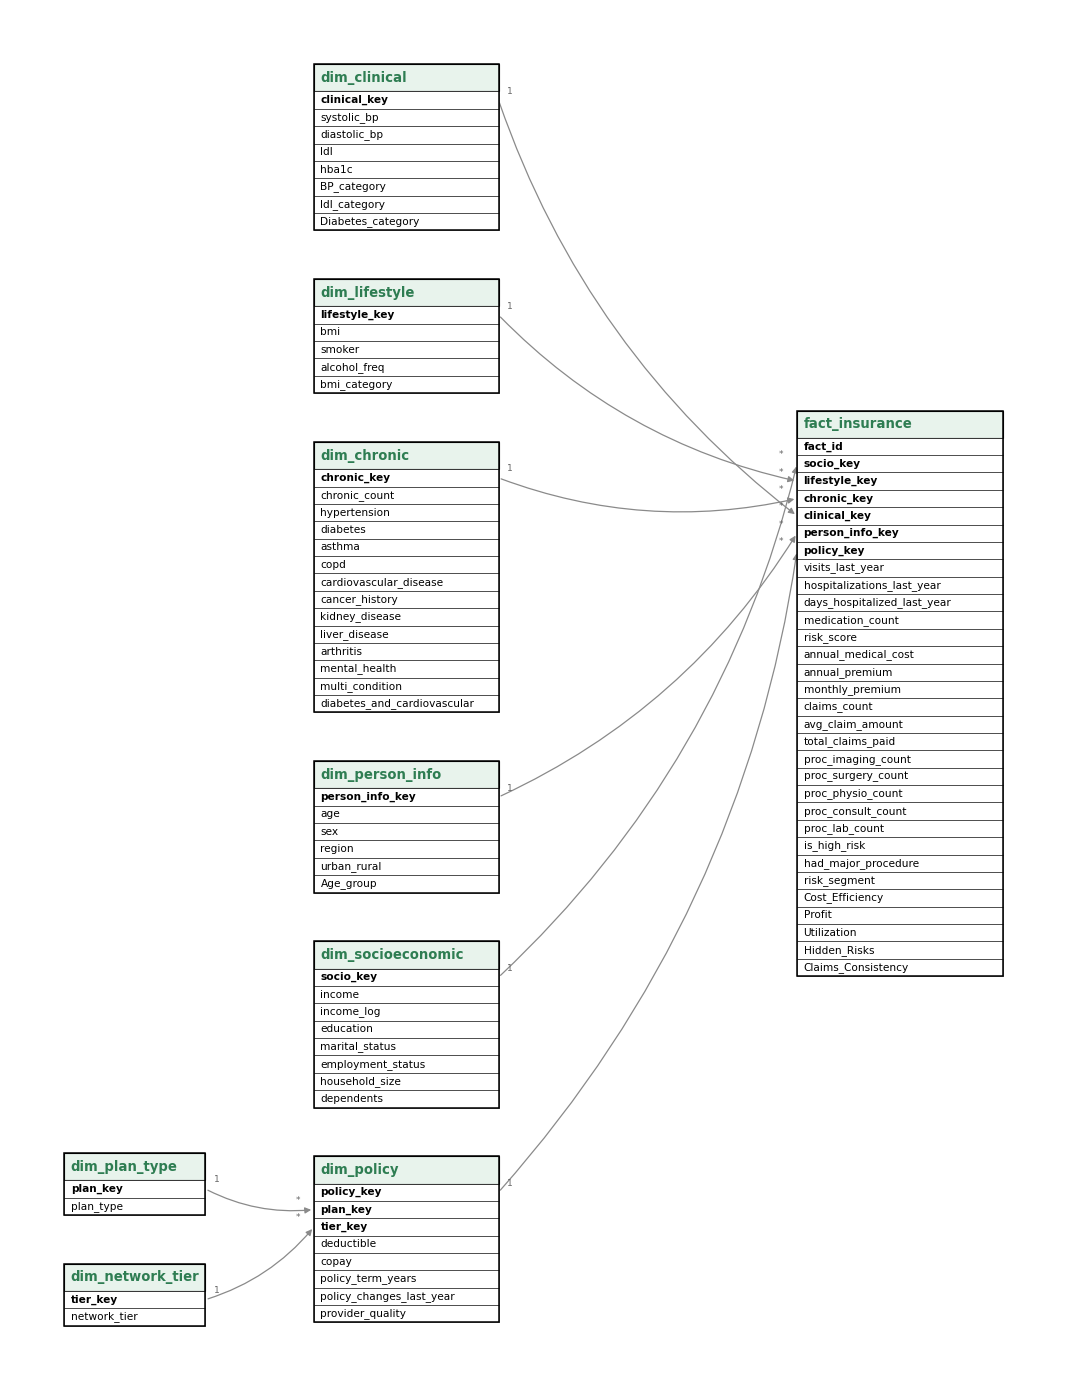

In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

ROW_H = 0.32
HEADER_H = 0.5
HEADER_COLOR = "#E8F3EC"
HEADER_TEXT = "#2E7D52"
LINE_COLOR = "#8A8A8A"


def draw_table(ax, x, y_top, name, fields, width=3.4, key_fields=None):
    key_fields = set(key_fields or [])
    n = len(fields)
    height = HEADER_H + n * ROW_H
    y_bottom = y_top - height

    ax.add_patch(Rectangle((x, y_top - HEADER_H), width, HEADER_H,
                            facecolor=HEADER_COLOR, edgecolor="black",
                            linewidth=0.8, zorder=2))
    ax.text(x + 0.12, y_top - HEADER_H / 2, name, fontsize=9.5,
            fontweight="bold", color=HEADER_TEXT, va="center", ha="left", zorder=3)

    field_y = {}
    for i, f in enumerate(fields):
        row_top = y_top - HEADER_H - i * ROW_H
        row_bottom = row_top - ROW_H
        row_center = (row_top + row_bottom) / 2
        ax.add_patch(Rectangle((x, row_bottom), width, ROW_H,
                                facecolor="white", edgecolor="black",
                                linewidth=0.4, zorder=2))
        weight = "bold" if f in key_fields else "normal"
        ax.text(x + 0.12, row_center, f, fontsize=7.6, va="center", ha="left",
                 fontweight=weight, zorder=3)
        field_y[f] = row_center

    ax.add_patch(Rectangle((x, y_bottom), width, height, facecolor="none",
                            edgecolor="black", linewidth=1.1, zorder=4))

    return {"x0": x, "x1": x + width, "y_top": y_top, "y_bottom": y_bottom,
             "fields": field_y, "height": height}


def connect(ax, box_a, field_a, box_b, field_b, rad=0.15):
    y_a = box_a["fields"][field_a]
    y_b = box_b["fields"][field_b]
    if box_a["x1"] <= box_b["x0"]:
        p1 = (box_a["x1"], y_a)
        p2 = (box_b["x0"], y_b)
    else:
        p1 = (box_a["x0"], y_a)
        p2 = (box_b["x1"], y_b)
    arrow = FancyArrowPatch(p1, p2, connectionstyle=f"arc3,rad={rad}",
                              arrowstyle="-|>", mutation_scale=9,
                              color=LINE_COLOR, linewidth=0.9, zorder=1)
    ax.add_patch(arrow)
    ax.text(p1[0] + (0.15 if p1[0] < p2[0] else -0.15), y_a + 0.12, "1",
             fontsize=6.5, color="#666666", ha="left" if p1[0] < p2[0] else "right")
    ax.text(p2[0] + (-0.25 if p1[0] < p2[0] else 0.25), y_b + 0.12, "*",
             fontsize=6.5, color="#666666", ha="right" if p1[0] < p2[0] else "left")


tables_def = {
    "dim_clinical": (["clinical_key", "systolic_bp", "diastolic_bp", "ldl", "hba1c",
                       "BP_category", "ldl_category", "Diabetes_category"], ["clinical_key"]),
    "dim_lifestyle": (["lifestyle_key", "bmi", "smoker", "alcohol_freq", "bmi_category"],
                       ["lifestyle_key"]),
    "dim_chronic": (["chronic_key", "chronic_count", "hypertension", "diabetes", "asthma",
                      "copd", "cardiovascular_disease", "cancer_history", "kidney_disease",
                      "liver_disease", "arthritis", "mental_health", "multi_condition",
                      "diabetes_and_cardiovascular"], ["chronic_key"]),
    "dim_person_info": (["person_info_key", "age", "sex", "region", "urban_rural", "Age_group"],
                          ["person_info_key"]),
    "dim_socioeconomic": (["socio_key", "income", "income_log", "education", "marital_status",
                            "employment_status", "household_size", "dependents"], ["socio_key"]),
    "dim_policy": (["policy_key", "plan_key", "tier_key", "deductible", "copay",
                     "policy_term_years", "policy_changes_last_year", "provider_quality"],
                     ["policy_key", "plan_key", "tier_key"]),
    "dim_plan_type": (["plan_key", "plan_type"], ["plan_key"]),
    "dim_network_tier": (["tier_key", "network_tier"], ["tier_key"]),
    "fact_insurance": (["fact_id", "socio_key", "lifestyle_key", "chronic_key", "clinical_key",
                         "person_info_key", "policy_key", "visits_last_year",
                         "hospitalizations_last_year", "days_hospitalized_last_year",
                         "medication_count", "risk_score", "annual_medical_cost",
                         "annual_premium", "monthly_premium", "claims_count",
                         "avg_claim_amount", "total_claims_paid", "proc_imaging_count",
                         "proc_surgery_count", "proc_physio_count", "proc_consult_count",
                         "proc_lab_count", "is_high_risk", "had_major_procedure",
                         "risk_segment", "Cost_Efficiency", "Profit", "Utilization",
                         "Hidden_Risks", "Claims_Consistency"],
                         ["fact_id", "socio_key", "lifestyle_key", "chronic_key",
                          "clinical_key", "person_info_key", "policy_key"]),
}

fig, ax = plt.subplots(figsize=(16, 14))

left_order = ["dim_clinical", "dim_lifestyle", "dim_chronic",
              "dim_person_info", "dim_socioeconomic", "dim_policy"]
GAP = 0.9
x_left = 0.0
cursor_y = 0.0
boxes = {}

for name in left_order:
    fields, keys = tables_def[name]
    box = draw_table(ax, x_left, cursor_y, name, fields, width=3.4, key_fields=keys)
    boxes[name] = box
    cursor_y = box["y_bottom"] - GAP

left_top = 0.0
left_bottom = cursor_y + GAP
left_center = (left_top + left_bottom) / 2

policy_box = boxes["dim_policy"]
policy_center = (policy_box["y_top"] + policy_box["y_bottom"]) / 2

sub_names = ["dim_plan_type", "dim_network_tier"]
sub_heights = [HEADER_H + len(tables_def[n][0]) * ROW_H for n in sub_names]
sub_total = sum(sub_heights) + GAP * (len(sub_names) - 1)
sub_cursor_y = policy_center + sub_total / 2
x_sub = x_left - 4.6
for name in sub_names:
    fields, keys = tables_def[name]
    box = draw_table(ax, x_sub, sub_cursor_y, name, fields, width=2.6, key_fields=keys)
    boxes[name] = box
    sub_cursor_y = box["y_bottom"] - GAP

fact_fields, fact_keys = tables_def["fact_insurance"]
fact_height = HEADER_H + len(fact_fields) * ROW_H
x_fact = x_left + 3.4 + 5.5
fact_y_top = left_center + fact_height / 2
boxes["fact_insurance"] = draw_table(ax, x_fact, fact_y_top, "fact_insurance",
                                       fact_fields, width=3.8, key_fields=fact_keys)

relationships = [
    ("dim_clinical", "clinical_key", "fact_insurance", "clinical_key"),
    ("dim_lifestyle", "lifestyle_key", "fact_insurance", "lifestyle_key"),
    ("dim_chronic", "chronic_key", "fact_insurance", "chronic_key"),
    ("dim_person_info", "person_info_key", "fact_insurance", "person_info_key"),
    ("dim_socioeconomic", "socio_key", "fact_insurance", "socio_key"),
    ("dim_policy", "policy_key", "fact_insurance", "policy_key"),
    ("dim_plan_type", "plan_key", "dim_policy", "plan_key"),
    ("dim_network_tier", "tier_key", "dim_policy", "tier_key"),
]
for t1, f1, t2, f2 in relationships:
    connect(ax, boxes[t1], f1, boxes[t2], f2)

all_x0 = min(b["x0"] for b in boxes.values())
all_x1 = max(b["x1"] for b in boxes.values())
all_top = max(b["y_top"] for b in boxes.values())
all_bottom = min(b["y_bottom"] for b in boxes.values())
ax.set_xlim(all_x0 - 1, all_x1 + 1)
ax.set_ylim(all_bottom - 1, all_top + 1)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.savefig("star_schema.png", dpi=200, bbox_inches="tight")
plt.show()

## Data Preprocessing

In [31]:
# Imports needed for all the charts below
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [32]:
# Count and print the total number of rows in the dataset
total_rows = len(df)
print(total_rows)

100000


In [33]:
print(df.head(10))

   person_id   age     sex   region urban_rural    income     education  \
0      75722  52.0  Female    North    Suburban   22700.0     Doctorate   
1      80185  79.0  Female    North       Urban   12800.0         No HS   
2      19865  68.0    Male    North       Rural   40700.0            HS   
3      76700  48.0    Male    North    Suburban   15600.0  Some College   
4      92992  53.0    Male  Central    Suburban   89600.0     Doctorate   
5      76435  63.0  Female    North       Rural  305000.0            HS   
6      84005  36.0    Male     West       Rural   38900.0       Masters   
7      80918  21.0  Female    South    Suburban   83700.0            HS   
8      60768  53.0    Male    North    Suburban   60700.0         No HS   
9      50075  28.0    Male    South       Urban   23600.0     Bachelors   

  marital_status employment_status  household_size  ...  proc_imaging_count  \
0        Married           Retired               3  ...                   1   
1        Married

In [34]:
df.describe(include='all')


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,diabetes_hba1c_flag,procedure_mismatch_flag,bmi_category
count,100000.000000,100000.00000,100000,100000,100000,1.000000e+05,100000,100000,100000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000
unique,NaN,NaN,3,5,3,NaN,6,4,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,Female,South,Urban,NaN,Bachelors,Married,Employed,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Overweight
freq,NaN,NaN,49193,28029,60019,NaN,27996,53252,55269,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37996
mean,50000.500000,48.29513,NaN,NaN,NaN,4.987390e+04,NaN,NaN,NaN,2.430900,...,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.125190,0.011620,0.044510,NaN
std,28867.657797,14.78946,NaN,NaN,NaN,4.680021e+04,NaN,NaN,NaN,1.075126,...,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.330936,0.107169,0.206226,NaN
min,1.000000,16.00000,NaN,NaN,NaN,1.100000e+03,NaN,NaN,NaN,1.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,25000.750000,38.00000,NaN,NaN,NaN,2.110000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,50000.500000,48.00000,NaN,NaN,NaN,3.620000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,75000.250000,58.00000,NaN,NaN,NaN,6.220000e+04,NaN,NaN,NaN,3.000000,...,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000,0.000000,0.000000,NaN


In [36]:
# 1) Missing values: count + percentage per column (columns with 0 missing values are hidden)
missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values(
    "missing_pct", ascending=False
)

print(f"Number of columns with missing values: {len(missing_report)} out of {df.shape[1]}")
missing_report


Number of columns with missing values: 0 out of 57


,missing_count,missing_pct


In [37]:
# 2) Duplicate rows: full-row duplicates, and duplicate person_id if that column exists
full_duplicates = df.duplicated().sum()
print(f"Fully duplicated rows: {full_duplicates}")

duplicate_ids = 0
if "person_id" in df.columns:
    duplicate_ids = df["person_id"].duplicated().sum()
    print(f"Duplicate person_id values: {duplicate_ids}")
else:
    print("No 'person_id' column found, skipping ID-duplicate check.")


Fully duplicated rows: 0
Duplicate person_id values: 0


In [38]:
 #3) Suspicious values in key numeric columns: zeros/negatives where they shouldn't logically happen
numeric_checks = {
    "age": {"min_valid": 1, "max_valid": 110},
    "income": {"min_valid": 1, "max_valid": None},
    "bmi": {"min_valid": 10, "max_valid": 70},
    "household_size": {"min_valid": 1, "max_valid": None},
    "annual_medical_cost": {"min_valid": 0, "max_valid": None},
    "annual_premium": {"min_valid": 0, "max_valid": None},
}

numeric_issues = {}

for col, bounds in numeric_checks.items():
    if col not in df.columns:
        continue
    bad_mask = pd.Series(False, index=df.index)
    if bounds["min_valid"] is not None:
        bad_mask |= df[col] < bounds["min_valid"]
    if bounds["max_valid"] is not None:
        bad_mask |= df[col] > bounds["max_valid"]

    n_bad = int(bad_mask.sum())
    if n_bad > 0:
        numeric_issues[col] = n_bad
        print(f"  {col}: {n_bad} row(s) outside the plausible range "
              f"({bounds['min_valid']} to {bounds['max_valid'] if bounds['max_valid'] else '∞'})")
    else:
        print(f" {col}: all values look plausible")

print()
if numeric_issues:
    worst_col = max(numeric_issues, key=numeric_issues.get)
    print(f"Example rows with the issue (column: {worst_col}):")
    display(df[df[worst_col] < numeric_checks[worst_col]["min_valid"]].head() if numeric_checks[worst_col]["min_valid"] is not None else df.head(0))


 age: all values look plausible
 income: all values look plausible
 bmi: all values look plausible
 household_size: all values look plausible
 annual_medical_cost: all values look plausible
 annual_premium: all values look plausible



In [39]:
# 4) Categorical consistency: catch values that look duplicated due to spelling/case/whitespace
# e.g. "Urban", "urban", "Urban " would all be treated as different categories by mistake
cat_cols = df.select_dtypes(include=["object", "category"]).columns

categorical_issues = {}

for col in cat_cols:
    values = df[col].dropna().unique()
    normalized = pd.Series(values).astype(str).str.strip().str.lower()
    n_unique_raw = len(values)
    n_unique_normalized = normalized.nunique()

    if n_unique_normalized < n_unique_raw:
        categorical_issues[col] = sorted(values.tolist(), key=str)
        print(f" {col}: {n_unique_raw} raw categories but only {n_unique_normalized} "
              f"after trimming spaces/case → likely duplicate labels")
        print(f"    Values: {sorted(values.tolist(), key=str)}")
    else:
        print(f" {col}: {n_unique_raw} clean category/categories")


 sex: 3 clean category/categories
 region: 5 clean category/categories
 urban_rural: 3 clean category/categories
 education: 6 clean category/categories
 marital_status: 4 clean category/categories
 employment_status: 4 clean category/categories
 smoker: 3 clean category/categories
 alcohol_freq: 4 clean category/categories
 plan_type: 4 clean category/categories
 network_tier: 4 clean category/categories
 bmi_category: 4 clean category/categories


In [40]:
# 5) Logical consistency: flags that contradict each other (e.g. age = 0 but married/employed)
logic_issues = {}

if "age" in df.columns:
    age_zero = df[df["age"] == 0]
    if len(age_zero) > 0:
        contradiction_mask = pd.Series(False, index=age_zero.index)
        if "marital_status" in df.columns:
            contradiction_mask |= age_zero["marital_status"].astype(str).str.lower().eq("married")
        if "employment_status" in df.columns:
            contradiction_mask |= age_zero["employment_status"].astype(str).str.lower().isin(
                ["employed", "self-employed"]
            )
        n_contradictions = int(contradiction_mask.sum())
        logic_issues["age == 0"] = len(age_zero)
        print(f"  age == 0: {len(age_zero)} row(s) total, "
              f"{n_contradictions} of them are married/employed (impossible for a newborn)")
    else:
        print(" No rows with age == 0")

if "household_size" in df.columns and "marital_status" in df.columns:
    bad_household = df[
        (df["household_size"] == 0)
    ]
    if len(bad_household) > 0:
        logic_issues["household_size == 0"] = len(bad_household)
        print(f"  household_size == 0: {len(bad_household)} row(s) — a household can't have 0 people")
    else:
        print(" No rows with household_size == 0")

if "is_high_risk" in df.columns and "risk_score" in df.columns:
    low_threshold = df["risk_score"].quantile(0.10)
    inconsistent_risk = df[(df["is_high_risk"] == 1) & (df["risk_score"] <= low_threshold)]
    if len(inconsistent_risk) > 0:
        logic_issues["is_high_risk vs risk_score"] = len(inconsistent_risk)
        print(f" is_high_risk = 1 but risk_score is in the bottom 10%: {len(inconsistent_risk)} row(s) — worth a second look")
    else:
        print("is_high_risk is consistent with risk_score")

 No rows with age == 0
 No rows with household_size == 0
is_high_risk is consistent with risk_score


In [41]:
# 6) Final summary — one clear verdict combining all the checks above
total_issues = (
    len(missing_report)
    + (1 if full_duplicates > 0 else 0)
    + (1 if duplicate_ids > 0 else 0)
    + len(numeric_issues)
    + len(categorical_issues)
    + len(logic_issues)
)

print("=" * 50)
print("DATA QUALITY SUMMARY")
print("=" * 50)

if total_issues == 0:
    print(" No missing values, duplicates, out-of-range\n"
          "   values, inconsistent categories, or logical contradictions found.")
else:
    print(f" Found {total_issues} issue type(s) that need attention:\n")
    if len(missing_report) > 0:
        print(f"  • Missing values in {len(missing_report)} column(s)")
    if full_duplicates > 0:
        print(f"  • {full_duplicates} fully duplicated row(s)")
    if duplicate_ids > 0:
        print(f"  • {duplicate_ids} duplicate person_id value(s)")
    for col, n in numeric_issues.items():
        print(f"  • {col}: {n} value(s) outside the plausible range")
    for col in categorical_issues:
        print(f"  • {col}: inconsistent category labels (spelling/case/whitespace)")
    for issue, n in logic_issues.items():
        print(f"  • {issue}: {n} row(s) logically inconsistent")
  


DATA QUALITY SUMMARY
 No missing values, duplicates, out-of-range
   values, inconsistent categories, or logical contradictions found.


In [42]:
print(missing_report)

Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []


## Analisiys

## summary statistics: min/max/avg medical cost, avg BMI, and age range

{'min_cost': 55.55, 'max_cost': 65724.9, 'avg_cost': 3009.45, 'avg_bmi': 26.99, 'min_age': 0, 'max_age': 100}


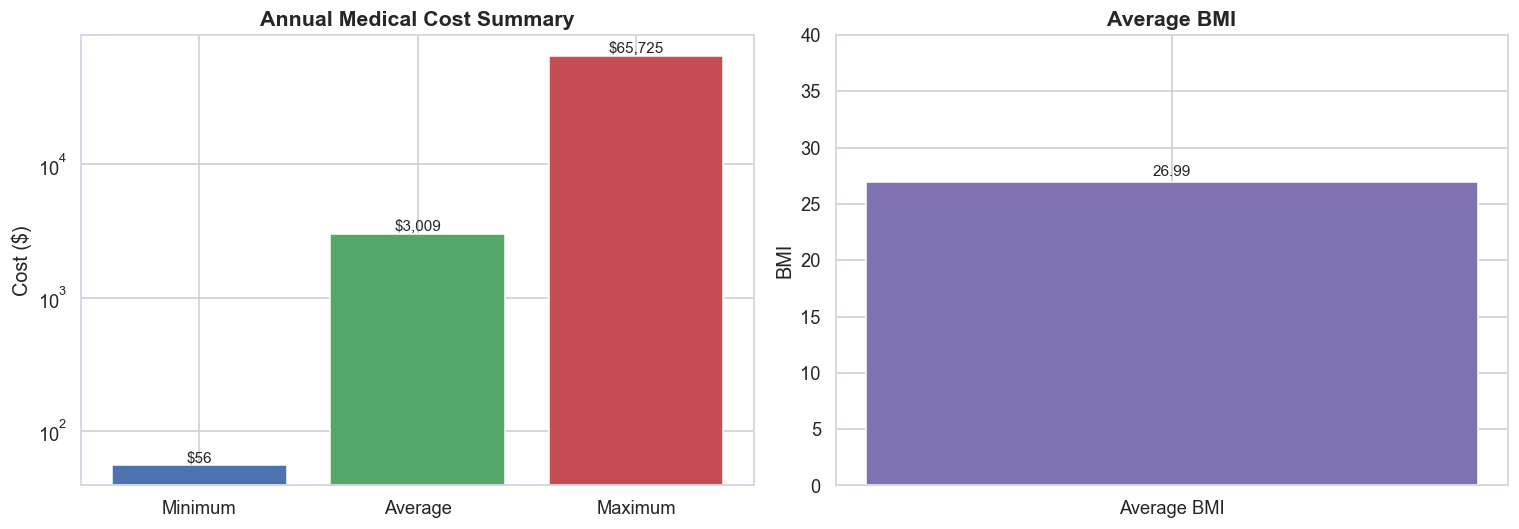

In [78]:
import matplotlib.pyplot as plt

# Summary Statistics
summary = {
    "min_cost": float(df["annual_medical_cost"].min()),
    "max_cost": float(df["annual_medical_cost"].max()),
    "avg_cost": float(round(df["annual_medical_cost"].mean(), 2)),
    "avg_bmi": float(round(df["bmi"].mean(), 2)),
    "min_age": int(df["age"].min()),
    "max_age": int(df["age"].max())
}

print(summary)

# -----------------------------
# Visualization
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Annual Medical Cost Summary
labels = ["Minimum", "Average", "Maximum"]
values = [
    summary["min_cost"],
    summary["avg_cost"],
    summary["max_cost"]
]
colors = ["#4C72B0", "#55A868", "#C44E52"]

bars = axes[0].bar(labels, values, color=colors)

axes[0].set_title("Annual Medical Cost Summary", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Cost ($)")
axes[0].set_yscale("log")  
# Display values above bars
for bar in bars:
    y = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"${y:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Average BMI
bmi_bar = axes[1].bar(
    ["Average BMI"],
    [summary["avg_bmi"]],
    color="#8172B2",
    width=0.5
)

axes[1].set_ylim(0, 40)
axes[1].set_title("Average BMI", fontsize=14, fontweight="bold")
axes[1].set_ylabel("BMI")

for bar in bmi_bar:
    y = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        y + 0.5,
        f"{y:.2f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## average and max cost by smoking status

         total_people  avg_cost  max_cost
smoker                                   
Current         12128   4295.56  65724.90
Former          18163   3161.77  65431.24
Never           69709   2746.01  53168.71


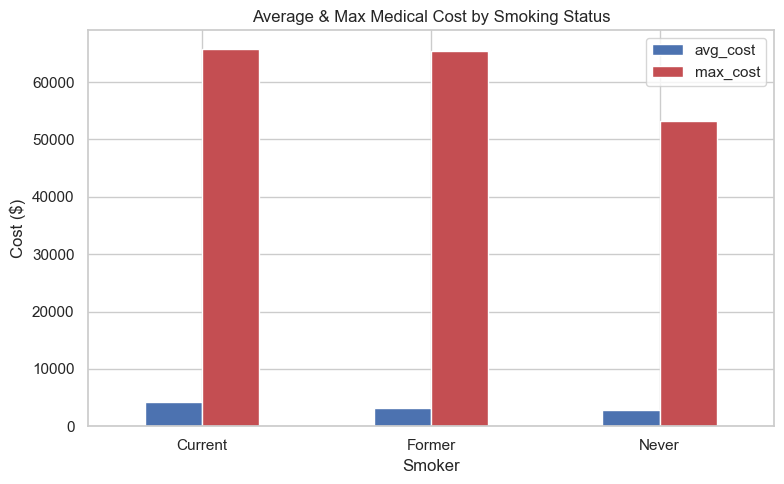

In [44]:
smoker_analysis = df.groupby("smoker").agg(
    total_people=("smoker", "count"),
    avg_cost=("annual_medical_cost", "mean"),
    max_cost=("annual_medical_cost", "max")
).round(2)

print(smoker_analysis)
# Chart: average and max cost by smoking status
smoker_analysis[["avg_cost", "max_cost"]].plot(kind="bar", figsize=(8, 5), color=["#4C72B0", "#C44E52"])
plt.title("Average & Max Medical Cost by Smoking Status")
plt.ylabel("Cost ($)")
plt.xlabel("Smoker")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Group by region and compute count, average cost, and average BMI — sorted by highest cost

         total_people  avg_cost  avg_bmi
region                                  
South           28029   3044.08    26.97
West            17879   3022.91    27.00
North           22027   3002.01    27.00
East            19984   2981.96    26.98
Central         12081   2968.24    27.03


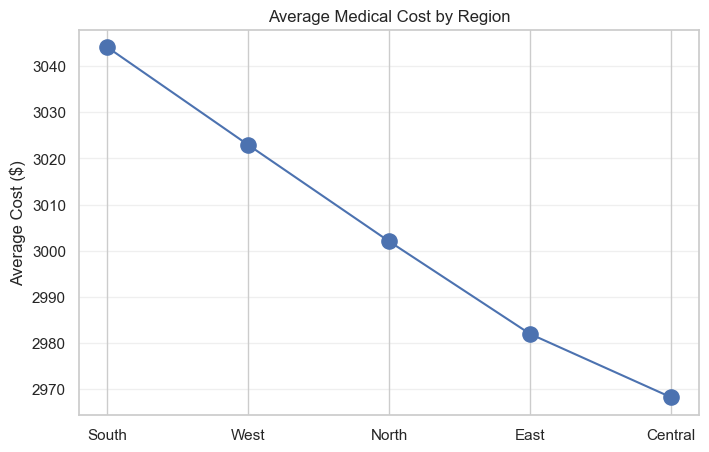

In [45]:
region_analysis = df.groupby("region").agg(
    total_people=("region", "count"),
    avg_cost=("annual_medical_cost", "mean"),
    avg_bmi=("bmi", "mean")
).round(2).sort_values("avg_cost", ascending=False)

print(region_analysis)
# Chart: average cost by region (sorted)
plt.figure(figsize=(8,5))

plt.scatter(
    region_analysis.index,
    region_analysis["avg_cost"],
    s=120
)

plt.plot(
    region_analysis.index,
    region_analysis["avg_cost"]
)

plt.title("Average Medical Cost by Region")
plt.ylabel("Average Cost ($)")
plt.grid(axis="y", alpha=0.3)

plt.show()

## Medical Cost Distribution by Sex

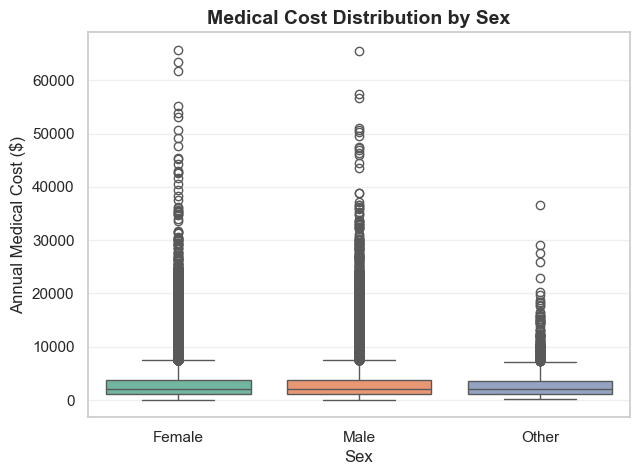

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="sex",
    y="annual_medical_cost",
    palette="Set2"
)

plt.title("Medical Cost Distribution by Sex", fontsize=14, fontweight="bold")
plt.xlabel("Sex")
plt.ylabel("Annual Medical Cost ($)")
plt.grid(axis="y", alpha=0.3)

plt.show()

## average cost by number of chronic conditions

               total_people  avg_cost
chronic_count                        
0                     46532   2176.33
1                     37579   3332.01
2                     13111   4438.19
3                      2452   5671.43
4                       316   7320.43
5                         9   3885.15
6                         1  18747.81


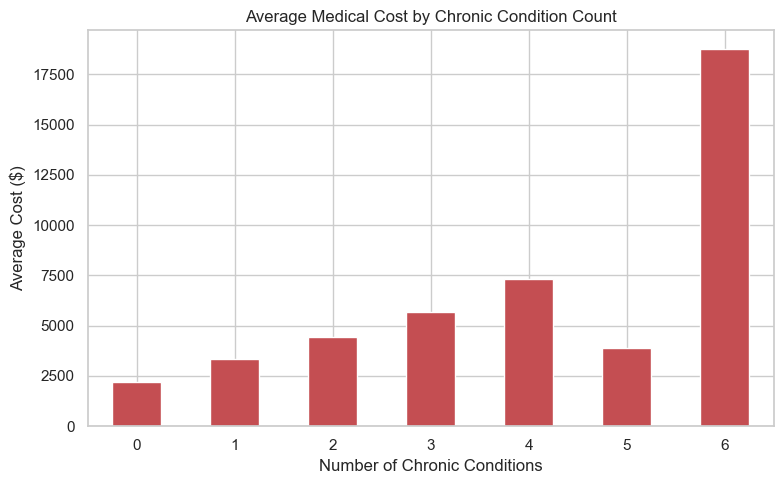

In [47]:

chronic_analysis = df.groupby("chronic_count").agg(
    total_people=("chronic_count", "count"),
    avg_cost=("annual_medical_cost", "mean")
).round(2)

print(chronic_analysis)
# Chart: average cost by number of chronic conditions
chronic_analysis["avg_cost"].plot(kind="bar", color="#C44E52")
plt.title("Average Medical Cost by Chronic Condition Count")
plt.xlabel("Number of Chronic Conditions")
plt.ylabel("Average Cost ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


              total  avg_cost
bmi_category                 
Underweight    4504   2689.86
Normal        30468   2897.04
Overweight    37996   3016.56
Obese         27032   3179.41


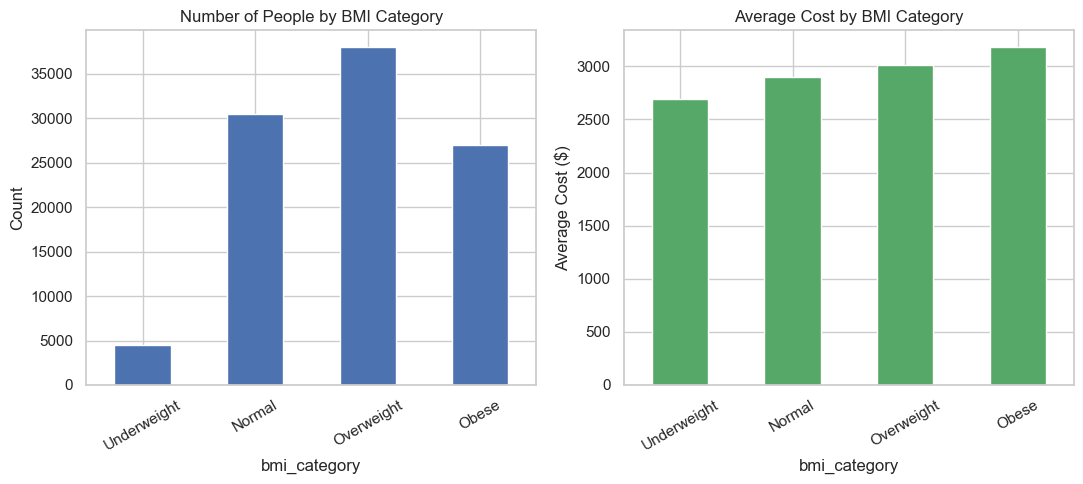

In [48]:
bmi_analysis = df.groupby(
    "bmi_category",
    observed=True
).agg(
    total=("bmi_category", "count"),
    avg_cost=("annual_medical_cost", "mean")
).round(2)

print(bmi_analysis)
# Chart: total people and average cost by BMI category
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
bmi_analysis["total"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Number of People by BMI Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

bmi_analysis["avg_cost"].plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Average Cost by BMI Category")
axes[1].set_ylabel("Average Cost ($)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## Classify each person into an age group, then compute count and average cost per group

           total  avg_cost
age_group                 
Elder      22660   3563.80
Middle     29510   2720.86
Senior     36996   3067.21
Young      10834   2438.88


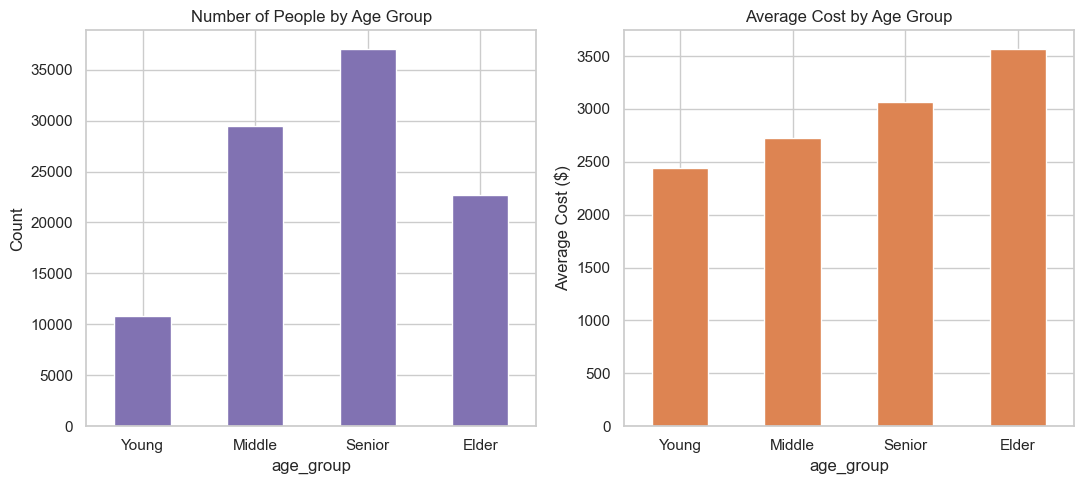

In [49]:
def age_group(age):
    if age < 30:
        return "Young"
    elif age < 45:
        return "Middle"
    elif age < 60:
        return "Senior"
    else:
        return "Elder"

df["age_group"] = df["age"].apply(age_group)

age_analysis = df.groupby("age_group").agg(
    total=("age_group", "count"),
    avg_cost=("annual_medical_cost", "mean")
).round(2)

print(age_analysis)
# Chart: total people and average cost by age group
age_order = ["Young", "Middle", "Senior", "Elder"]
age_analysis_ordered = age_analysis.reindex(
    [g for g in age_order if g in age_analysis.index]
)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
age_analysis_ordered["total"].plot(kind="bar", ax=axes[0], color="#8172B2")
axes[0].set_title("Number of People by Age Group")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

age_analysis_ordered["avg_cost"].plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Average Cost by Age Group")
axes[1].set_ylabel("Average Cost ($)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## analyze smoking status and BMI category together to see combined effect on cost

                      total  avg_cost
smoker  bmi_category                 
Current Underweight     560   3923.72
        Normal         3849   4151.45
        Overweight     4540   4304.25
        Obese          3179   4523.14
Former  Underweight     799   2948.00
        Normal         5430   3056.06
        Overweight     6940   3149.17
        Obese          4994   3328.41
Never   Underweight    3145   2404.57
        Normal        21189   2628.42
        Overweight    26516   2761.38
        Obese         18859   2913.44


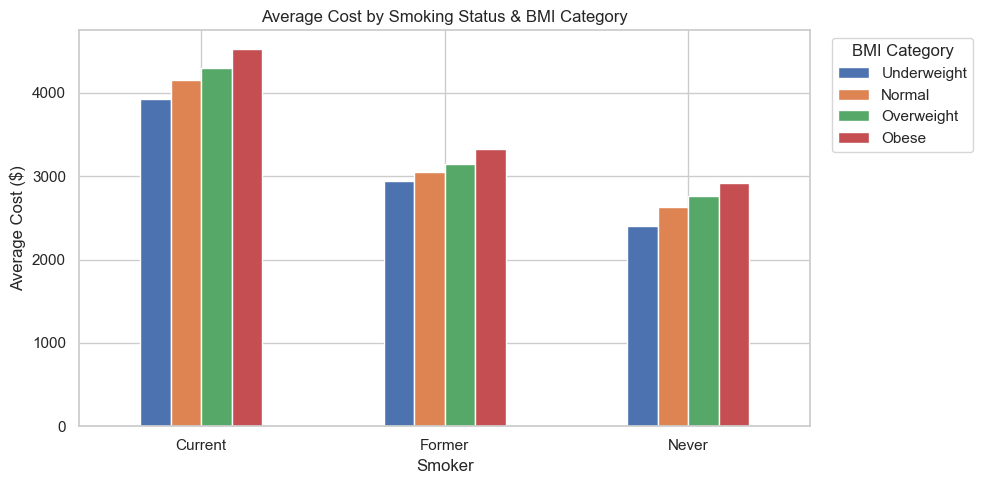

In [50]:
combo = df.groupby(["smoker", "bmi_category"]).agg(
    total=("smoker", "count"),
    avg_cost=("annual_medical_cost", "mean")
).round(2)

print(combo)
# Chart: average cost by smoking status and BMI category (combined)
combo_unstacked = combo["avg_cost"].unstack("bmi_category")
combo_unstacked.plot(kind="bar", figsize=(10, 5))
plt.title("Average Cost by Smoking Status & BMI Category")
plt.xlabel("Smoker")
plt.ylabel("Average Cost ($)")
plt.xticks(rotation=0)
plt.legend(title="BMI Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Bucket each person's annual cost into predefined ranges and count how many fall in each

cost_range
0-5K       84729
5K-10K     11863
10K-20K     2966
20K-50K      429
50K+          13
Name: count, dtype: int64


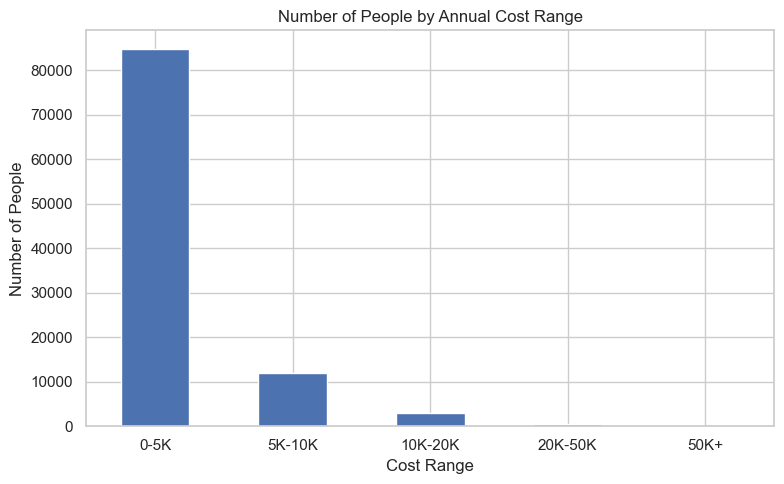

In [51]:
bins = [0, 5000, 10000, 20000, 50000, float("inf")]
labels = ["0-5K", "5K-10K", "10K-20K", "20K-50K", "50K+"]

df["cost_range"] = pd.cut(
    df["annual_medical_cost"],
    bins=bins,
    labels=labels
)

print(df["cost_range"].value_counts().sort_index())
# Chart: number of people in each annual cost range
df["cost_range"].value_counts().sort_index().plot(kind="bar", color="#4C72B0")
plt.title("Number of People by Annual Cost Range")
plt.xlabel("Cost Range")
plt.ylabel("Number of People")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Filter only above-average-cost individuals, then group by smoking, sex, and age group

     smoker     sex age_group  high_cost_cases
0   Current  Female     Elder              788
1   Current  Female    Middle              782
2   Current  Female    Senior             1198
3   Current  Female     Young              272
4   Current    Male     Elder              766
5   Current    Male    Middle              826
6   Current    Male    Senior             1130
7   Current    Male     Young              247
8   Current   Other     Elder               28
9   Current   Other    Middle               30
10  Current   Other    Senior               50
11  Current   Other     Young               14
12   Former  Female     Elder              877
13   Former  Female    Middle              845
14   Former  Female    Senior             1208
15   Former  Female     Young              270
16   Former    Male     Elder              895
17   Former    Male    Middle              821
18   Former    Male    Senior             1211
19   Former    Male     Young              243
20   Former  

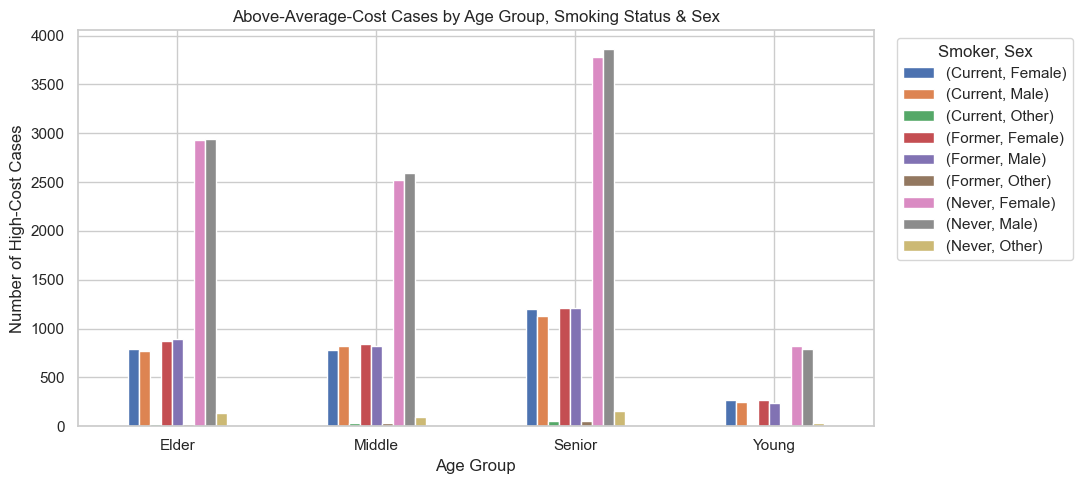

In [52]:
avg_cost = df["annual_medical_cost"].mean()

high_cost = df[df["annual_medical_cost"] > avg_cost]

result = high_cost.groupby(
    ["smoker", "sex", "age_group"]
).size().reset_index(name="high_cost_cases")

print(result)
# Chart: above-average-cost cases by smoking status and age group (sex as color)
pivot_high_cost = result.pivot_table(
    index="age_group", columns=["smoker", "sex"],
    values="high_cost_cases", aggfunc="sum", fill_value=0
)
pivot_high_cost.plot(kind="bar", figsize=(11, 5))
plt.title("Above-Average-Cost Cases by Age Group, Smoking Status & Sex")
plt.xlabel("Age Group")
plt.ylabel("Number of High-Cost Cases")
plt.xticks(rotation=0)
plt.legend(title="Smoker, Sex", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Top 5 Medical Costs by Region

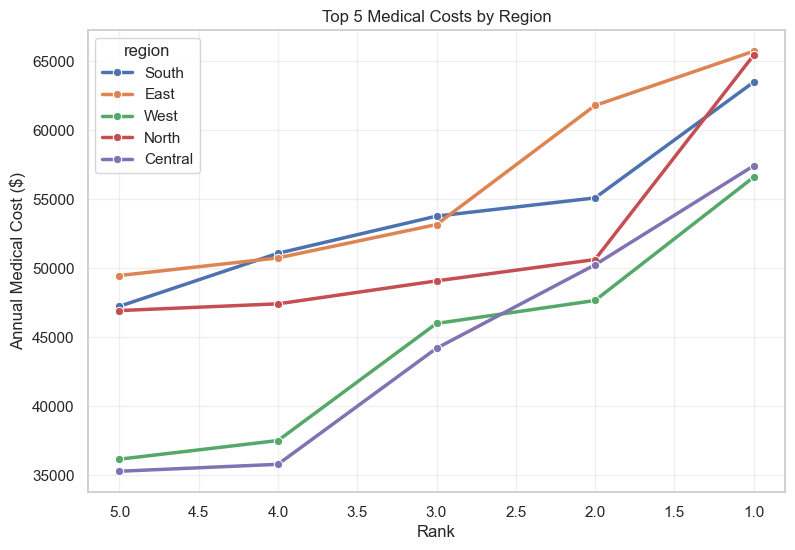

In [53]:
df["rank_in_region"] = df.groupby("region")[
    "annual_medical_cost"
].rank(method="dense", ascending=False)

top_5_in_region = df[df["rank_in_region"] <= 5]

top_5_in_region[[
    "person_id",
    "region",
    "annual_medical_cost",
    "rank_in_region"
]]
# Chart: cost of the top 5 most expensive people in each region
plt.figure(figsize=(9,6))

sns.lineplot(
    data=top_5_in_region,
    x="rank_in_region",
    y="annual_medical_cost",
    hue="region",
    marker="o",
    linewidth=2.5
)

plt.gca().invert_xaxis()

plt.title("Top 5 Medical Costs by Region")
plt.xlabel("Rank")
plt.ylabel("Annual Medical Cost ($)")
plt.grid(alpha=.3)

plt.show()

## Cost Distribution per Region vs Regional Average

   person_id   region  annual_medical_cost   region_avg  diff_from_avg
0      75722    North              6938.06  3002.007163    3936.052837
1      80185    North              1632.61  3002.007163   -1369.397163
2      19865    North              7661.01  3002.007163    4659.002837
3      76700    North              5130.27  3002.007163    2128.262837
4      92992  Central              1700.73  2968.236324   -1267.506324


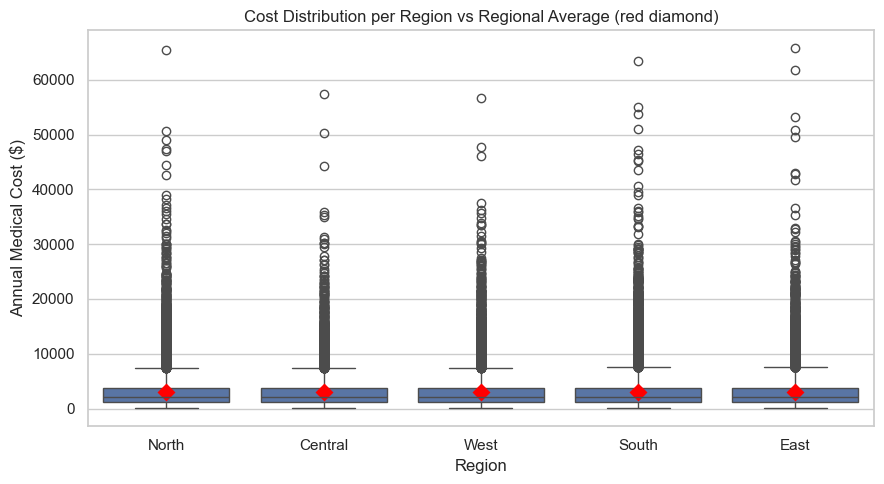

In [54]:
df["region_avg"] = df.groupby("region")[
    "annual_medical_cost"
].transform("mean")

df["diff_from_avg"] = ( 
    df["annual_medical_cost"] - df["region_avg"]
)

print(
    df[[
        "person_id",
        "region",
        "annual_medical_cost",
        "region_avg",
        "diff_from_avg"
    ]].head(5)
)
# Chart: each person's cost vs their region average (first 5 shown earlier; visualize full distribution)
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="region", y="annual_medical_cost", color="#4C72B0")
sns.pointplot(data=df, x="region", y="region_avg", color="red", markers="D", linestyles="")
plt.title("Cost Distribution per Region vs Regional Average (red diamond)")
plt.xlabel("Region")
plt.ylabel("Annual Medical Cost ($)")
plt.tight_layout()
plt.show()


## Distribution of Annual Medical Cost

{'min': 55.55, 'max': 65724.9, 'avg': np.float64(3009.45), 'Q1': np.float64(1175.12), 'Median': np.float64(2082.57), 'Q3': np.float64(3707.96)}


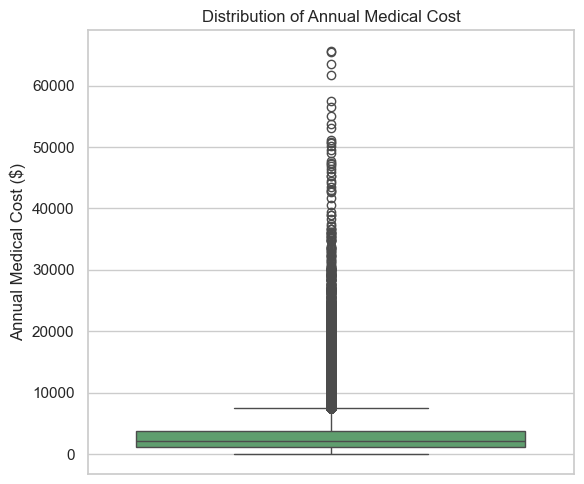

In [55]:
stats = {
    "min": round(df["annual_medical_cost"].min(), 2),
    "max": round(df["annual_medical_cost"].max(), 2),
    "avg": round(df["annual_medical_cost"].mean(), 2),
    "Q1": round(df["annual_medical_cost"].quantile(0.25), 2),
    "Median": round(df["annual_medical_cost"].quantile(0.50), 2),
    "Q3": round(df["annual_medical_cost"].quantile(0.75), 2)
}

print(stats)
# Chart: boxplot showing min/Q1/median/Q3/max of annual medical cost
plt.figure(figsize=(6, 5))
sns.boxplot(y=df["annual_medical_cost"], color="#55A868")
plt.title("Distribution of Annual Medical Cost")
plt.ylabel("Annual Medical Cost ($)")
plt.tight_layout()
plt.show()


## Percentage of People Above $30K Cost, by Region

         total_people  high_cost_cases  high_cost_pct
region                                               
Central       12081.0             10.0           0.08
East          19984.0             16.0           0.08
North         22027.0             23.0           0.10
South         28029.0             23.0           0.08
West          17879.0             16.0           0.09


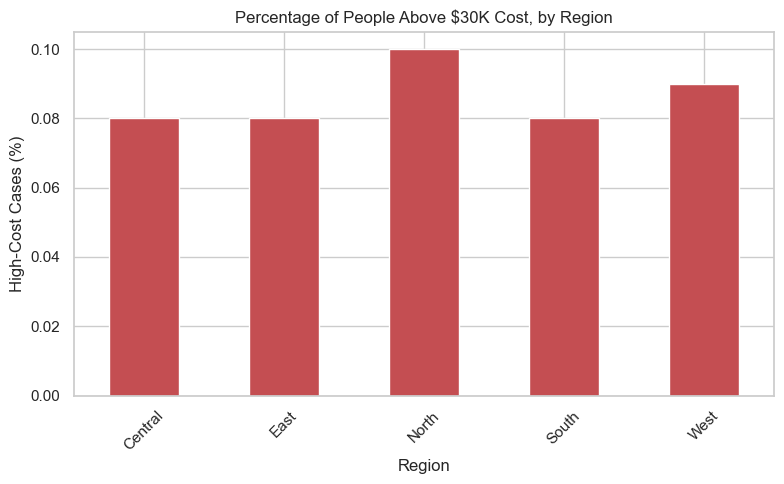

In [56]:
high_cost_region = df.groupby("region").apply(
    lambda x: pd.Series({
        "total_people": len(x),
        "high_cost_cases":
            (x["annual_medical_cost"] > 30000).sum(),
        "high_cost_pct":
            round(
                (x["annual_medical_cost"] > 30000).mean()*100,
                2
            )
    })
)

print(high_cost_region)
# Chart: percentage of high-cost cases (>$30K) by region
high_cost_region["high_cost_pct"].plot(kind="bar", color="#C44E52")
plt.title("Percentage of People Above $30K Cost, by Region")
plt.xlabel("Region")
plt.ylabel("High-Cost Cases (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## correlation between age and annual medical cost

Correlation = 0.1262


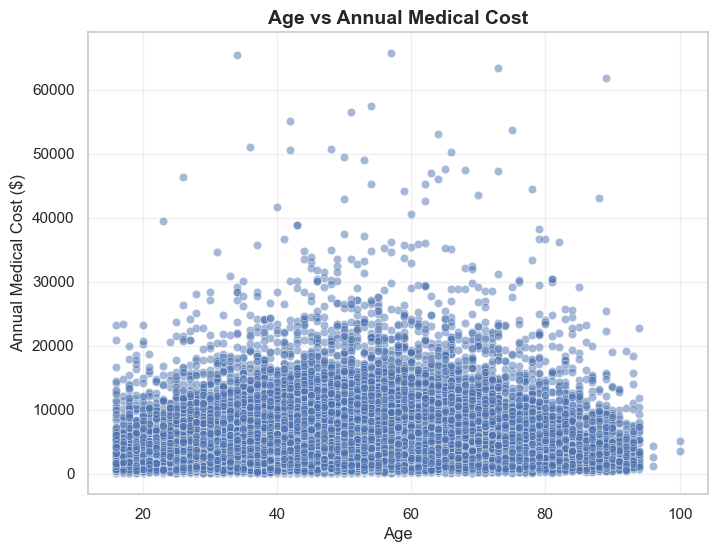

In [57]:
correlation = df["age"].corr(
    df["annual_medical_cost"]
)

print("Correlation =", round(correlation, 4))
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="age",
    y="annual_medical_cost",
    alpha=0.5,
    color="#4C72B0"
)

plt.title("Age vs Annual Medical Cost", fontsize=14, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Annual Medical Cost ($)")
plt.grid(alpha=0.3)

plt.show()

## average cost by risk profile tier

              total_people  avg_cost  min_cost  max_cost
risk_profile                                            
Low Risk             72347   2945.30     55.87  63482.48
Medium Risk          27653   3177.28     55.55  65724.90


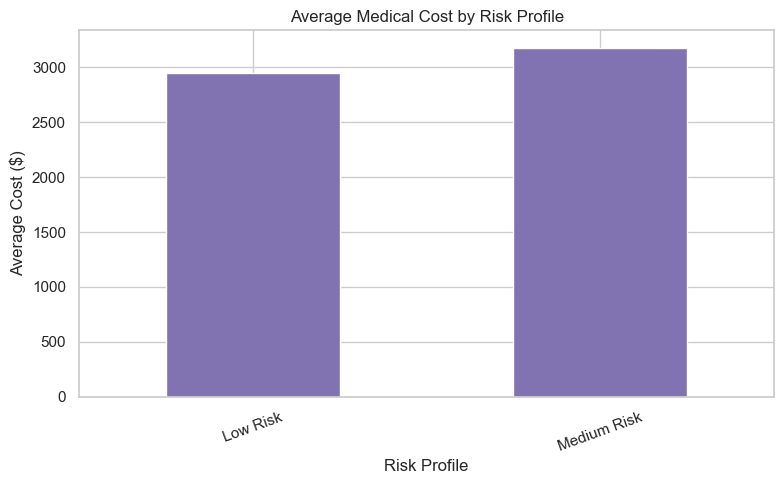

In [58]:
def risk_profile(row):

    if (
        row["smoker"] == 1 and
        row["bmi"] >= 30 and
        row["age"] >= 45
    ):
        return "Very High Risk"

    elif (
        row["smoker"] == 1 and
        row["bmi"] >= 30
    ):
        return "High Risk"

    elif (
        row["smoker"] == 1 or
        row["bmi"] >= 30
    ):
        return "Medium Risk"

    else:
        return "Low Risk"

df["risk_profile"] = df.apply(
    risk_profile,
    axis=1
)

risk_analysis = df.groupby(
    "risk_profile"
).agg(
    total_people=("risk_profile", "count"),
    avg_cost=("annual_medical_cost", "mean"),
    min_cost=("annual_medical_cost", "min"),
    max_cost=("annual_medical_cost", "max")
).round(2)

print(risk_analysis)
# Chart: average cost by risk profile tier
risk_order = ["Low Risk", "Medium Risk", "High Risk", "Very High Risk"]
risk_analysis_ordered = risk_analysis.reindex(
    [r for r in risk_order if r in risk_analysis.index]
)
risk_analysis_ordered["avg_cost"].plot(kind="bar", color="#8172B2")
plt.title("Average Medical Cost by Risk Profile")
plt.xlabel("Risk Profile")
plt.ylabel("Average Cost ($)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Average Cost, Age & BMI by Cost Decile

             total  avg_cost  avg_age  avg_bmi
cost_decile                                   
0            10000    496.42    43.89    26.22
1            10001    863.19    45.77    26.58
2             9999   1175.50    46.78    26.78
3            10000   1502.07    47.24    26.97
4            10000   1873.40    48.19    27.05
5            10000   2321.71    48.84    27.17
6            10000   2902.96    49.42    27.15
7            10000   3728.13    49.97    27.32
8            10000   5119.02    50.79    27.29
9            10000  10112.14    52.07    27.38


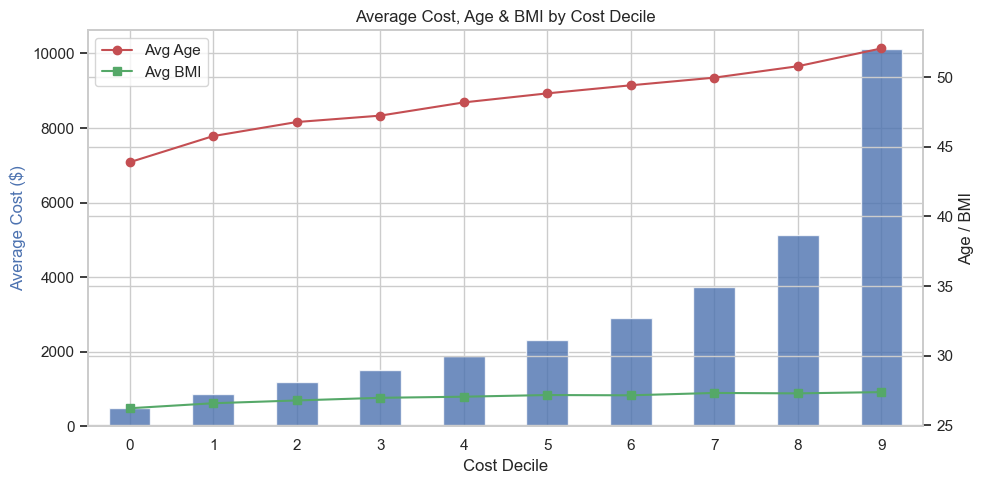

In [59]:
df["cost_decile"] = pd.qcut(
    df["annual_medical_cost"],
    10,
    labels=False,
    duplicates="drop"
)

decile_analysis = df.groupby(
    "cost_decile"
).agg(
    total=("cost_decile", "count"),
    avg_cost=("annual_medical_cost", "mean"),
    avg_age=("age", "mean"),
    avg_bmi=("bmi", "mean")
).round(2)

print(decile_analysis)
# Chart: average cost, age, and BMI across cost deciles
fig, ax1 = plt.subplots(figsize=(10, 5))
decile_analysis["avg_cost"].plot(kind="bar", ax=ax1, color="#4C72B0", alpha=0.8)
ax1.set_xlabel("Cost Decile")
ax1.set_ylabel("Average Cost ($)", color="#4C72B0")
ax1.tick_params(axis="x", rotation=0)

ax2 = ax1.twinx()
ax2.plot(range(len(decile_analysis)), decile_analysis["avg_age"], color="#C44E52", marker="o", label="Avg Age")
ax2.plot(range(len(decile_analysis)), decile_analysis["avg_bmi"], color="#55A868", marker="s", label="Avg BMI")
ax2.set_ylabel("Age / BMI")
ax2.legend(loc="upper left")

plt.title("Average Cost, Age & BMI by Cost Decile")
plt.tight_layout()
plt.show()


## Cumulative Share of Total Medical Cost (Sorted by Cost, Descending)

       person_id  annual_medical_cost  cumulative_cost  pct_of_total
35155      53690             65724.90         65724.90          0.02
20315      77342             65431.24        131156.14          0.02
84802      87612             63482.48        194638.62          0.02
14207      64768             61796.26        256434.88          0.02
27689      46769             57421.29        313856.17          0.02


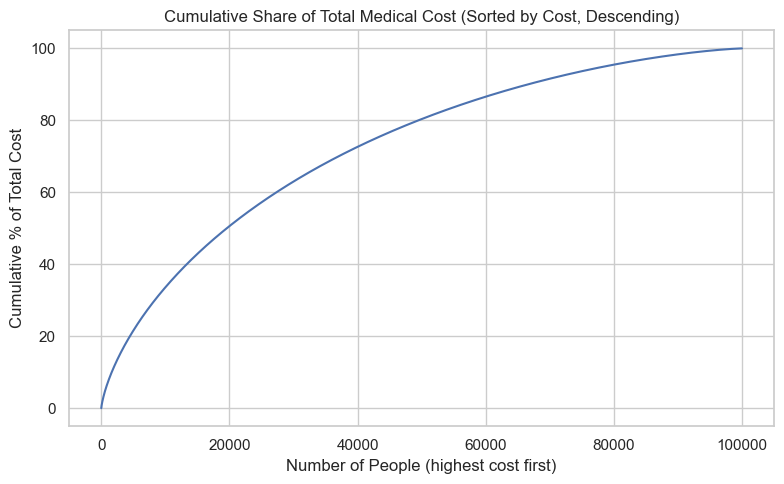

In [60]:

df_sorted = df.sort_values(
    by="annual_medical_cost",
    ascending=False
)


df_sorted["cumulative_cost"] = df_sorted["annual_medical_cost"].cumsum()


df_sorted["pct_of_total"] = (
    df_sorted["annual_medical_cost"]
    / df_sorted["annual_medical_cost"].sum()
    * 100
)

result = df_sorted[[
    "person_id",
    "annual_medical_cost",
    "cumulative_cost",
    "pct_of_total"
]].copy()


result = result.round({
    "annual_medical_cost": 2,
    "cumulative_cost": 2,
    "pct_of_total": 2
})

print(result.head())
# Chart: cumulative percentage of total cost as people are added (sorted by cost)
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(df_sorted) + 1),
    df_sorted["cumulative_cost"] / df_sorted["annual_medical_cost"].sum() * 100,
    color="#4C72B0"
)
plt.title("Cumulative Share of Total Medical Cost (Sorted by Cost, Descending)")
plt.xlabel("Number of People (highest cost first)")
plt.ylabel("Cumulative % of Total Cost")
plt.tight_layout()
plt.show()



## Correlation of Each Factor with Annual Medical Cost

age: 0.126
bmi: 0.043
income: -0.006
risk_score: 0.306
chronic_count: 0.297
claims_count: 0.179


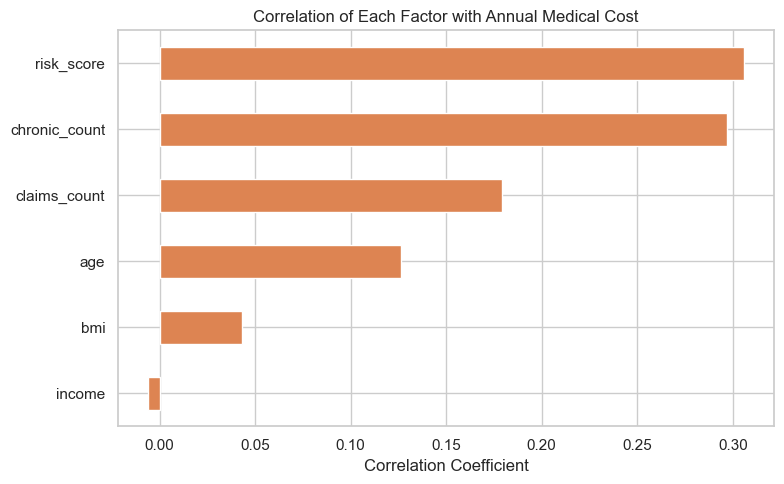

In [61]:
factors = [
    "age",
    "bmi",
    "income",
    "risk_score",
    "chronic_count",
    "claims_count"
]

for col in factors:
    corr = df[col].corr(df["annual_medical_cost"])
    print(f"{col}: {round(corr,3)}")
    # Chart: correlation of each factor with annual medical cost
corr_values = {col: df[col].corr(df["annual_medical_cost"]) for col in factors}
plt.figure(figsize=(8, 5))
pd.Series(corr_values).sort_values().plot(kind="barh", color="#DD8452")
plt.title("Correlation of Each Factor with Annual Medical Cost")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()


## High-Risk vs Low-Risk: Cost, Claims & Chronic Conditions

              avg_cost  avg_claims  avg_chronic
is_high_risk                                   
0              2408.49        1.21         0.38
1              4042.38        2.33         1.32


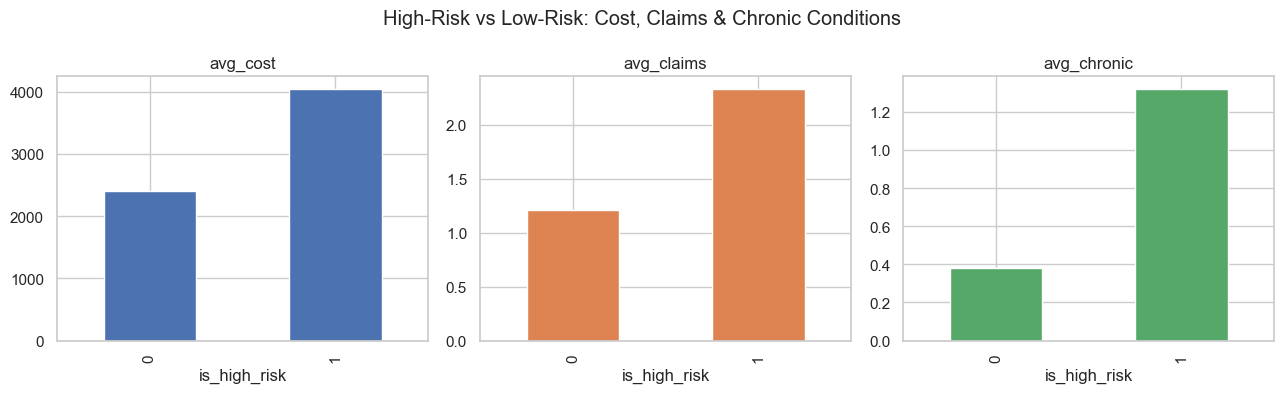

In [62]:
risk_analysis = df.groupby("is_high_risk").agg(
    avg_cost=("annual_medical_cost","mean"),
    avg_claims=("claims_count","mean"),
    avg_chronic=("chronic_count","mean")
).round(2)

print(risk_analysis)
# Chart: average cost, claims, and chronic conditions for high-risk vs low-risk
risk_analysis.plot(kind="bar", subplots=True, layout=(1, 3), figsize=(13, 4), legend=False)
plt.suptitle("High-Risk vs Low-Risk: Cost, Claims & Chronic Conditions")
plt.tight_layout()
plt.show()


## Average Cost & Claims by Chronic Condition Count

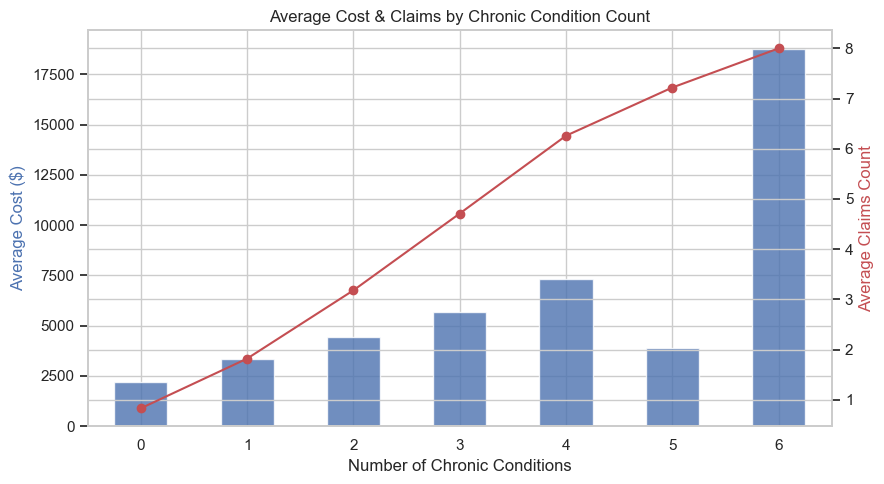

In [63]:
df.groupby("chronic_count").agg(
    avg_cost=("annual_medical_cost","mean"),
    avg_claims=("claims_count","mean")
).round(2)
# Chart: average cost and average claims by chronic condition count
chronic_claims = df.groupby("chronic_count").agg(
    avg_cost=("annual_medical_cost", "mean"),
    avg_claims=("claims_count", "mean")
).round(2)

fig, ax1 = plt.subplots(figsize=(9, 5))
chronic_claims["avg_cost"].plot(kind="bar", ax=ax1, color="#4C72B0", alpha=0.8)
ax1.set_ylabel("Average Cost ($)", color="#4C72B0")
ax1.set_xlabel("Number of Chronic Conditions")
ax1.tick_params(axis="x", rotation=0)

ax2 = ax1.twinx()
ax2.plot(range(len(chronic_claims)), chronic_claims["avg_claims"], color="#C44E52", marker="o")
ax2.set_ylabel("Average Claims Count", color="#C44E52")

plt.title("Average Cost & Claims by Chronic Condition Count")
plt.tight_layout()
plt.show()


## Average Cost by Chronic Condition Count & Smoking Status

                       avg_cost
smoker  chronic_count          
Current 0               3061.53
        1               4776.16
        2               6304.02
        3               8529.83
        4              12657.20
        5               4666.29
Former  0               2288.23
        1               3476.67
        2               4691.77
        3               6050.22
        4               8043.57
        6              18747.81
Never   0               1993.75
        1               3042.62
        2               4042.21
        3               5076.24
        4               6414.03
        5               3787.50


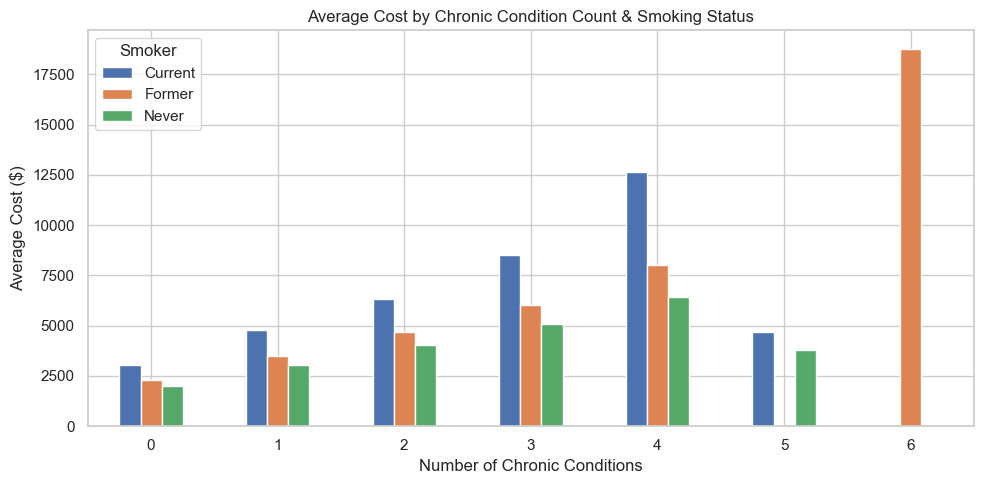

In [64]:
smoker_chronic = df.groupby(
    ["smoker","chronic_count"]
).agg(
    avg_cost=("annual_medical_cost","mean")
).round(2)

print(smoker_chronic)
# Chart: average cost by smoking status and chronic condition count
smoker_chronic_unstacked = smoker_chronic["avg_cost"].unstack("smoker")
smoker_chronic_unstacked.plot(kind="bar", figsize=(10, 5))
plt.title("Average Cost by Chronic Condition Count & Smoking Status")
plt.xlabel("Number of Chronic Conditions")
plt.ylabel("Average Cost ($)")
plt.xticks(rotation=0)
plt.legend(title="Smoker")
plt.tight_layout()
plt.show()


## Average Cost by BMI Category & Smoking Status

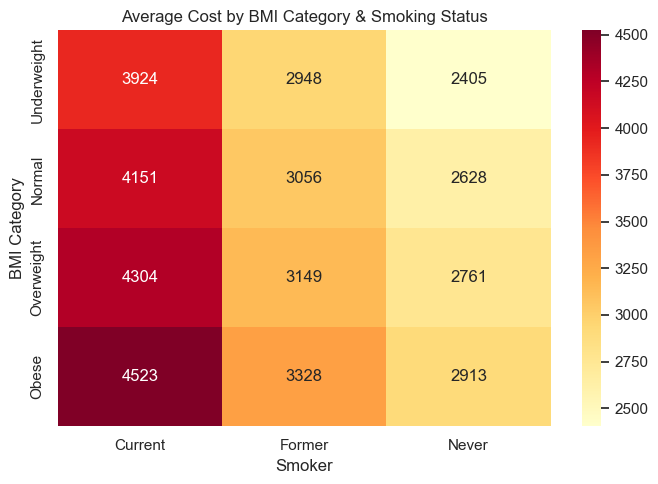

In [65]:
pd.pivot_table(
    df,
    values="annual_medical_cost",
    index="bmi_category",
    columns="smoker",
    aggfunc="mean"
).round(2)
# Chart: heatmap of average cost by BMI category and smoking status
pivot_bmi_smoker = pd.pivot_table(
    df, values="annual_medical_cost", index="bmi_category",
    columns="smoker", aggfunc="mean"
).round(2)

plt.figure(figsize=(7, 5))
sns.heatmap(pivot_bmi_smoker, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Average Cost by BMI Category & Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("BMI Category")
plt.tight_layout()
plt.show()


## Average Premium vs Average Cost by Risk Level"

              avg_premium  avg_cost
is_high_risk                       
0                  507.95   2408.49
1                  710.15   4042.38


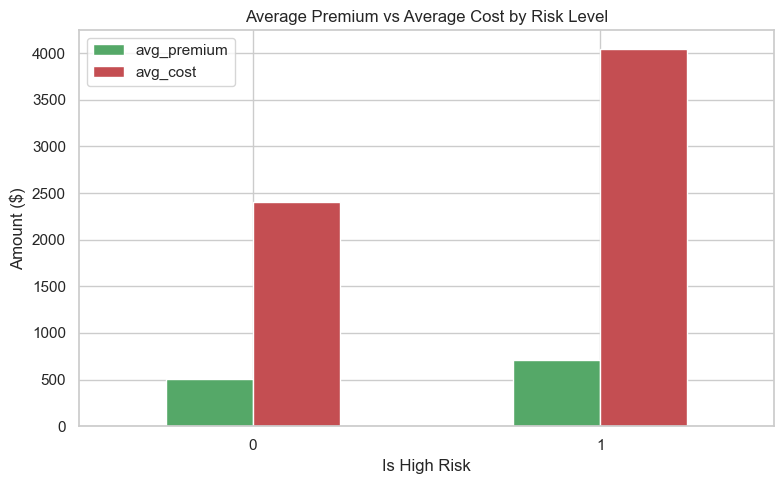

In [66]:
premium_risk = df.groupby("is_high_risk").agg(
    avg_premium=("annual_premium","mean"),
    avg_cost=("annual_medical_cost","mean")
).round(2)

print(premium_risk)
# Chart: average premium vs average cost for high-risk vs low-risk members
premium_risk.plot(kind="bar", figsize=(8, 5), color=["#55A868", "#C44E52"])
plt.title("Average Premium vs Average Cost by Risk Level")
plt.xlabel("Is High Risk")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Average Loss Ratio by Plan Type

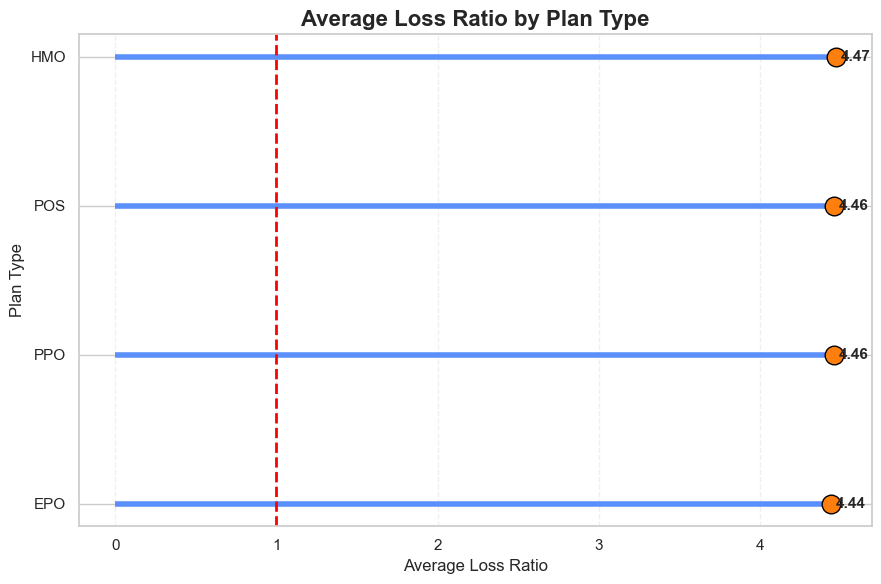

In [67]:
import matplotlib.pyplot as plt

df["loss_ratio"] = df["annual_medical_cost"] / df["annual_premium"]

loss_ratio_by_plan = (
    df.groupby("plan_type")["loss_ratio"]
      .mean()
      .sort_values()
      .round(2)
)

plt.figure(figsize=(9,6))

plt.hlines(
    y=loss_ratio_by_plan.index,
    xmin=0,
    xmax=loss_ratio_by_plan.values,
    color="#5B8FF9",
    linewidth=4
)

plt.scatter(
    loss_ratio_by_plan.values,
    loss_ratio_by_plan.index,
    s=180,
    color="#FF7F0E",
    edgecolors="black",
    zorder=3
)

for i, value in enumerate(loss_ratio_by_plan.values):
    plt.text(
        value + 0.03,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.axvline(
    1,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Average Loss Ratio by Plan Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Loss Ratio")
plt.ylabel("Plan Type")
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Average Cost & Claims by Provider Quality

                  avg_cost  avg_claims
provider_quality                      
1.50               4234.47        1.64
1.51               1294.48        2.00
1.52               2786.52        2.00
1.54               1709.16        1.75
1.55               1164.31        1.00
...                    ...         ...
4.96               2867.40        1.13
4.97               2725.03        1.60
4.98               2932.86        1.45
4.99               2524.92        1.13
5.00               2995.37        1.62

[350 rows x 2 columns]


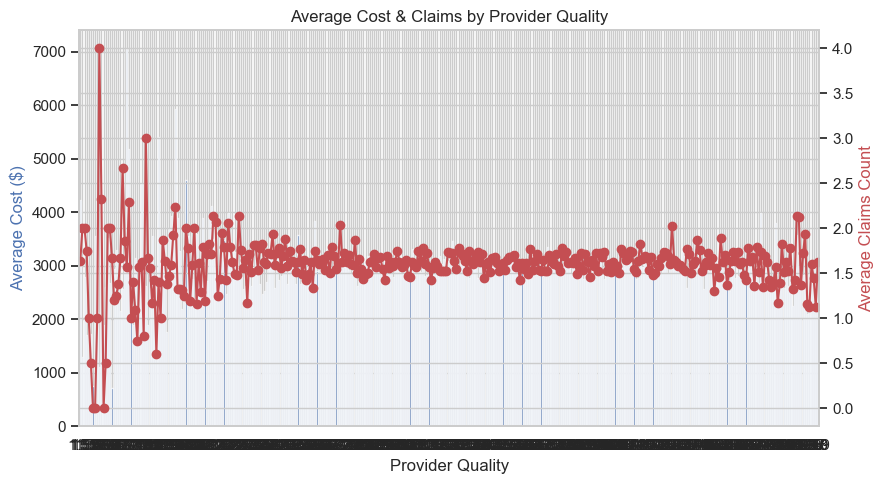

In [68]:
provider_analysis = df.groupby(
    "provider_quality"
).agg(
    avg_cost=("annual_medical_cost","mean"),
    avg_claims=("claims_count","mean")
).round(2)

print(provider_analysis)
# Chart: average cost and average claims by provider quality level
fig, ax1 = plt.subplots(figsize=(9, 5))
provider_analysis["avg_cost"].plot(kind="bar", ax=ax1, color="#4C72B0", alpha=0.8)
ax1.set_ylabel("Average Cost ($)", color="#4C72B0")
ax1.set_xlabel("Provider Quality")
ax1.tick_params(axis="x", rotation=0)

ax2 = ax1.twinx()
ax2.plot(range(len(provider_analysis)), provider_analysis["avg_claims"], color="#C44E52", marker="o")
ax2.set_ylabel("Average Claims Count", color="#C44E52")

plt.title("Average Cost & Claims by Provider Quality")
plt.tight_layout()
plt.show()


## Correlation of Procedure Counts with Annual Medical Cost"

proc_imaging_count 0.055
proc_surgery_count 0.077
proc_physio_count 0.042
proc_consult_count 0.049
proc_lab_count 0.052


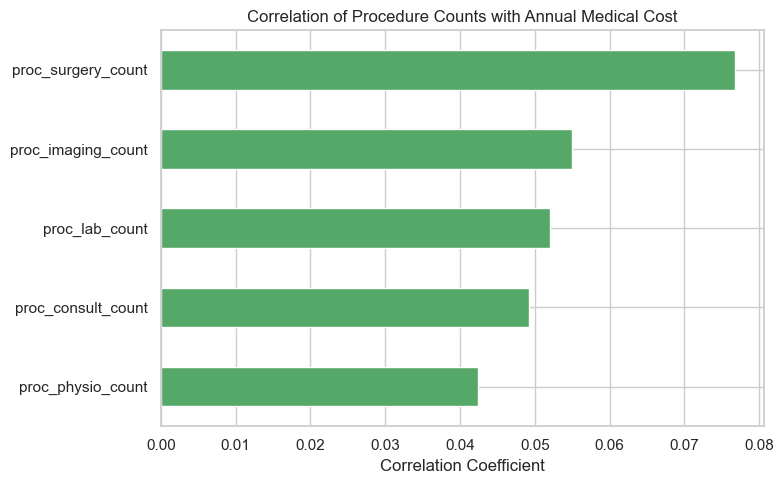

In [ ]:
# Analyze the correlation between procedure counts and annual medical cost

procedures = [
    "proc_imaging_count",
    "proc_surgery_count",
    "proc_physio_count",
    "proc_consult_count",
    "proc_lab_count"
]

# Print the correlation for each procedure type
for col in procedures:
    print(
        col,
        round(df[col].corr(df["annual_medical_cost"]), 3)
    )

# Chart: correlation of each procedure type with annual medical cost
proc_corr = {
    col: df[col].corr(df["annual_medical_cost"])
    for col in procedures
}

plt.figure(figsize=(8, 5))

pd.Series(proc_corr).sort_values().plot(
    kind="barh",
    color="#55A868"
)

plt.title("Correlation of Procedure Counts with Annual Medical Cost")
plt.xlabel("Correlation Coefficient")

plt.tight_layout()
plt.show()

## distribution of key stats for the top 10% most expensive individuals

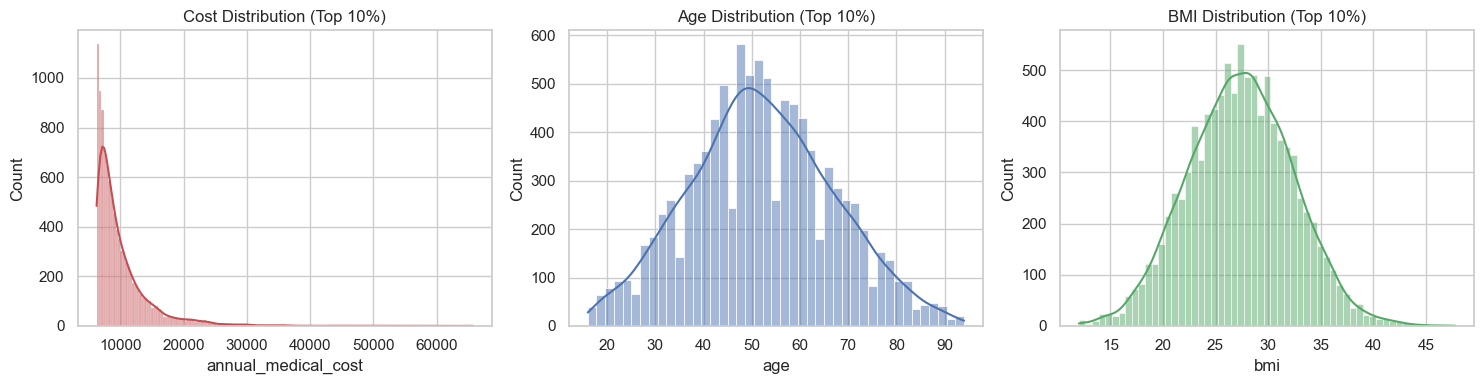

In [70]:
threshold = df["annual_medical_cost"].quantile(0.90)

top10 = df[
    df["annual_medical_cost"] >= threshold
]

top10.describe()
# Chart: distribution of key stats for the top 10% most expensive individuals
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(top10["annual_medical_cost"], kde=True, ax=axes[0], color="#C44E52")
axes[0].set_title("Cost Distribution (Top 10%)")

sns.histplot(top10["age"], kde=True, ax=axes[1], color="#4C72B0")
axes[1].set_title("Age Distribution (Top 10%)")

sns.histplot(top10["bmi"], kde=True, ax=axes[2], color="#55A868")
axes[2].set_title("BMI Distribution (Top 10%)")

plt.tight_layout()
plt.show()


## Dashboard

In [71]:
# Extra imports needed by the dashboard cells below
# (these were missing before, which is why the dashboard cells used to fail)
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker


## Dashboard 1: Insurance Cost Overview

This dashboard provides an overview of the insurance dataset by summarizing the most important key performance indicators (KPIs), including total medical costs, total members, total premiums, and average medical cost per member. It also visualizes the distribution of members across different medical cost ranges and shows each range's contribution to the total medical cost, giving a clear understanding of the overall cost structure and spending patterns

Dataset ready: 100000 rows, 66 columns
Dashboard variables ready: combo, chronic_analysis, pivot_smoker_chronic, result, loss_by_plan, corr_target, disease_cost, risk_col, risk_analysis2


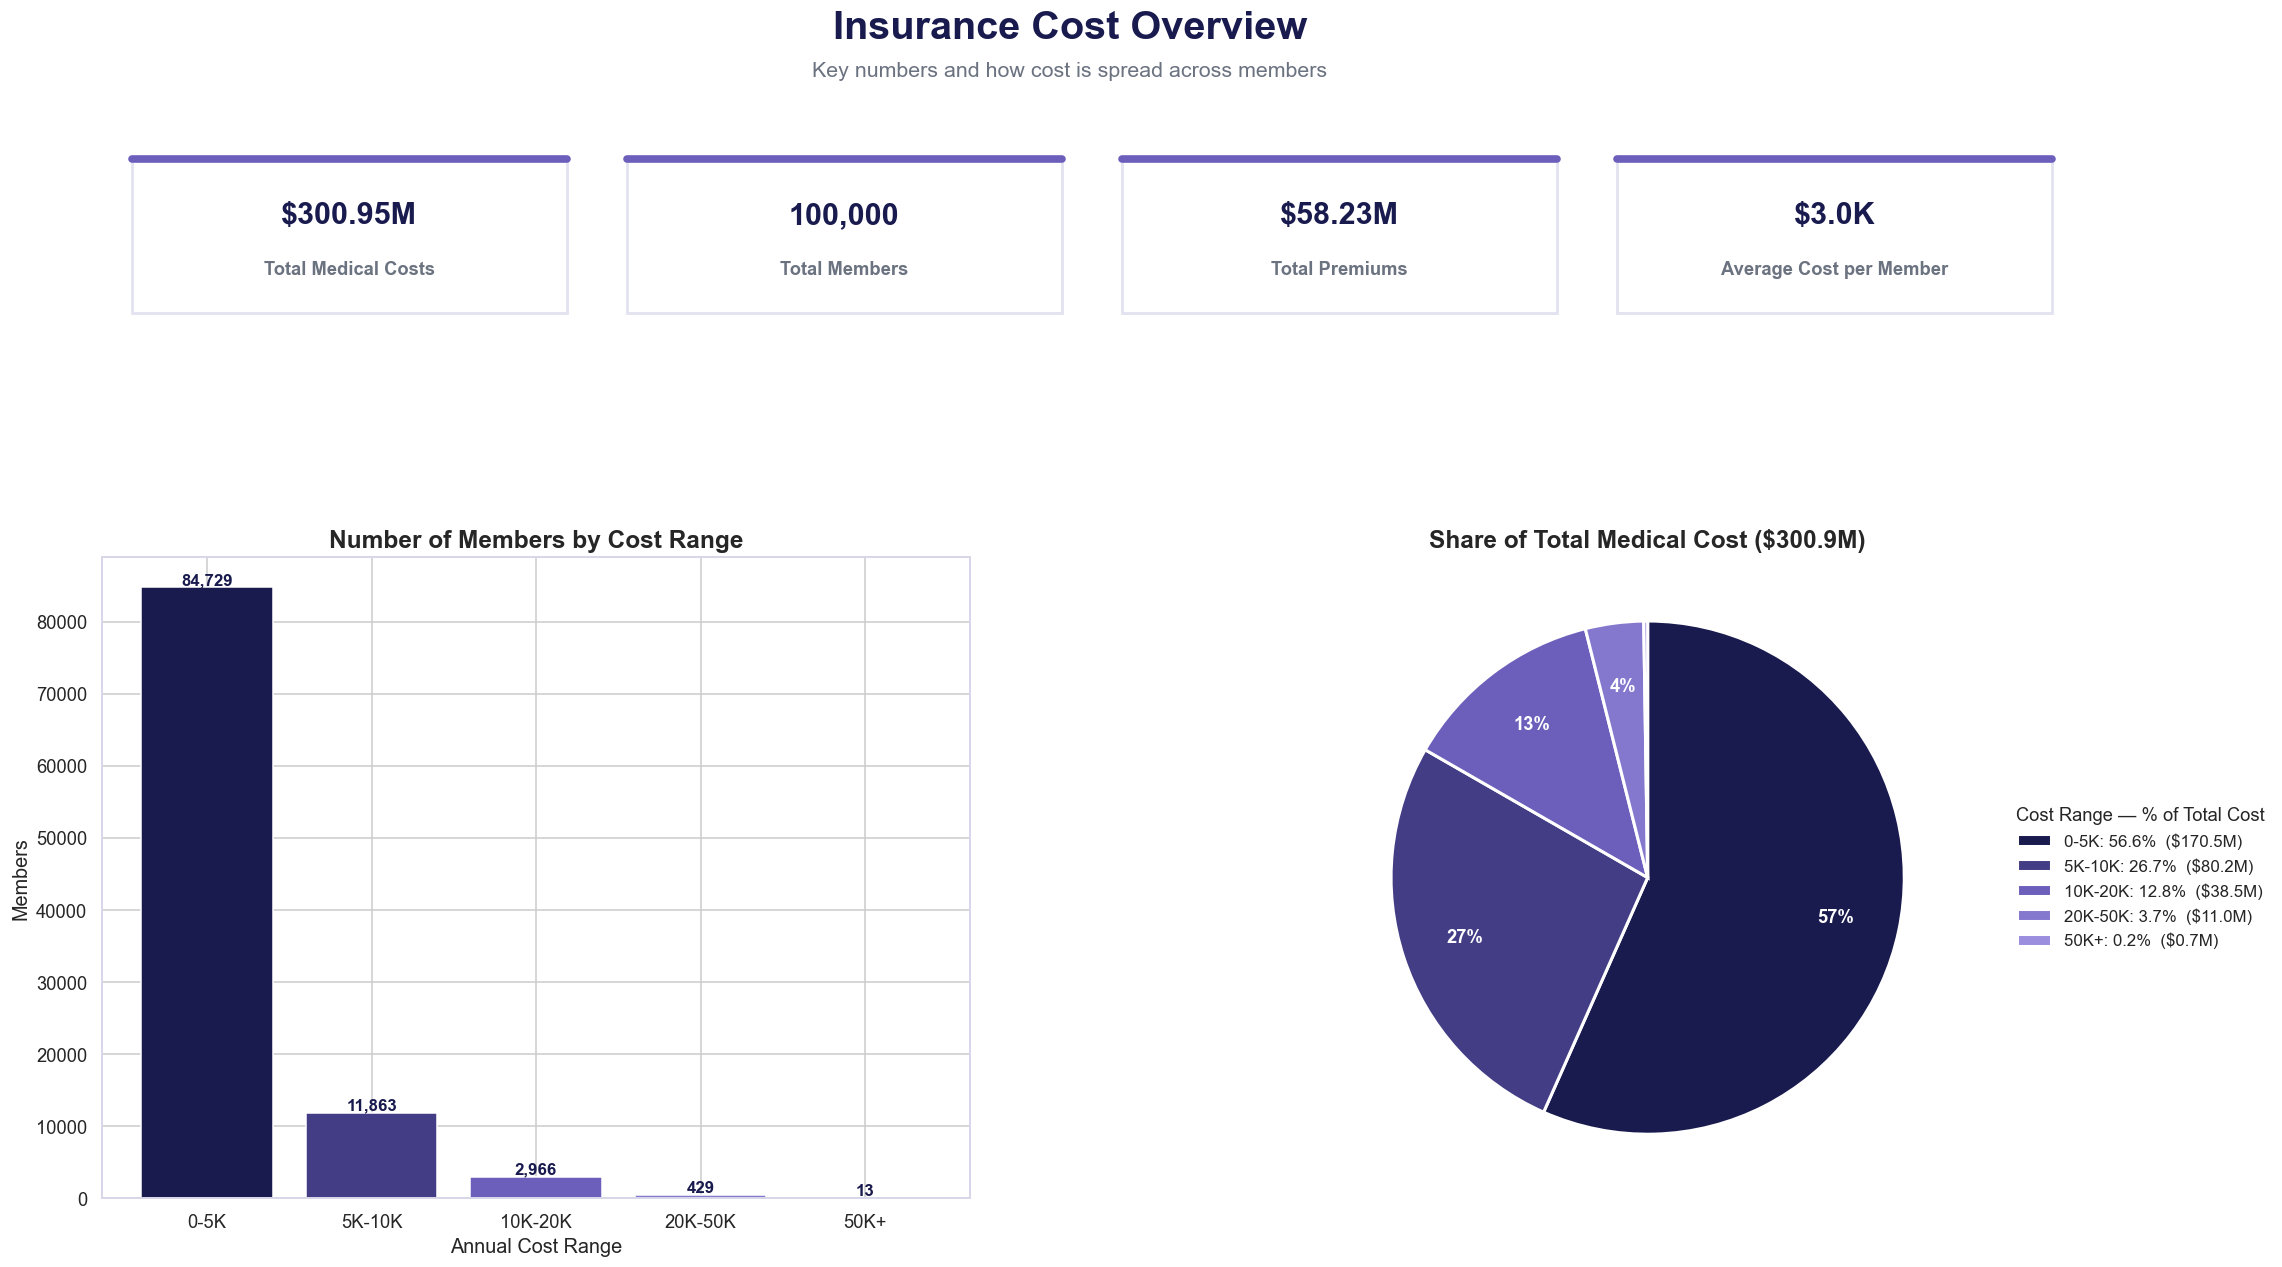

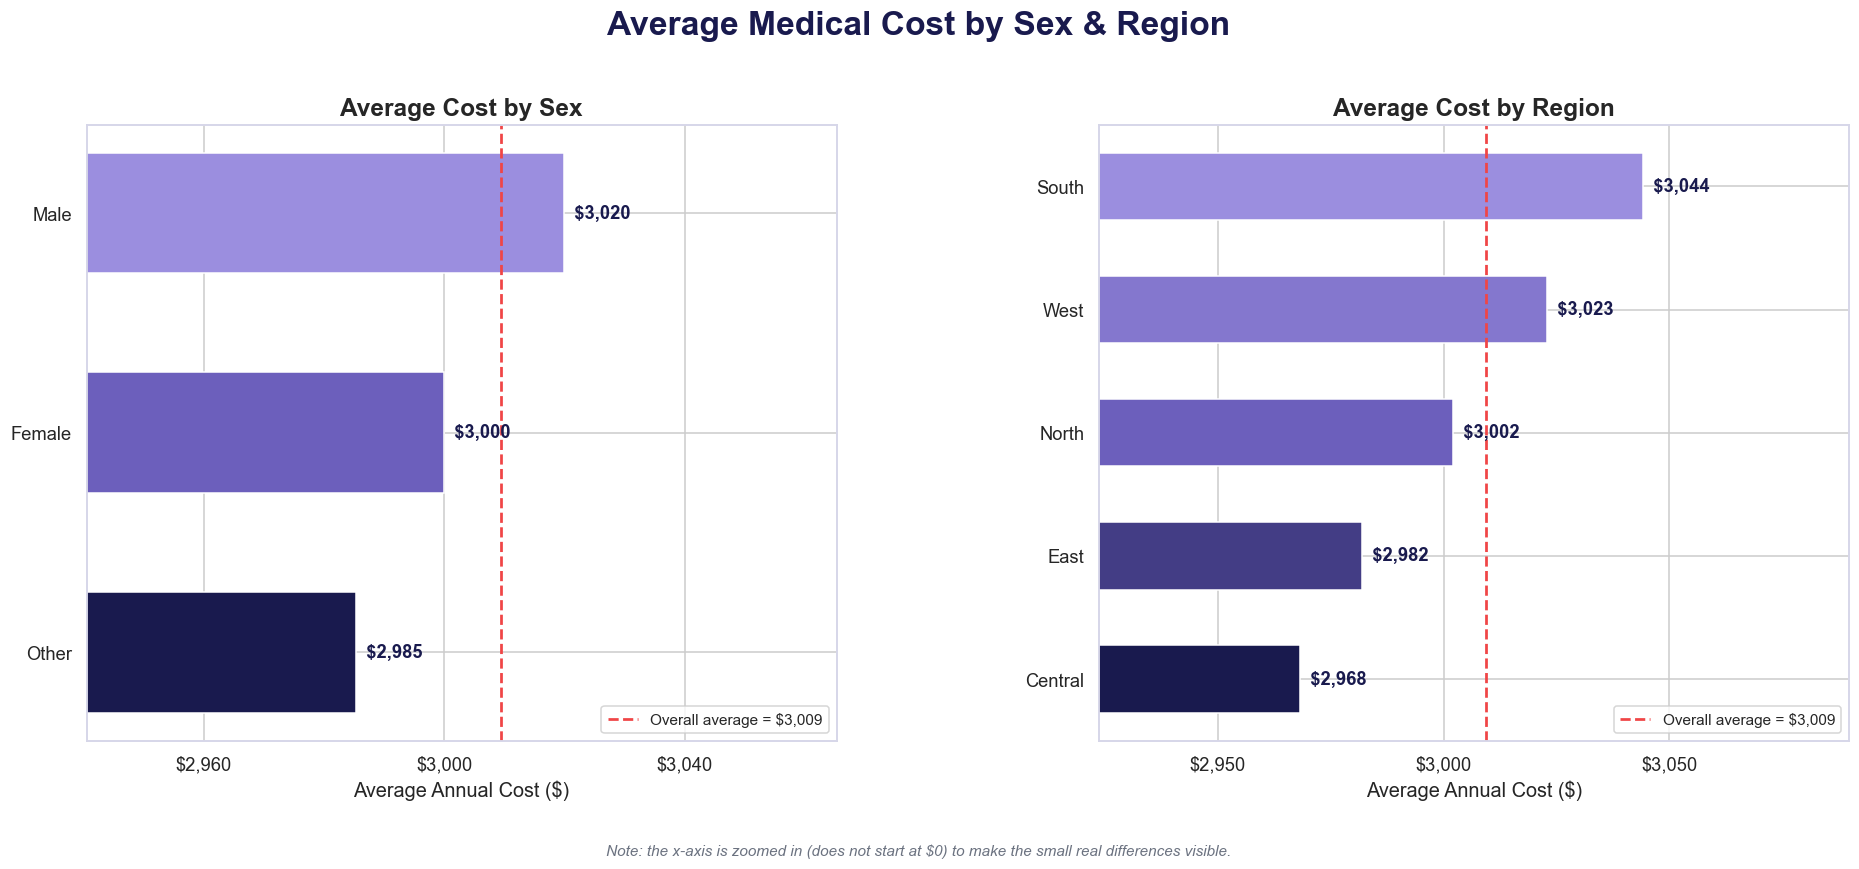

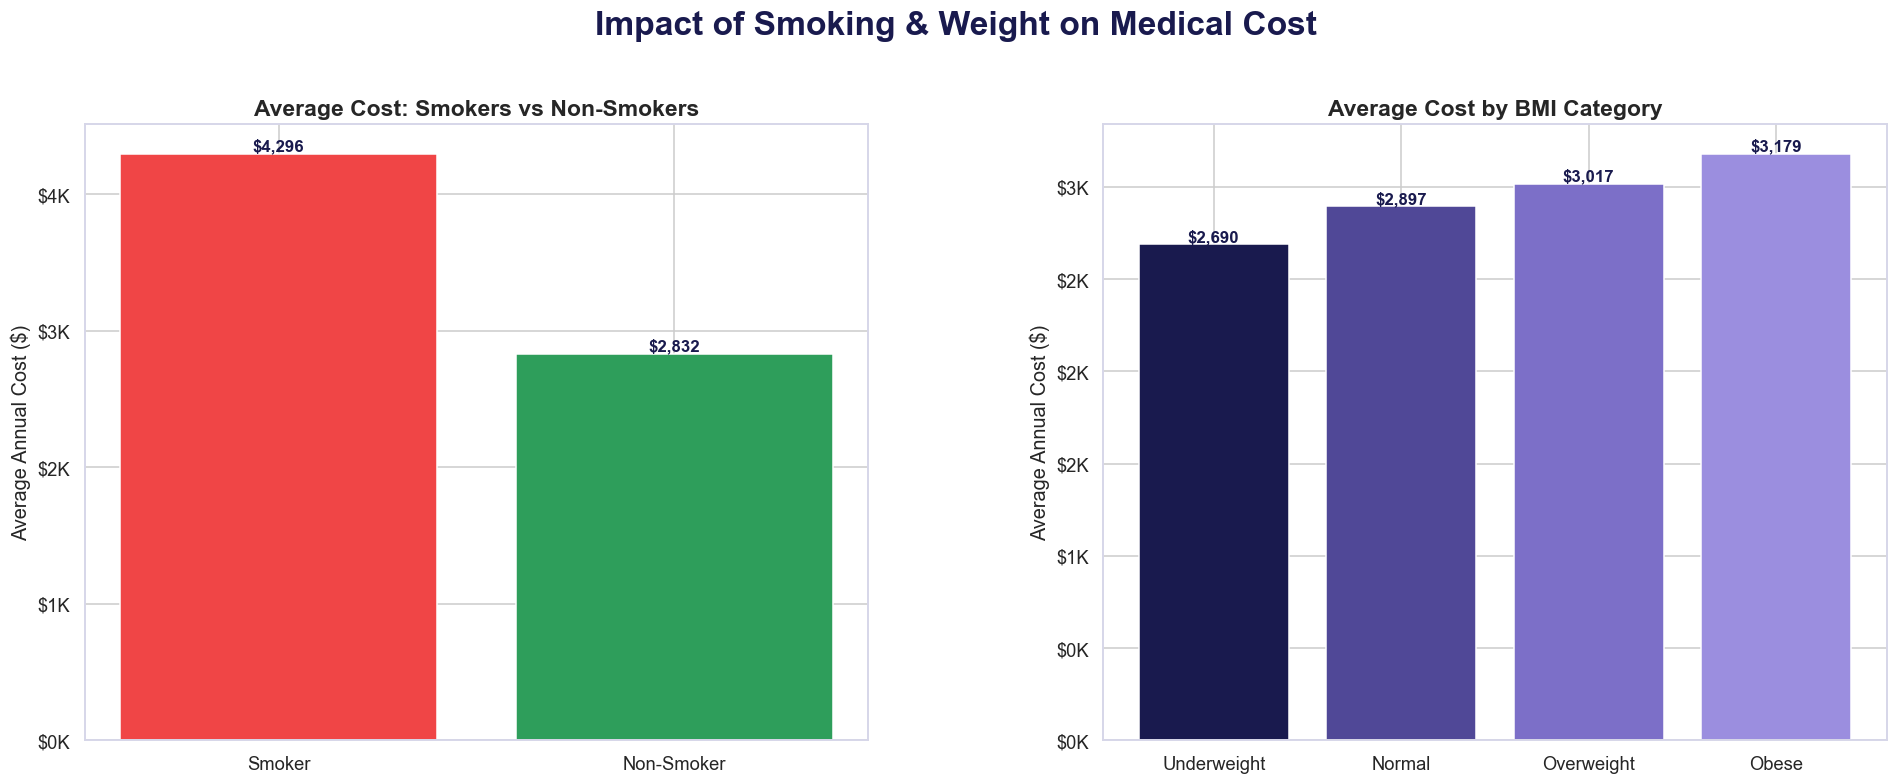

In [72]:

# ===========================================================
# IMPORTS
# ===========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

# ===========================================================
# GLOBAL STYLE SETTINGS
# ===========================================================
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 13
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["axes.edgecolor"] = "#D6D6E8"

NAVY        = "#191A4E"
NAVY_LIGHT  = "#3B3F8F"
PURPLE      = "#9B8EDF"
PURPLE_DEEP = "#6C5FBC"
RED         = "#F04546"
GREY_TXT    = "#6B7280"
GREEN       = "#2E9E5B"


# ===========================================================
# HELPER FUNCTIONS
# ===========================================================
def fmt_k(x, pos=None):
    """Compact format e.g. $3K — good for charts with a WIDE range."""
    return f"${x/1000:,.0f}K"


def fmt_dollar_precise(x, pos=None):
    """Full precision format e.g. $3,020 — needed when values are close together."""
    return f"${x:,.0f}"


def navy_purple_colors(n):
    if n <= 1:
        return [NAVY]
    cmap = LinearSegmentedColormap.from_list("navy_line", [NAVY, PURPLE_DEEP, PURPLE])
    return [cmap(i / (n - 1)) for i in range(n)]


def add_bar_labels(ax, fmt="{:,.0f}"):
    """Writes the value on top of each bar so the reader doesn't have to guess."""
    for p in ax.patches:
        h = p.get_height()
        if h == 0 or pd.isna(h):
            continue
        ax.annotate(fmt.format(h), (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom", fontsize=11, fontweight="bold", color=NAVY)


def draw_kpi_row(fig, gs_row, kpis):
    """Draws a row of KPI cards (label + big value) inside a GridSpec row."""
    kpi_ax = fig.add_subplot(gs_row)
    kpi_ax.axis("off")
    kpi_ax.set_xlim(0, 1)
    kpi_ax.set_ylim(0, 1)
    n = len(kpis)
    card_w = 1/n - 0.03
    card_h = 0.72
    card_y = 0.14
    for i, (label, value) in enumerate(kpis):
        x0 = i/n + 0.015
        kpi_ax.add_patch(plt.Rectangle((x0, card_y), card_w, card_h, transform=kpi_ax.transAxes,
                                        facecolor="white", edgecolor="#E2E2F0", linewidth=1.8))
        kpi_ax.plot([x0, x0 + card_w], [card_y + card_h, card_y + card_h],
                    transform=kpi_ax.transAxes, color=PURPLE_DEEP, linewidth=5)
        kpi_ax.text(x0 + card_w/2, card_y + 0.42, value, transform=kpi_ax.transAxes,
                    fontsize=20, fontweight="bold", color=NAVY, ha="center")
        kpi_ax.text(x0 + card_w/2, card_y + 0.18, label, transform=kpi_ax.transAxes,
                    fontsize=12, color=GREY_TXT, ha="center", fontweight="bold")


def zoomed_hbar(ax, series, title, overall_avg):
    """
    Horizontal bar chart zoomed into the data range, with:
    - full precision $ labels on the bars
    - a red reference line for the overall average
    - a clean x-axis with few, non-repeating tick labels
    """
    series = series.sort_values()
    y_pos = np.arange(len(series))
    colors = navy_purple_colors(len(series))
    ax.barh(y_pos, series.values, color=colors, height=0.55)

    lo = series.min() * 0.985
    hi = series.max() * 1.015
    ax.set_xlim(lo, hi)

    ax.axvline(overall_avg, color=RED, linestyle="--", linewidth=1.8,
               label=f"Overall average = ${overall_avg:,.0f}")

    for i, v in enumerate(series.values):
        ax.text(v, i, f"  ${v:,.0f}", va="center", fontsize=12, fontweight="bold", color=NAVY)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(series.index.astype(str))
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Average Annual Cost ($)")

    # Few ticks + full precision so labels don't repeat (fix for the $3K $3K $3K issue)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar_precise))
    ax.legend(fontsize=10, loc="lower right")


# ===========================================================
# LOAD & PREPARE DATA
# ===========================================================
# NOTE: df is reused from the cleaning steps earlier in the notebook.
# (Removed the re-read of the raw CSV here — it was overwriting the
# cleaned df and losing the earlier age/diabetes/procedure corrections.)

def age_group(age):
    if age < 30: return "Young"
    elif age < 45: return "Middle"
    elif age < 60: return "Senior"
    else: return "Elder"

df["age_group"] = df["age"].apply(age_group)
df["age_group"] = pd.Categorical(df["age_group"], categories=["Young", "Middle", "Senior", "Elder"], ordered=True)

bins = [0, 5000, 10000, 20000, 50000, float("inf")]
labels = ["0-5K", "5K-10K", "10K-20K", "20K-50K", "50K+"]
df["cost_range"] = pd.cut(df["annual_medical_cost"], bins=bins, labels=labels)

def normalize_smoker(val):
    if pd.isna(val):
        return "Non-Smoker"
    if isinstance(val, (int, float, np.integer, np.floating, bool)):
        return "Smoker" if val == 1 else "Non-Smoker"
    val_str = str(val).strip().lower()
    if val_str in ("yes", "y", "smoker", "1", "true", "current"):
        return "Smoker"
    return "Non-Smoker"

df["smoker_label"] = df["smoker"].apply(normalize_smoker)

bmi_bins = [0, 18.5, 25, 30, float("inf")]
bmi_labels = ["Underweight", "Normal", "Overweight", "Obese"]
df["bmi_category"] = pd.cut(df["bmi"], bins=bmi_bins, labels=bmi_labels)

print("Dataset ready:", df.shape[0], "rows,", df.shape[1], "columns")

# ===========================================================
# EXTRA PREP — variables required by Dashboard 2 / 3 / 4 below
# (this is the fix for the "KeyError: bmi_category" / NameError bugs)
# ===========================================================

# Extra colormaps used by Dashboard 3's correlation heatmap
NAVY_PURPLE_CMAP = LinearSegmentedColormap.from_list("navy_purple", [NAVY, "#FFFFFF", PURPLE_DEEP])
NAVY_SEQ_CMAP    = LinearSegmentedColormap.from_list("navy_seq", ["#E8E7F7", PURPLE, NAVY])

# FIX: rebuild `combo` with flat columns (smoker_label, bmi_category, avg_cost).
# The old `combo` further up the notebook (Cell ~58) used df.groupby(["smoker","bmi_category"])
# WITHOUT .reset_index(), so "bmi_category" stayed a MultiIndex level, not a real column,
# and it used "smoker" (0/1) instead of "smoker_label" ("Smoker"/"Non-Smoker").
# Dashboard 2 needs combo["bmi_category"] and combo["smoker_label"] as actual columns,
# which is why it was throwing KeyError: 'bmi_category'.
combo = df.groupby(["smoker_label", "bmi_category"], observed=True).agg(
    avg_cost=("annual_medical_cost", "mean")
).round(2).reset_index()

# Needed by Dashboard 2 (chronic condition line chart)
chronic_analysis = df.groupby("chronic_count").agg(
    total_people=("chronic_count", "count"),
    avg_cost=("annual_medical_cost", "mean")
).round(2)

# Needed by Dashboard 2b (smoking x chronic count heatmap)
smoker_chronic = df.groupby(["smoker_label", "chronic_count"], observed=True).agg(
    avg_cost=("annual_medical_cost", "mean")
).round(2).reset_index()
pivot_smoker_chronic = smoker_chronic.pivot(index="smoker_label", columns="chronic_count", values="avg_cost")

# Needed by Dashboard 2b (above-average-cost cases by age group x smoking status)
avg_cost_all = df["annual_medical_cost"].mean()
high_cost = df[df["annual_medical_cost"] > avg_cost_all]
result = high_cost.groupby(["smoker_label", "age_group"], observed=True).size().reset_index(name="high_cost_cases")

# Needed by Dashboard 3 (loss ratio KPI + chart)
df["loss_ratio"] = df["annual_medical_cost"] / df["annual_premium"]
loss_by_plan = df.groupby("plan_type").agg(
    avg_loss_ratio=("loss_ratio", "mean")
).round(2).sort_values("avg_loss_ratio", ascending=False)

# Needed by Dashboard 3 (correlation heatmap)
numeric_df = df.select_dtypes(include=[np.number])
corr_target = numeric_df.corr()[["annual_medical_cost"]].sort_values(by="annual_medical_cost", ascending=False)

# Needed by Dashboard 3 (average cost per chronic disease bar chart)
diseases = [c for c in ["hypertension", "diabetes", "asthma", "copd", "cardiovascular_disease",
            "cancer_history", "kidney_disease", "liver_disease", "arthritis", "mental_health"] if c in df.columns]
disease_cost = pd.Series(
    {d: df.loc[df[d] == 1, "annual_medical_cost"].mean() for d in diseases}
).sort_values(ascending=False)

# Needed by Dashboard 3b (high-risk vs low/medium-risk comparison)
risk_col = "is_high_risk" if "is_high_risk" in df.columns else None
if risk_col:
    risk_analysis2 = df.groupby(risk_col).agg(
        avg_cost=("annual_medical_cost", "mean"),
        avg_claims=("claims_count", "mean"),
        avg_chronic=("chronic_count", "mean")
    ).round(2)
    risk_analysis2.index = ["Low/Medium Risk", "High Risk"] if len(risk_analysis2) == 2 else risk_analysis2.index

print("Dashboard variables ready: combo, chronic_analysis, pivot_smoker_chronic, result,",
      "loss_by_plan, corr_target, disease_cost, risk_col" + (", risk_analysis2" if risk_col else ""))



# ===========================================================
# DASHBOARD 1 — Overview: KPIs + Members by Cost Range
# ===========================================================
fig1 = plt.figure(figsize=(20, 12), facecolor="white")
gs1 = GridSpec(2, 2, figure=fig1, height_ratios=[0.5, 1.5],
               hspace=0.5, wspace=0.28, top=0.88, bottom=0.07, left=0.06, right=0.96)

fig1.suptitle("Insurance Cost Overview", fontsize=26, fontweight="bold", color=NAVY, y=0.97)
fig1.text(0.5, 0.92, "Key numbers and how cost is spread across members", ha="center", fontsize=14, color=GREY_TXT)

kpis1 = [
    ("Total Medical Costs", f"${df['annual_medical_cost'].sum()/1e6:,.2f}M"),
    ("Total Members", f"{len(df):,}"),
    ("Total Premiums", f"${df['annual_premium'].sum()/1e6:,.2f}M"),
    ("Average Cost per Member", f"${df['annual_medical_cost'].mean()/1000:,.1f}K"),
]
draw_kpi_row(fig1, gs1[0, :], kpis1)

# Chart: Number of members per cost range
ax = fig1.add_subplot(gs1[1, 0])
cost_range_counts = df["cost_range"].value_counts().sort_index()
ax.bar(cost_range_counts.index.astype(str), cost_range_counts.values, color=navy_purple_colors(len(cost_range_counts)))
add_bar_labels(ax)
ax.set_title("Number of Members by Cost Range", fontsize=16)
ax.set_ylabel("Members")
ax.set_xlabel("Annual Cost Range")

# Chart: Share of total cost per cost range — PIE + LEGEND (fixes label overlap)
ax = fig1.add_subplot(gs1[1, 1])
cost_by_range = df.groupby("cost_range", observed=True)["annual_medical_cost"].sum()
total_cost = cost_by_range.sum()
colors_pie = navy_purple_colors(len(cost_by_range))

wedges, _, autotexts = ax.pie(
    cost_by_range.values,
    colors=colors_pie,
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    autopct=lambda pct: f"{pct:.0f}%" if pct >= 3 else "",   # hide % text on tiny slices to avoid clutter
    pctdistance=0.75,
    textprops={"fontsize": 12, "fontweight": "bold", "color": "white"},
)

legend_labels = [
    f"{idx}: {val/total_cost*100:.1f}%  (${val/1e6:,.1f}M)"
    for idx, val in cost_by_range.items()
]
ax.legend(wedges, legend_labels, title="Cost Range — % of Total Cost",
          loc="center left", bbox_to_anchor=(1.05, 0.5), fontsize=11, title_fontsize=12, frameon=False)

ax.set_title(f"Share of Total Medical Cost (${total_cost/1e6:,.1f}M)", fontsize=16)

plt.savefig("Dashboard_1_Overview.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


# ===========================================================
# DASHBOARD 2 — Average Cost by Sex & Region (zoomed, precise $ labels)
# ===========================================================
fig2 = plt.figure(figsize=(18, 8), facecolor="white")
gs2 = GridSpec(1, 2, figure=fig2, wspace=0.35, top=0.85, bottom=0.15, left=0.08, right=0.97)

fig2.suptitle("Average Medical Cost by Sex & Region", fontsize=22, fontweight="bold", color=NAVY, y=0.98)

overall_avg = df["annual_medical_cost"].mean()

ax = fig2.add_subplot(gs2[0, 0])
avg_by_sex = df.groupby("sex")["annual_medical_cost"].mean()
zoomed_hbar(ax, avg_by_sex, "Average Cost by Sex", overall_avg)

ax = fig2.add_subplot(gs2[0, 1])
avg_by_region = df.groupby("region")["annual_medical_cost"].mean()
zoomed_hbar(ax, avg_by_region, "Average Cost by Region", overall_avg)

fig2.text(0.5, 0.02,
          "Note: the x-axis is zoomed in (does not start at $0) to make the small real differences visible.",
          ha="center", fontsize=10, color=GREY_TXT, style="italic")

plt.savefig("Dashboard_2_Sex_Region_Zoomed.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


# ===========================================================
# DASHBOARD 3 — Impact of Smoking & Weight on Medical Cost
# ===========================================================
fig3 = plt.figure(figsize=(18, 8), facecolor="white")
gs3 = GridSpec(1, 2, figure=fig3, wspace=0.3, top=0.85, bottom=0.15, left=0.06, right=0.97)

fig3.suptitle("Impact of Smoking & Weight on Medical Cost", fontsize=22, fontweight="bold", color=NAVY, y=0.98)

ax = fig3.add_subplot(gs3[0, 0])
avg_by_smoker = df.groupby("smoker_label")["annual_medical_cost"].mean().sort_values(ascending=False)
colors_smoker = [RED if x == "Smoker" else GREEN for x in avg_by_smoker.index]
ax.bar(avg_by_smoker.index.astype(str), avg_by_smoker.values, color=colors_smoker)
add_bar_labels(ax, fmt="${:,.0f}")
ax.set_title("Average Cost: Smokers vs Non-Smokers", fontsize=15)
ax.set_ylabel("Average Annual Cost ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

ax = fig3.add_subplot(gs3[0, 1])
avg_by_bmi = df.groupby("bmi_category", observed=True)["annual_medical_cost"].mean()
avg_by_bmi = avg_by_bmi.reindex(bmi_labels)
ax.bar(avg_by_bmi.index.astype(str), avg_by_bmi.values, color=navy_purple_colors(len(avg_by_bmi)))
add_bar_labels(ax, fmt="${:,.0f}")
ax.set_title("Average Cost by BMI Category", fontsize=15)
ax.set_ylabel("Average Annual Cost ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

plt.savefig("Dashboard_3_Smoking_BMI.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## Dashboard 2: Risk Factors Analysis

This dashboard analyzes the impact of major health risk factors on annual medical costs. It displays key performance indicators (KPIs) related to smoking, BMI, chronic conditions, and average medical cost for smokers. The visualizations compare smokers and non-smokers, examine the combined effect of BMI and smoking on medical costs, and show how costs increase with the number of chronic conditions. Additional charts highlight the interaction between smoking, chronic diseases, age groups, and high-cost cases, helping identify the main drivers of healthcare expenses.

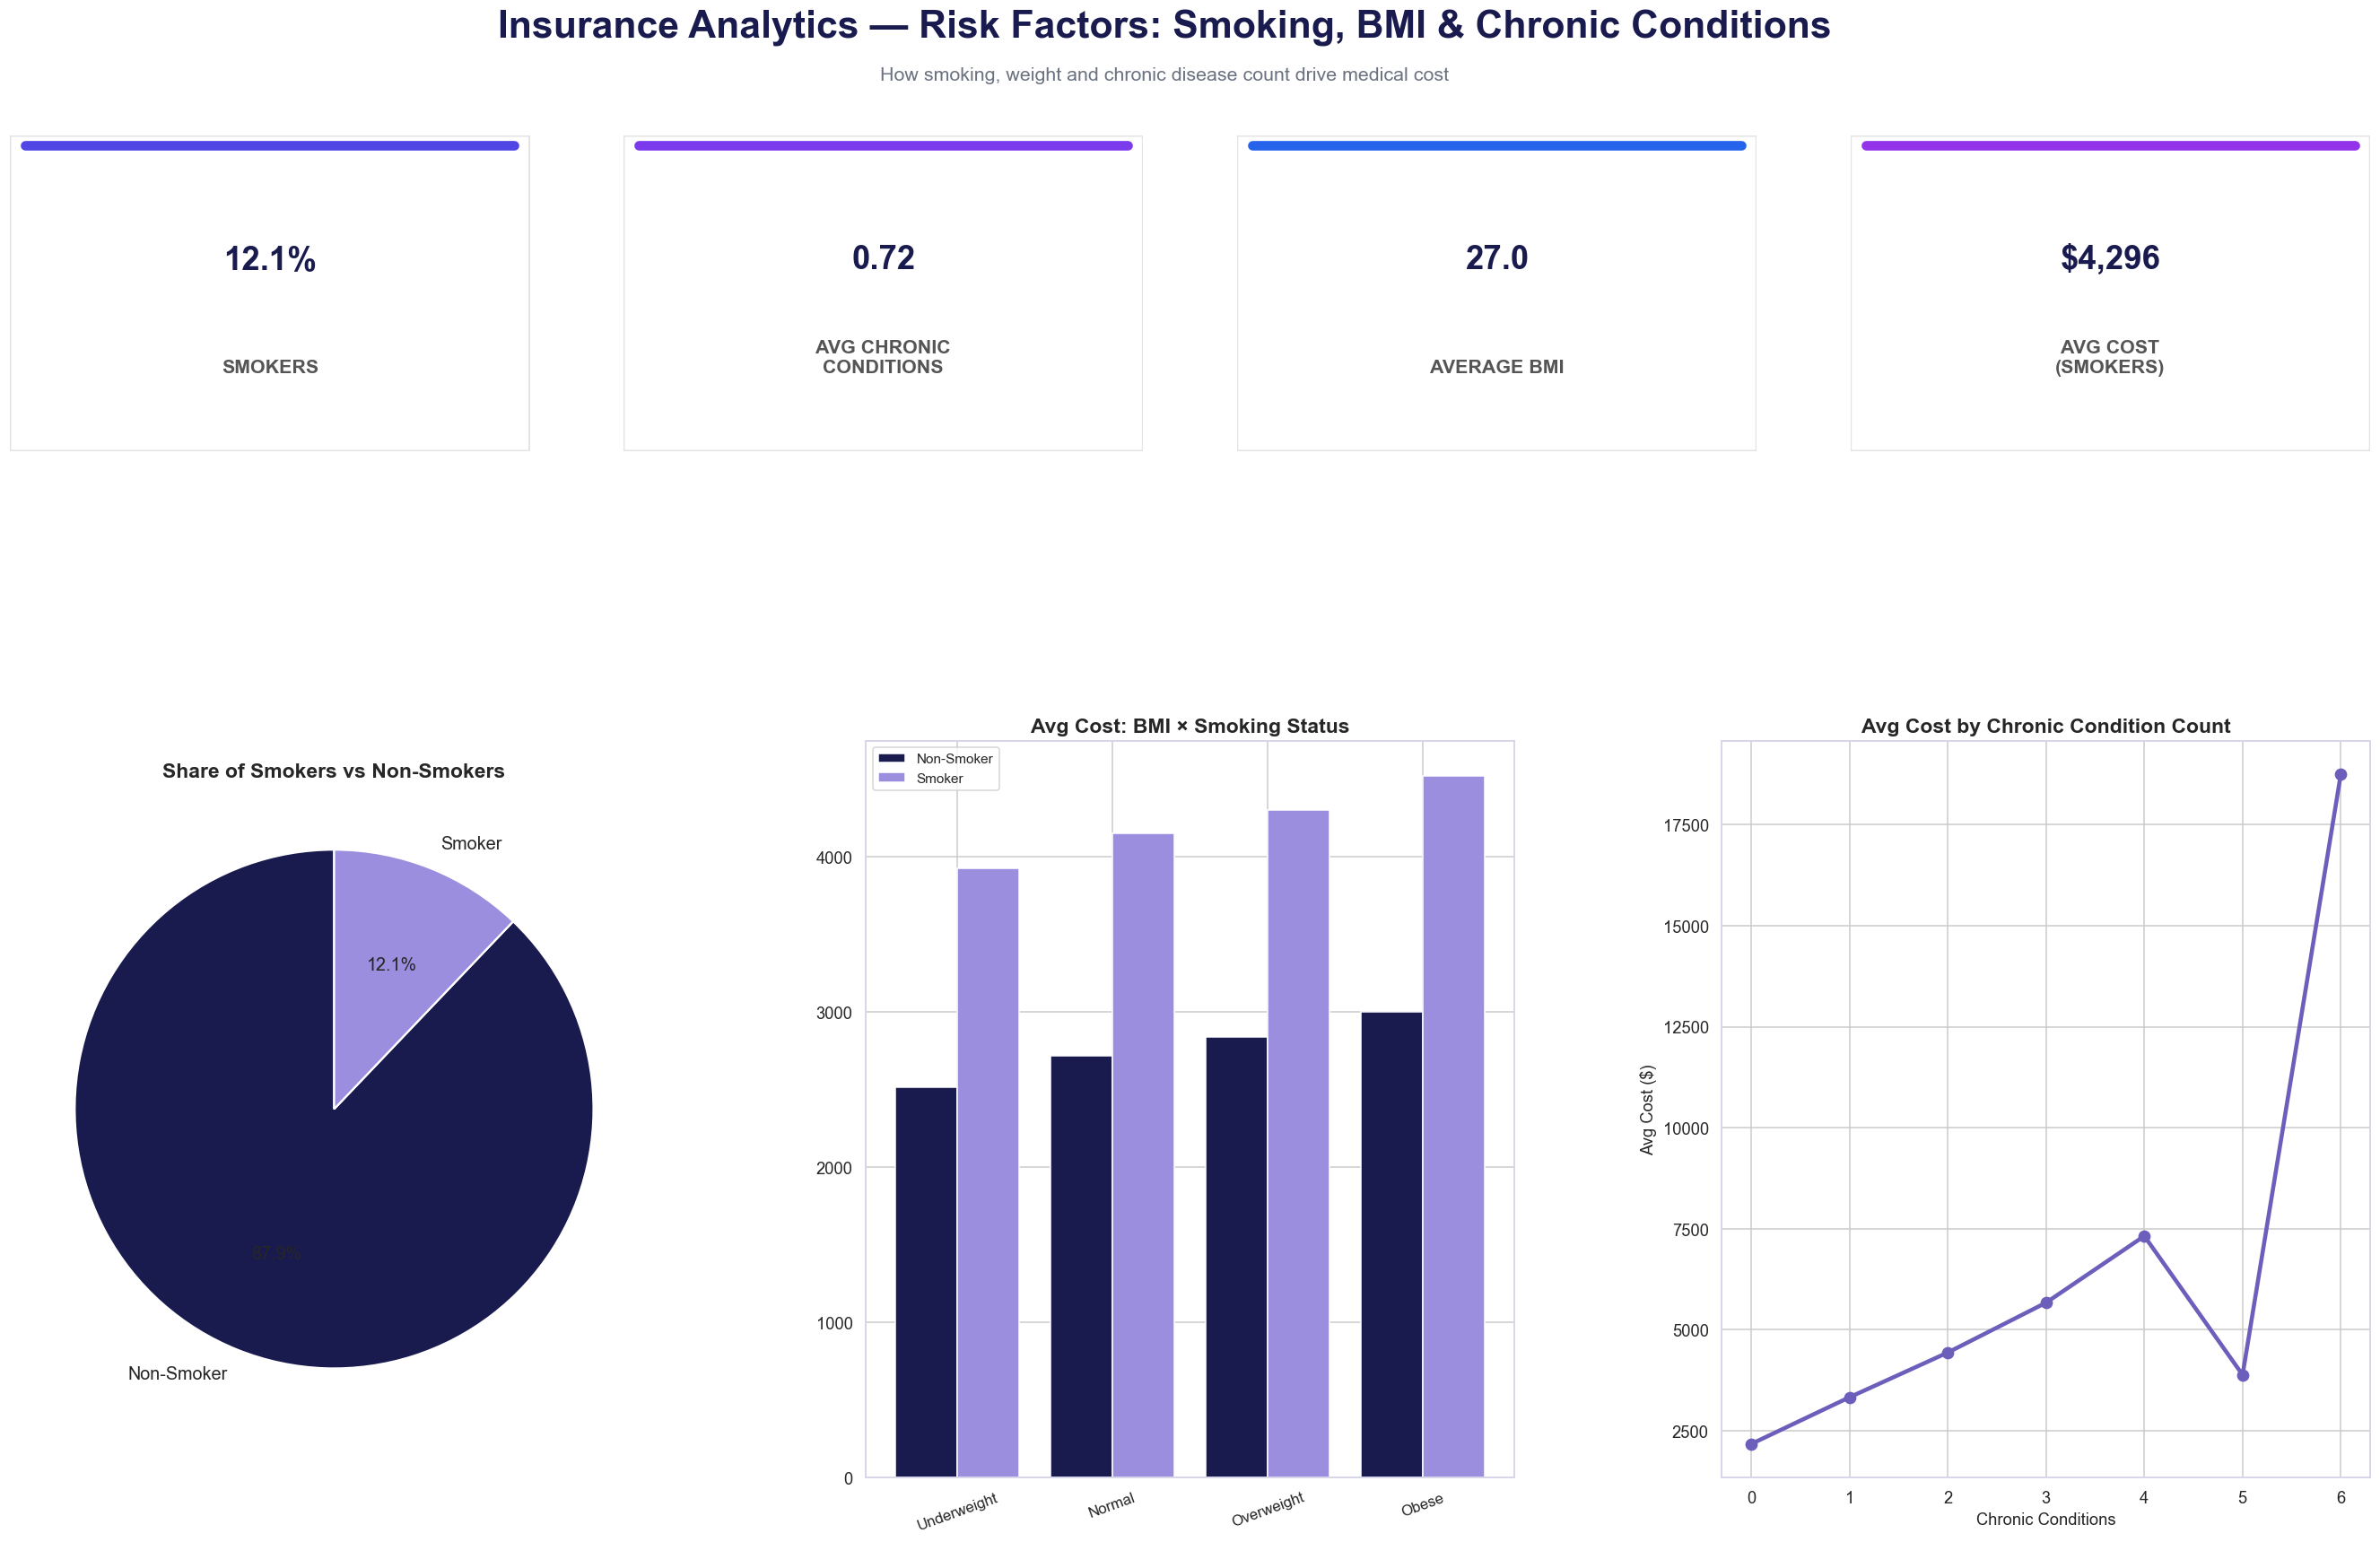

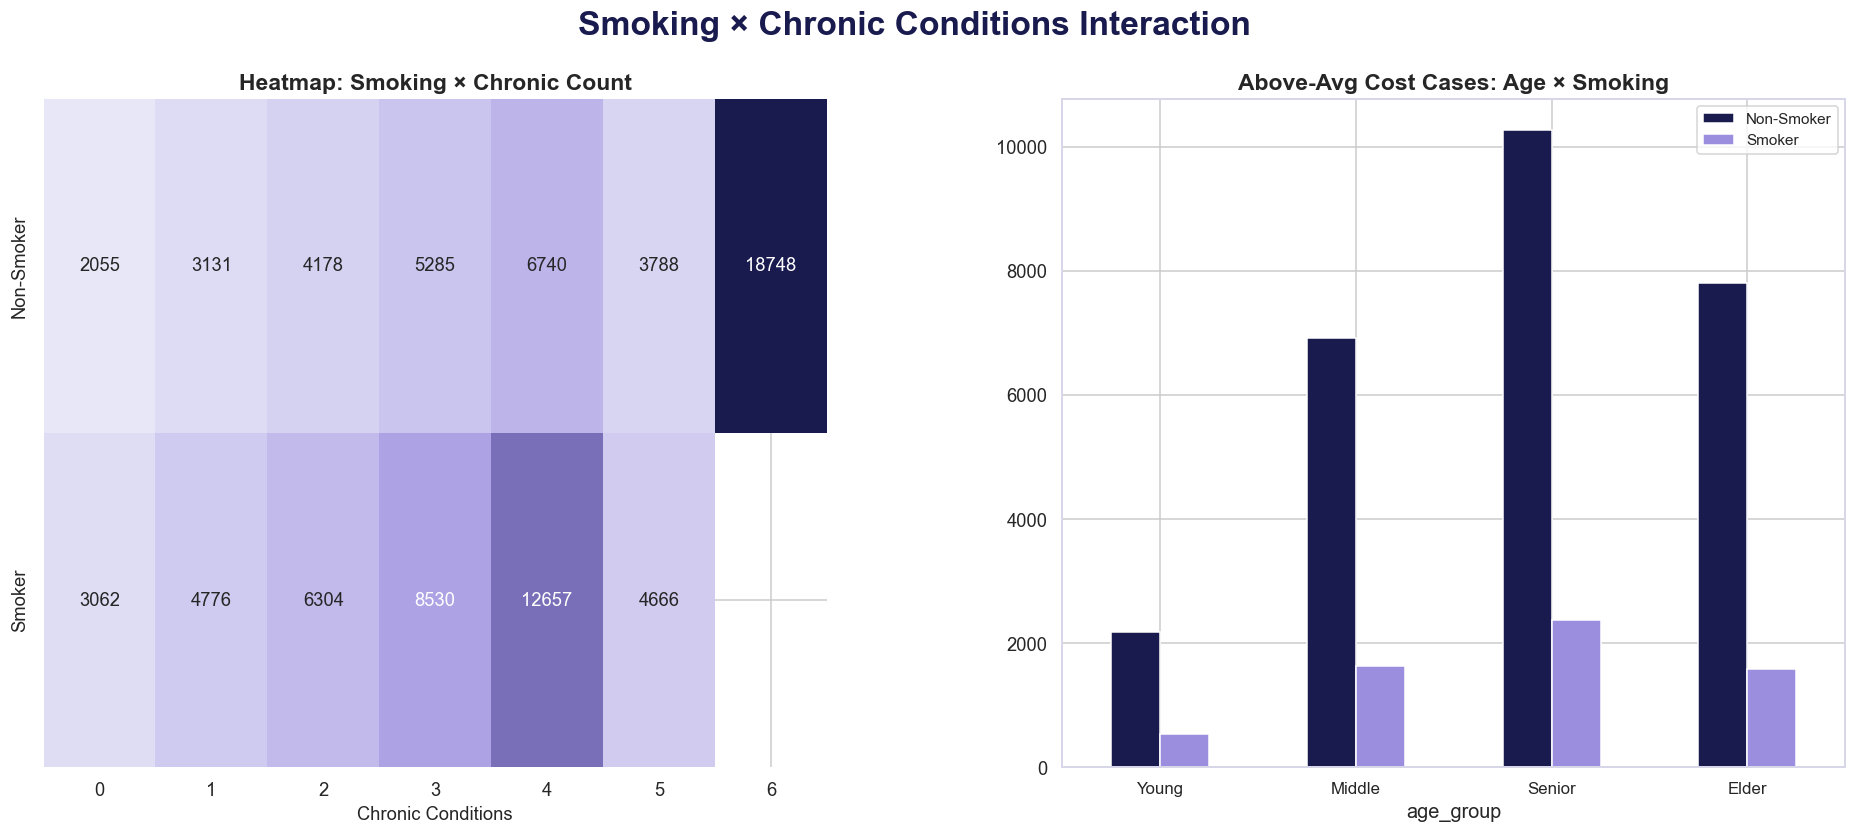

In [73]:
#  DASHBOARD 2: Risk Factors — Smoking, BMI & Chronic Conditions
fig2 = plt.figure(figsize=(26, 16), facecolor="white")
gs2 = GridSpec(2, 3, figure=fig2, height_ratios=[0.6, 1.4],
               hspace=0.55, wspace=0.32, top=0.90, bottom=0.05, left=0.05, right=0.97)

fig2.suptitle("Insurance Analytics — Risk Factors: Smoking, BMI & Chronic Conditions",
              fontsize=28, fontweight="bold", color=NAVY, y=0.98)
fig2.text(0.5, 0.935, "How smoking, weight and chronic disease count drive medical cost",
          ha="center", fontsize=14, color=GREY_TXT)

#  KPI Cards
from matplotlib.patches import FancyBboxPatch

titles = [
    "SMOKERS",
    "AVG CHRONIC\nCONDITIONS",
    "AVERAGE BMI",
    "AVG COST\n(SMOKERS)"
]

values = [
    f"{(df['smoker_label']=='Smoker').mean()*100:.1f}%",
    f"{df['chronic_count'].mean():.2f}",
    f"{df['bmi'].mean():.1f}",
    f"${df.loc[df['smoker_label']=='Smoker','annual_medical_cost'].mean():,.0f}"
]


card_colors = [
    "#4F46E5",
    "#7C3AED",
    "#2563EB",
    "#9333EA"
]

kpi_grid = gs2[0,:].subgridspec(1,4,wspace=.18)

for i in range(4):

    ax = fig2.add_subplot(kpi_grid[0,i])

    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

    ax.axis("off")

    card = FancyBboxPatch(
        (0.02,0.02),
        0.96,
        0.96,
        boxstyle="round,pad=0.02,rounding_size=18",
        linewidth=2,
        edgecolor="#E4E4E4",
        facecolor="white"
    )

    ax.add_patch(card)

    # colored line
    ax.plot(
        [0.03,0.97],
        [0.97,0.97],
        color=card_colors[i],
        linewidth=7,
        solid_capstyle="round"
    )


    # value
    ax.text(
        0.5,
        0.58,
        values[i],
        fontsize=24,
        fontweight="bold",
        color=NAVY,
        ha="center"
    )

    # title
    ax.text(
        0.5,
        0.25,
        titles[i],
        fontsize=14,
        fontweight="bold",
        color="#555555",
        ha="center"
    )
ax = fig2.add_subplot(gs2[1, 0])
counts = df["smoker_label"].value_counts()
ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90,
       textprops={"fontsize": 13},
       colors=navy_purple_colors(len(counts)), wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Share of Smokers vs Non-Smokers", fontsize=15)

ax = fig2.add_subplot(gs2[1, 1])
bmi_order = [b for b in ["Underweight", "Normal", "Overweight", "Obese"] if b in combo["bmi_category"].unique()]
smoke_labels = combo["smoker_label"].unique().tolist()
width = 0.8 / max(len(smoke_labels), 1)
x = np.arange(len(bmi_order))
colors = navy_purple_colors(len(smoke_labels))
for i, lbl in enumerate(smoke_labels):
    vals = [combo[(combo["smoker_label"] == lbl) & (combo["bmi_category"] == b)]["avg_cost"].values[0]
            if len(combo[(combo["smoker_label"] == lbl) & (combo["bmi_category"] == b)]) else 0
            for b in bmi_order]
    ax.bar(x + (i - (len(smoke_labels)-1)/2) * width, vals, width, label=lbl, color=colors[i])
ax.set_xticks(x); ax.set_xticklabels(bmi_order, rotation=20, fontsize=11)
ax.set_title("Avg Cost: BMI × Smoking Status", fontsize=15)
ax.legend(fontsize=10)

ax = fig2.add_subplot(gs2[1, 2])
ax.plot(chronic_analysis.index, chronic_analysis["avg_cost"], marker="o", markersize=8, color=PURPLE_DEEP, linewidth=3)
ax.set_title("Avg Cost by Chronic Condition Count", fontsize=15)
ax.set_xlabel("Chronic Conditions", fontsize=12); ax.set_ylabel("Avg Cost ($)", fontsize=12)

plt.savefig("Dashboard_2_Risk_Factors.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

fig2b = plt.figure(figsize=(18, 8), facecolor="white")
gs2b = GridSpec(1, 2, figure=fig2b, wspace=0.3, top=0.88, bottom=0.12, left=0.06, right=0.97)

fig2b.suptitle("Smoking × Chronic Conditions Interaction", fontsize=22, fontweight="bold", color=NAVY, y=0.98)

ax = fig2b.add_subplot(gs2b[0, 0])
if pivot_smoker_chronic.dropna(how="all").empty:
    ax.text(0.5, 0.5, "No data available\n(check smoker/chronic_count columns)",
            ha="center", va="center", fontsize=12, color=GREY_TXT)
    ax.set_xticks([]); ax.set_yticks([])
else:
    sns.heatmap(pivot_smoker_chronic, annot=True, fmt=".0f", cmap=NAVY_SEQ_CMAP, ax=ax, cbar=False,
                annot_kws={"fontsize": 12})
ax.set_title("Heatmap: Smoking × Chronic Count", fontsize=15)
ax.set_xlabel("Chronic Conditions", fontsize=12); ax.set_ylabel("")

ax = fig2b.add_subplot(gs2b[0, 1])
pivot_age_smoke = result.pivot(index="age_group", columns="smoker_label", values="high_cost_cases").fillna(0)
pivot_age_smoke.plot(kind="bar", ax=ax, color=navy_purple_colors(pivot_age_smoke.shape[1]))
ax.set_title("Above-Avg Cost Cases: Age × Smoking", fontsize=15)
ax.tick_params(axis="x", rotation=0, labelsize=11)
ax.legend(fontsize=10)

plt.savefig("Dashboard_2b_Heatmap_AgeSmoking.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()



## Dashboard 3: Financial & Risk Segmentation Analysis

This dashboard analyzes the financial performance and risk profile of the insurance dataset. It presents key performance indicators (KPIs) such as the average loss ratio, average annual premium, number of plan types, and high-risk members. The visualizations compare the loss ratio across insurance plans, identify the variables most strongly correlated with annual medical costs, and examine the average cost associated with different chronic diseases. In addition, the dashboard compares healthcare costs and utilization across network tiers and highlights the differences between high-risk and low/medium-risk members, providing valuable insights into the main financial and clinical cost drivers.

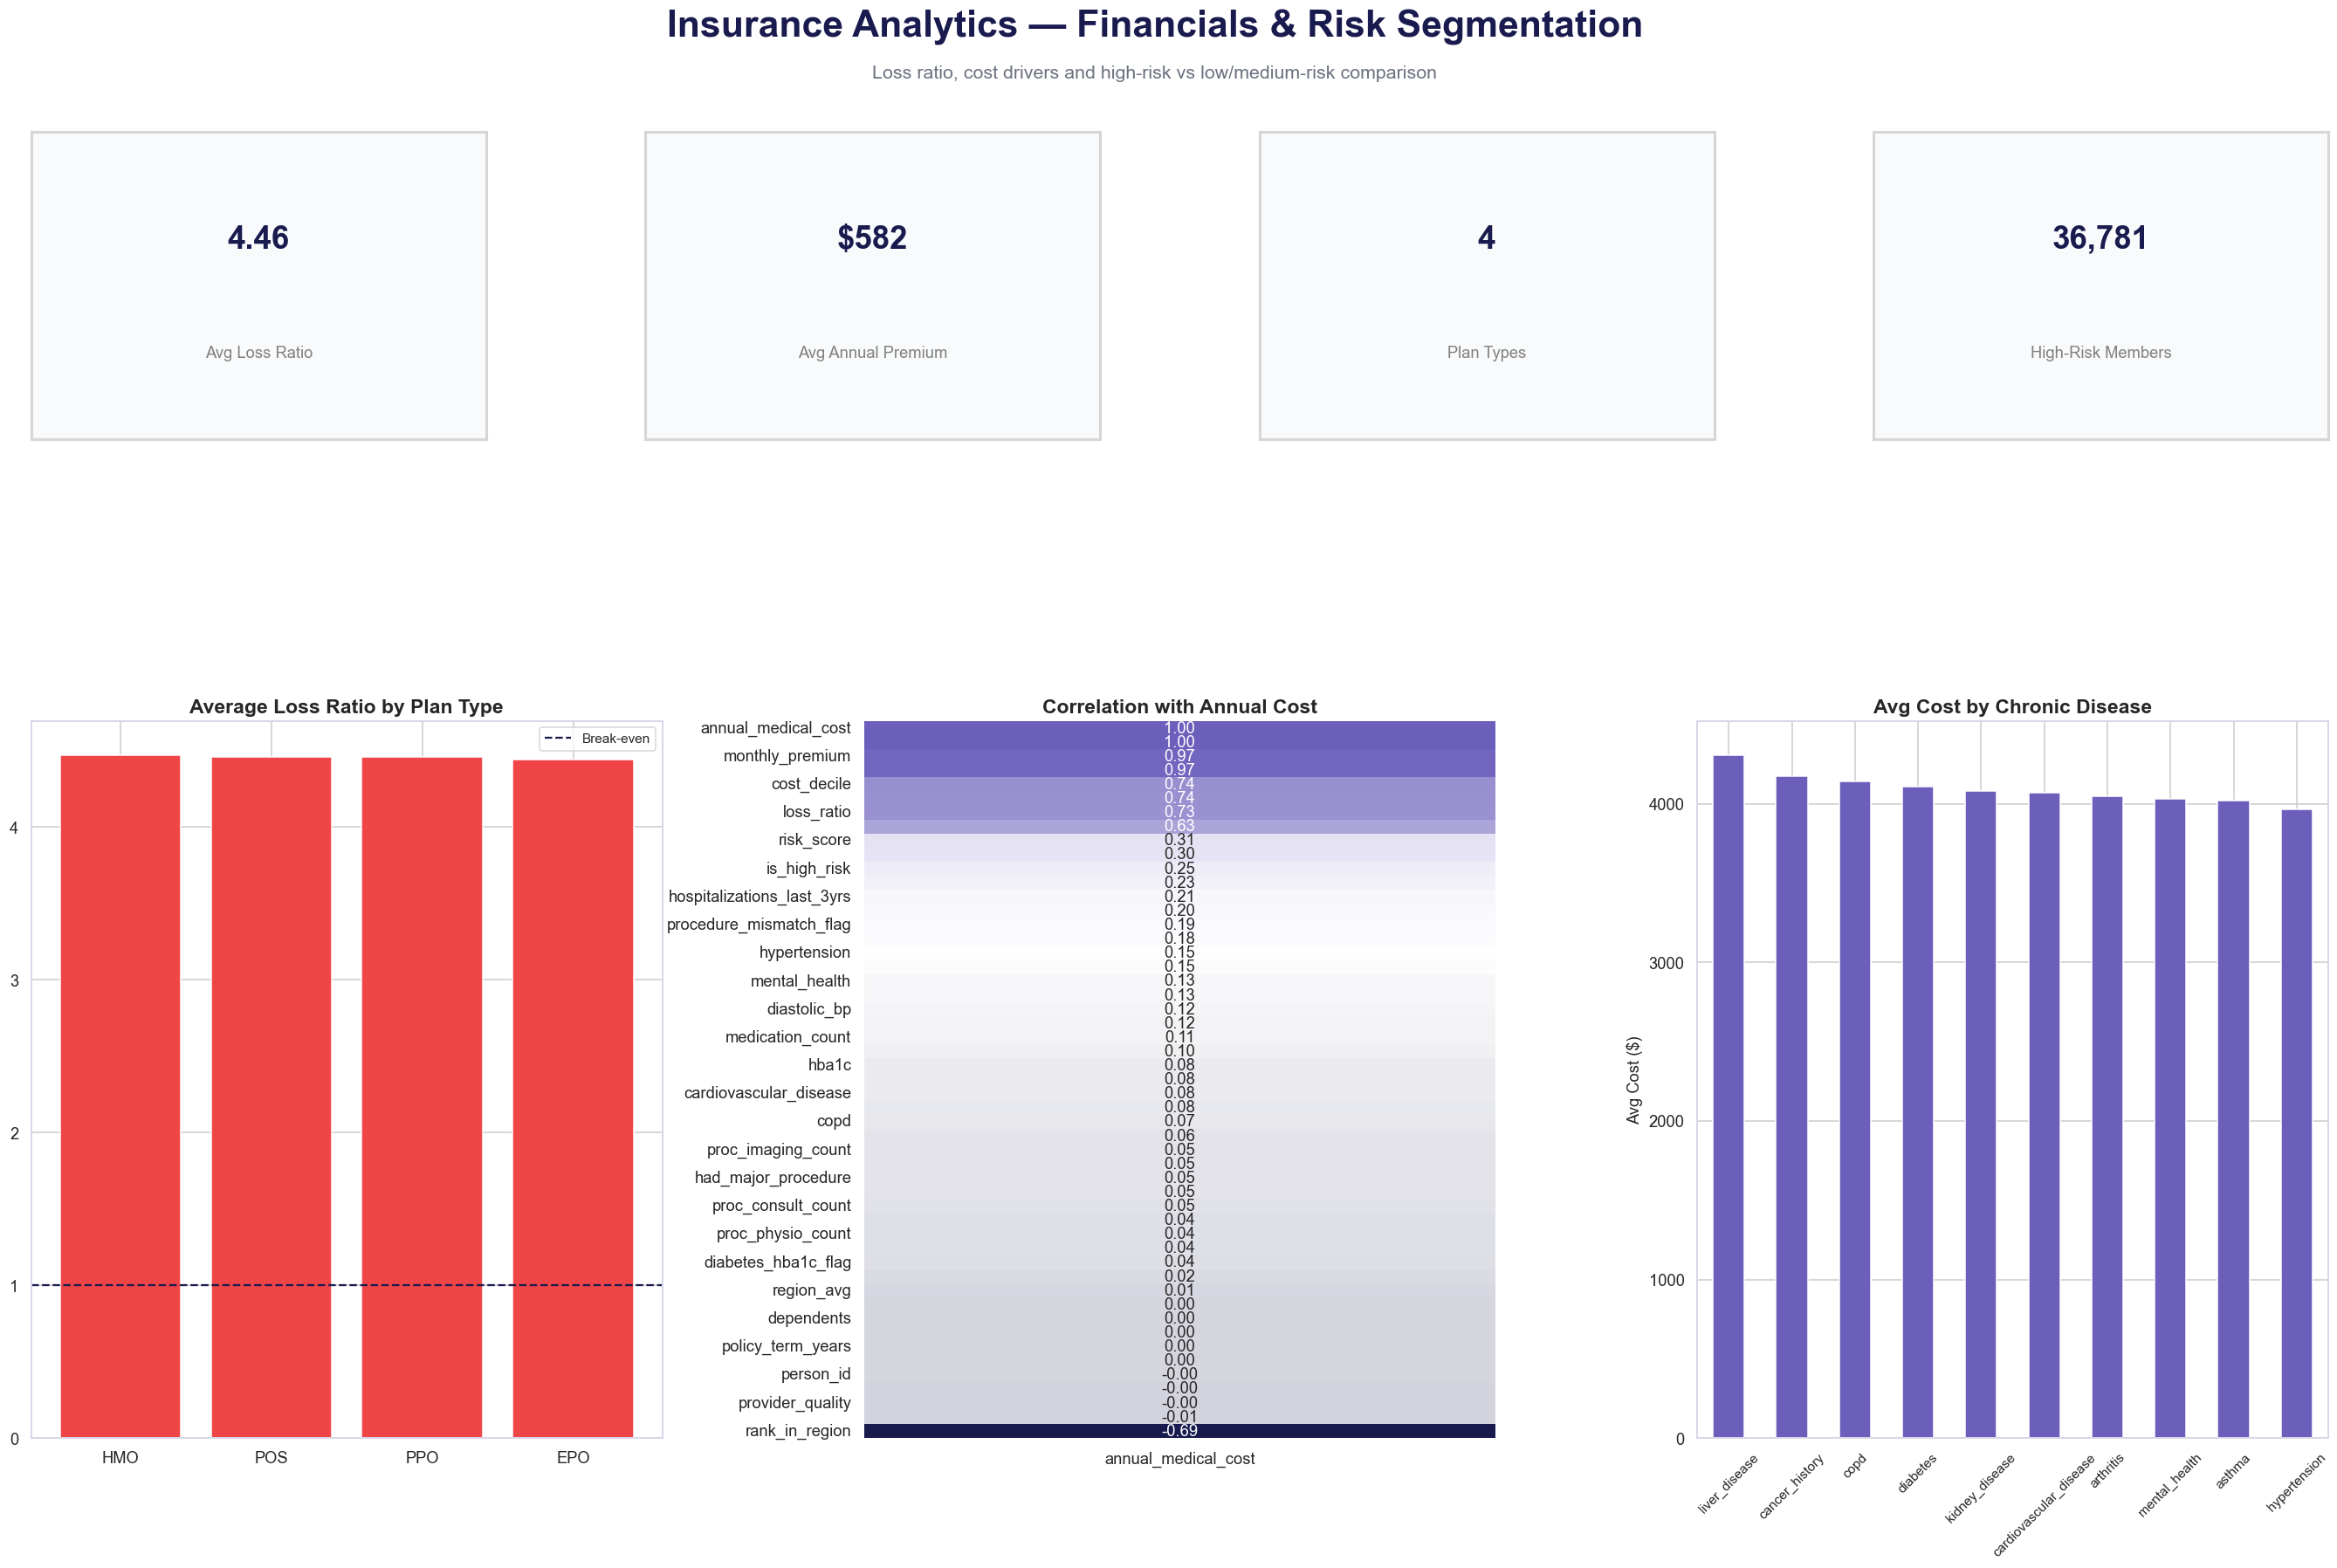

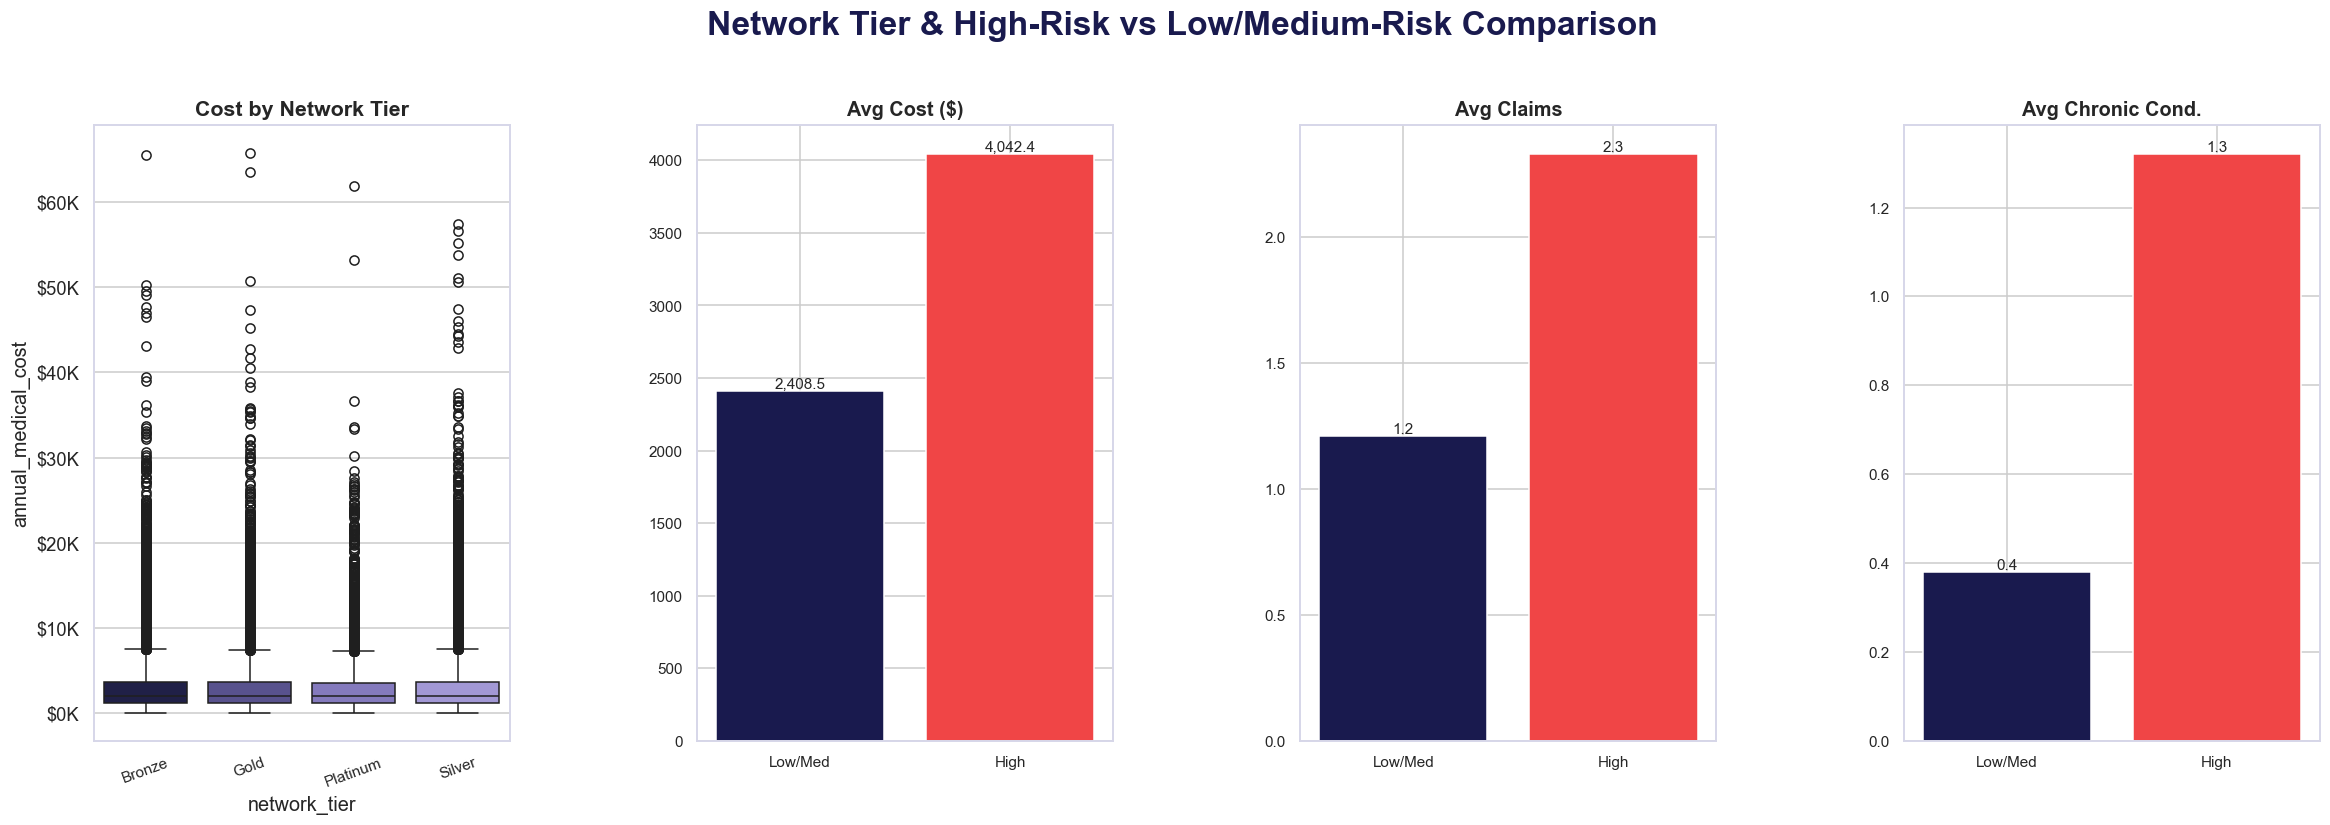

In [74]:

fig3 = plt.figure(figsize=(26, 16), facecolor="white")
gs3 = GridSpec(2, 3, figure=fig3, height_ratios=[0.6, 1.4],
               hspace=0.55, wspace=0.32, top=0.90, bottom=0.05, left=0.05, right=0.97)

fig3.suptitle("Insurance Analytics — Financials & Risk Segmentation", fontsize=28, fontweight="bold", color=NAVY, y=0.98)
fig3.text(0.5, 0.935, "Loss ratio, cost drivers and high-risk vs low/medium-risk comparison",
          ha="center", fontsize=14, color=GREY_TXT)
# KPI Cards
kpi_titles = [
    "Avg Loss Ratio",
    "Avg Annual Premium",
    "Plan Types",
    "High-Risk Members"
]

kpi_values = [
    f"{df['loss_ratio'].mean():.2f}",
    f"${df['annual_premium'].mean():,.0f}",
    f"{df['plan_type'].nunique()}",
    f"{(df[risk_col] == 1).sum():,}" if risk_col else "N/A"
]

kpi_grid = gs3[0, :].subgridspec(1, 4, wspace=0.35)

for i in range(4):

    ax = fig3.add_subplot(kpi_grid[0, i])

    ax.set_facecolor("#F8FAFC")

    for spine in ax.spines.values():
        spine.set_edgecolor("#D6D6D6")
        spine.set_linewidth(2)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(
        0.5,
        0.65,
        kpi_values[i],
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold",
        color=NAVY
    )

    ax.text(
        0.5,
        0.28,
        kpi_titles[i],
        ha="center",
        va="center",
        fontsize=12,
        color="gray"
    )
ax = fig3.add_subplot(gs3[1, 0])
colors = [RED if v > 1 else PURPLE for v in loss_by_plan["avg_loss_ratio"]]
ax.bar(loss_by_plan.index, loss_by_plan["avg_loss_ratio"], color=colors)
ax.axhline(1.0, color=NAVY, linestyle="--", linewidth=1.5, label="Break-even")
ax.set_title("Average Loss Ratio by Plan Type", fontsize=15)
ax.legend(fontsize=10)

ax = fig3.add_subplot(gs3[1, 1])
sns.heatmap(corr_target, annot=True, fmt=".2f", cmap=NAVY_PURPLE_CMAP, ax=ax, cbar=False,
            annot_kws={"fontsize": 12})
ax.set_title("Correlation with Annual Cost", fontsize=15)
ax.set_ylabel("")

ax = fig3.add_subplot(gs3[1, 2])
disease_cost.plot(kind="bar", ax=ax, color=PURPLE_DEEP)
ax.set_title("Avg Cost by Chronic Disease", fontsize=15)
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.set_ylabel("Avg Cost ($)", fontsize=12)

plt.savefig("Dashboard_3_Financials_RiskSegmentation.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# CELL 9 — DASHBOARD 3b: Network Tier & High vs Low/Medium Risk
fig3b = plt.figure(figsize=(22, 8), facecolor="white")
gs3b = GridSpec(1, 4, figure=fig3b, wspace=0.45, top=0.85, bottom=0.15, left=0.05, right=0.97)

fig3b.suptitle("Network Tier & High-Risk vs Low/Medium-Risk Comparison", fontsize=22, fontweight="bold", color=NAVY, y=0.98)

ax = fig3b.add_subplot(gs3b[0, 0])
tiers = df["network_tier"].dropna().unique().tolist()
sns.boxplot(data=df, x="network_tier", y="annual_medical_cost", hue="network_tier",
            palette=navy_purple_colors(len(tiers)), ax=ax, legend=False)
ax.set_title("Cost by Network Tier", fontsize=14)
ax.tick_params(axis="x", rotation=20, labelsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

if risk_col and len(risk_analysis2) >= 2:
    metrics = ["avg_cost", "avg_claims", "avg_chronic"]
    mlabels = ["Avg Cost ($)", "Avg Claims", "Avg Chronic Cond."]
    low = risk_analysis2.iloc[0][metrics].values
    high = risk_analysis2.iloc[1][metrics].values
    for i, (lo, hi, ml) in enumerate(zip(low, high, mlabels)):
        sax = fig3b.add_subplot(gs3b[0, i + 1])
        bars = sax.bar(["Low/Med", "High"], [lo, hi], color=[NAVY, RED])
        sax.set_title(ml, fontsize=13)
        sax.tick_params(labelsize=10)
        for b, v in zip(bars, [lo, hi]):
            sax.text(b.get_x() + b.get_width()/2, v, f"{v:,.1f}", ha="center", va="bottom", fontsize=10)

plt.savefig("Dashboard_3b_NetworkTier_RiskComparison.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## Dashboard 4: Executive Insights

This dashboard provides a comprehensive executive view of the insurance dataset by highlighting the most important cost and risk insights. It identifies the members with the highest medical costs, compares annual premiums with medical expenses, and analyzes the distribution of the loss ratio. It also examines the correlation between numerical variables and medical costs, ranks chronic diseases based on their average cost, and visualizes the combined impact of BMI and smoking status on healthcare expenses. These visualizations help decision-makers quickly identify the main cost drivers and high-risk patterns within the insured population.

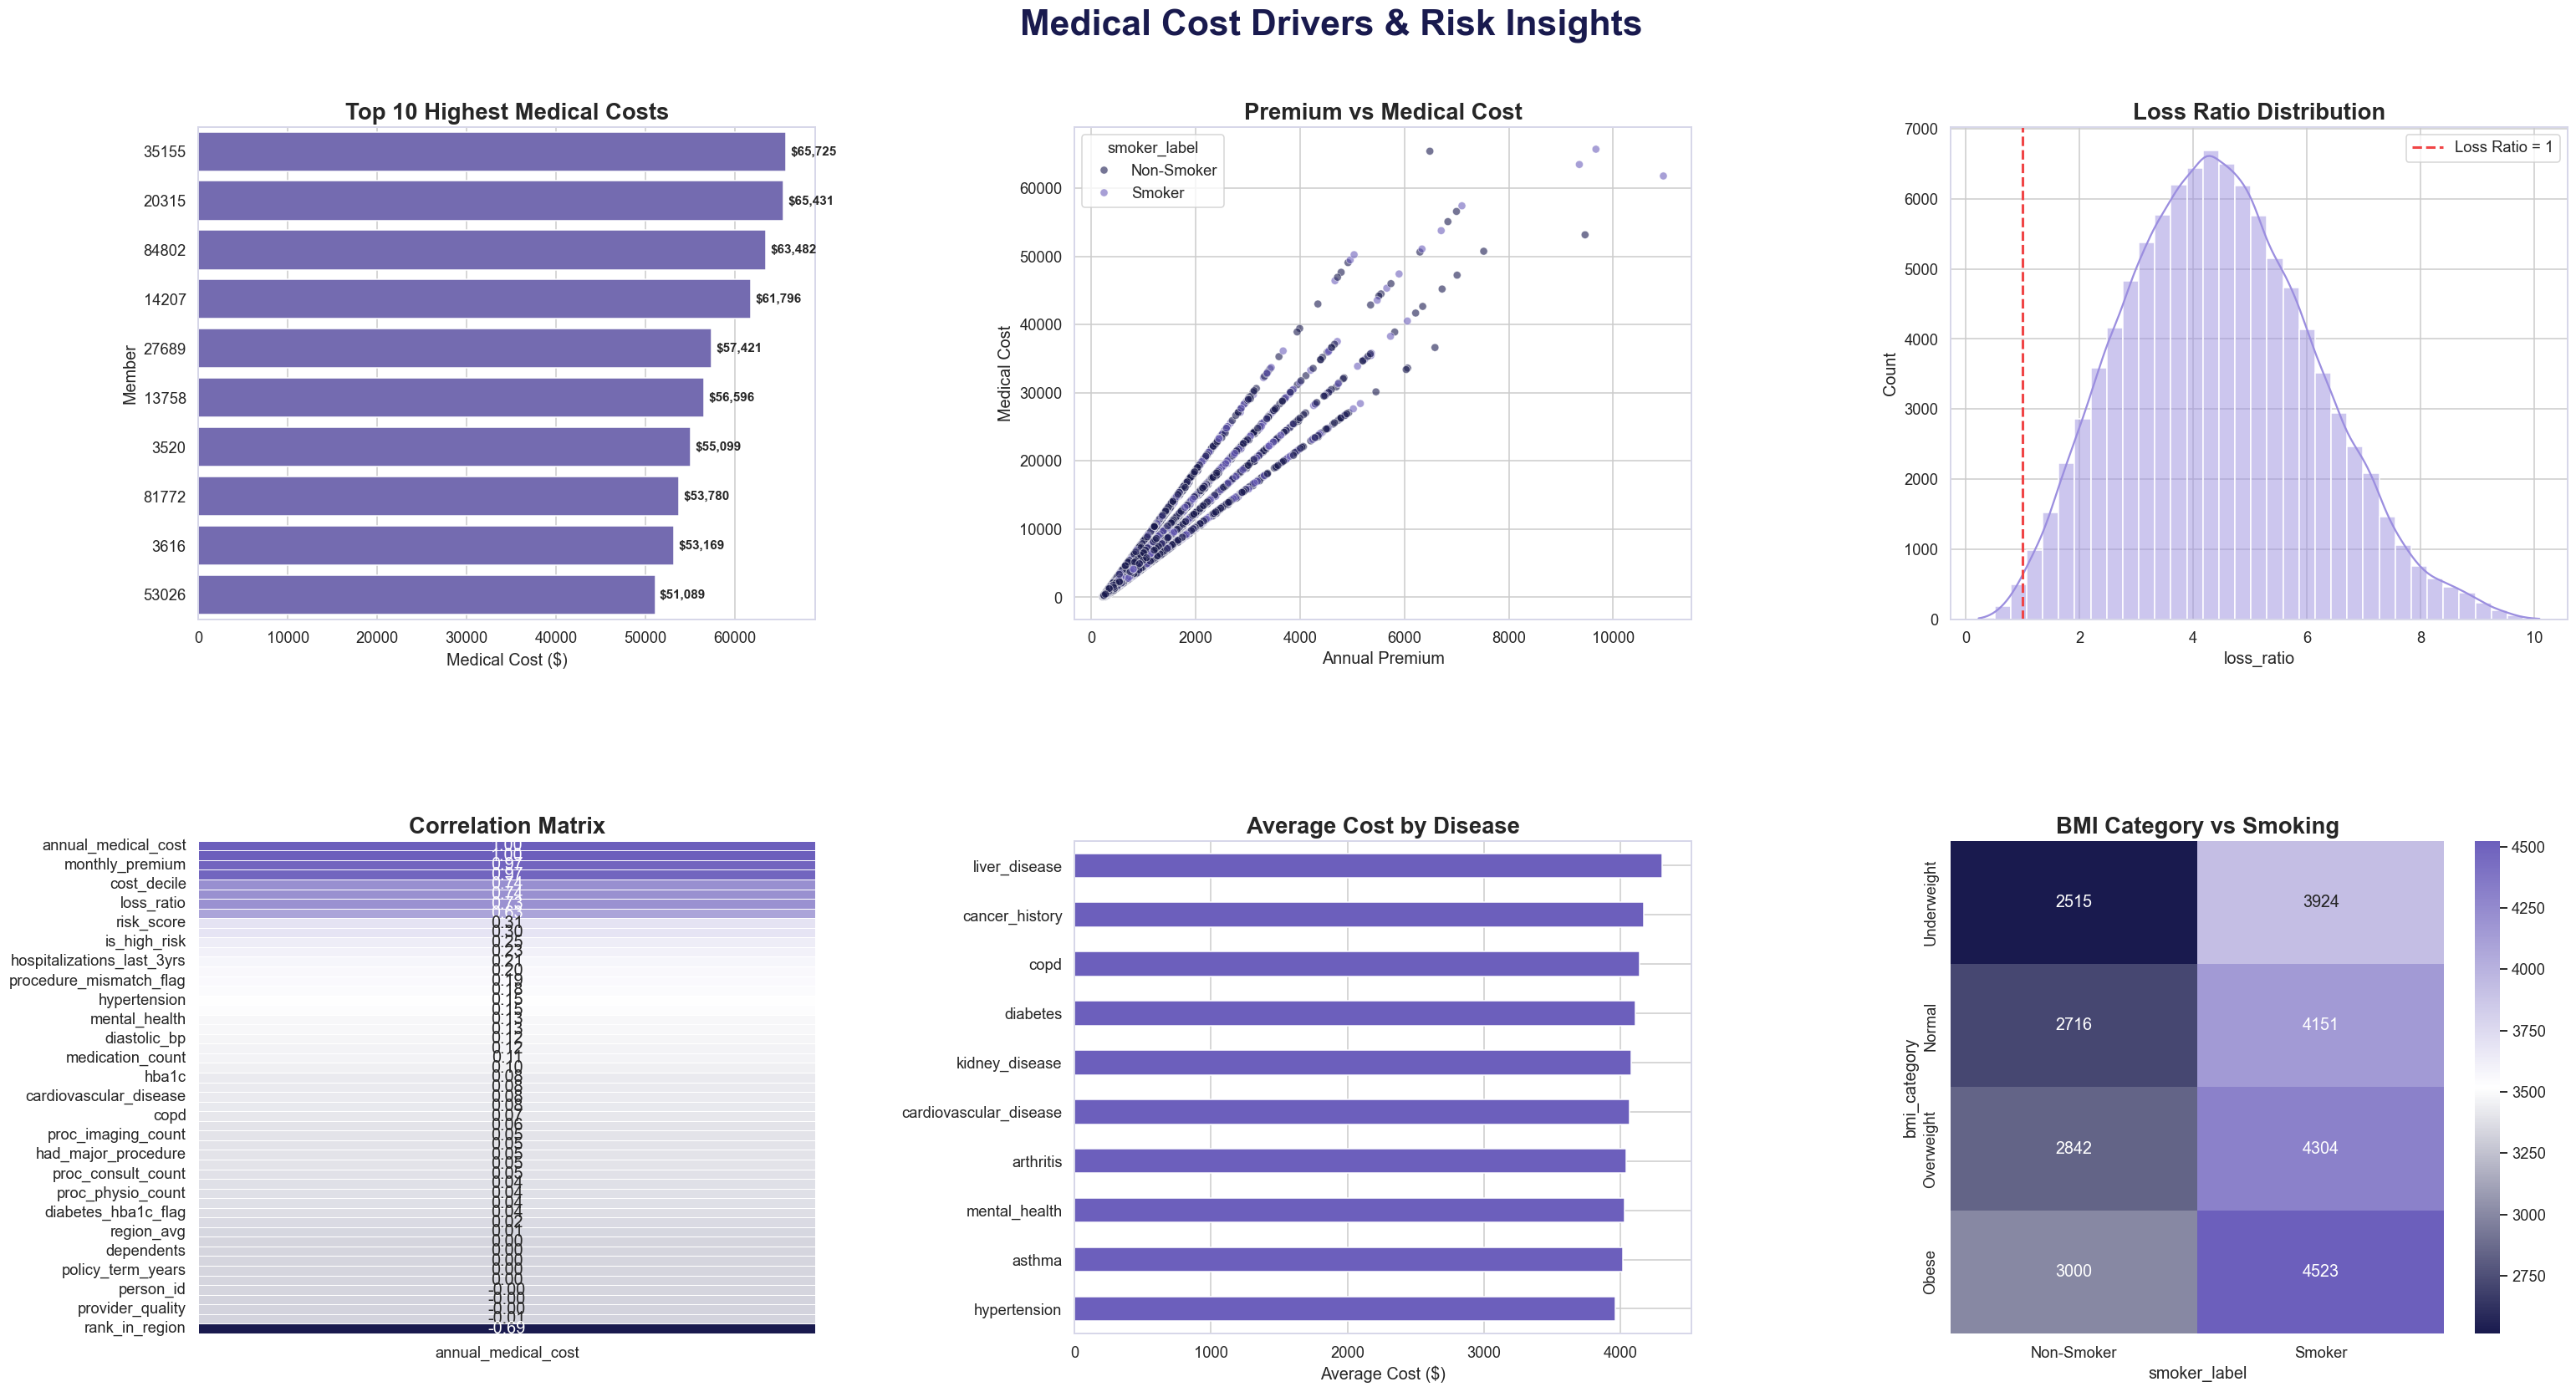

In [75]:

# DASHBOARD 4: Executive Insights Dashboard

fig4 = plt.figure(figsize=(28,16), facecolor="white")

gs4 = GridSpec(
    2,3,
    figure=fig4,
    hspace=0.45,
    wspace=0.42,
    top=0.90,
    bottom=0.08,
    left=0.06,
    right=0.98
)


fig4.suptitle(
        "Medical Cost Drivers & Risk Insights",
    fontsize=28,
    fontweight="bold",
    color=NAVY
)

# 1. Top 10 Highest Medical Cost Members
ax = fig4.add_subplot(gs4[0,0])

top10 = df.nlargest(10, "annual_medical_cost")

sns.barplot(
    data=top10,
    x="annual_medical_cost",
    y=top10.index.astype(str),
    color=PURPLE_DEEP,
    ax=ax
)

ax.set_title("Top 10 Highest Medical Costs")
ax.set_xlabel("Medical Cost ($)")
ax.set_ylabel("Member")

for i,v in enumerate(top10["annual_medical_cost"]):
    ax.text(
        v+500,
        i,
        f"${v:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# 2. Premium vs Medical Cost

ax = fig4.add_subplot(gs4[0,1])

sns.scatterplot(
    data=df,
    x="annual_premium",
    y="annual_medical_cost",
    hue="smoker_label",
    palette=[NAVY,PURPLE_DEEP],
    alpha=0.6,
    ax=ax
)

ax.set_title("Premium vs Medical Cost")
ax.set_xlabel("Annual Premium")
ax.set_ylabel("Medical Cost")

# 3. Loss Ratio Distribution

ax = fig4.add_subplot(gs4[0,2])

sns.histplot(
    df["loss_ratio"],
    bins=35,
    kde=True,
    color=PURPLE,
    ax=ax
)

ax.axvline(
    1,
    color=RED,
    linestyle="--",
    linewidth=2,
    label="Loss Ratio = 1"
)

ax.legend()

ax.set_title("Loss Ratio Distribution")

# 4. Correlation Heatmap

ax = fig4.add_subplot(gs4[1,0])

corr = (
    df.select_dtypes(include=np.number)
      .corr()["annual_medical_cost"]
      .sort_values(ascending=False)
      .to_frame()
)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=NAVY_PURPLE_CMAP,
    linewidths=.5,
    cbar=False,
    ax=ax
)

ax.set_title("Correlation Matrix")

# 5. Disease Ranking

ax = fig4.add_subplot(gs4[1,1])

disease_cost.sort_values().plot.barh(
    color=PURPLE_DEEP,
    ax=ax
)

ax.set_title("Average Cost by Disease")
ax.set_xlabel("Average Cost ($)")

# 6. BMI × Smoking

ax = fig4.add_subplot(gs4[1,2])

pivot = df.pivot_table(
    values="annual_medical_cost",
    index="bmi_category",
    columns="smoker_label",
    aggfunc="mean"
)

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap=NAVY_PURPLE_CMAP,
    ax=ax
)

ax.set_title("BMI Category vs Smoking")

plt.savefig(
    "Dashboard_4_Executive_Insights.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

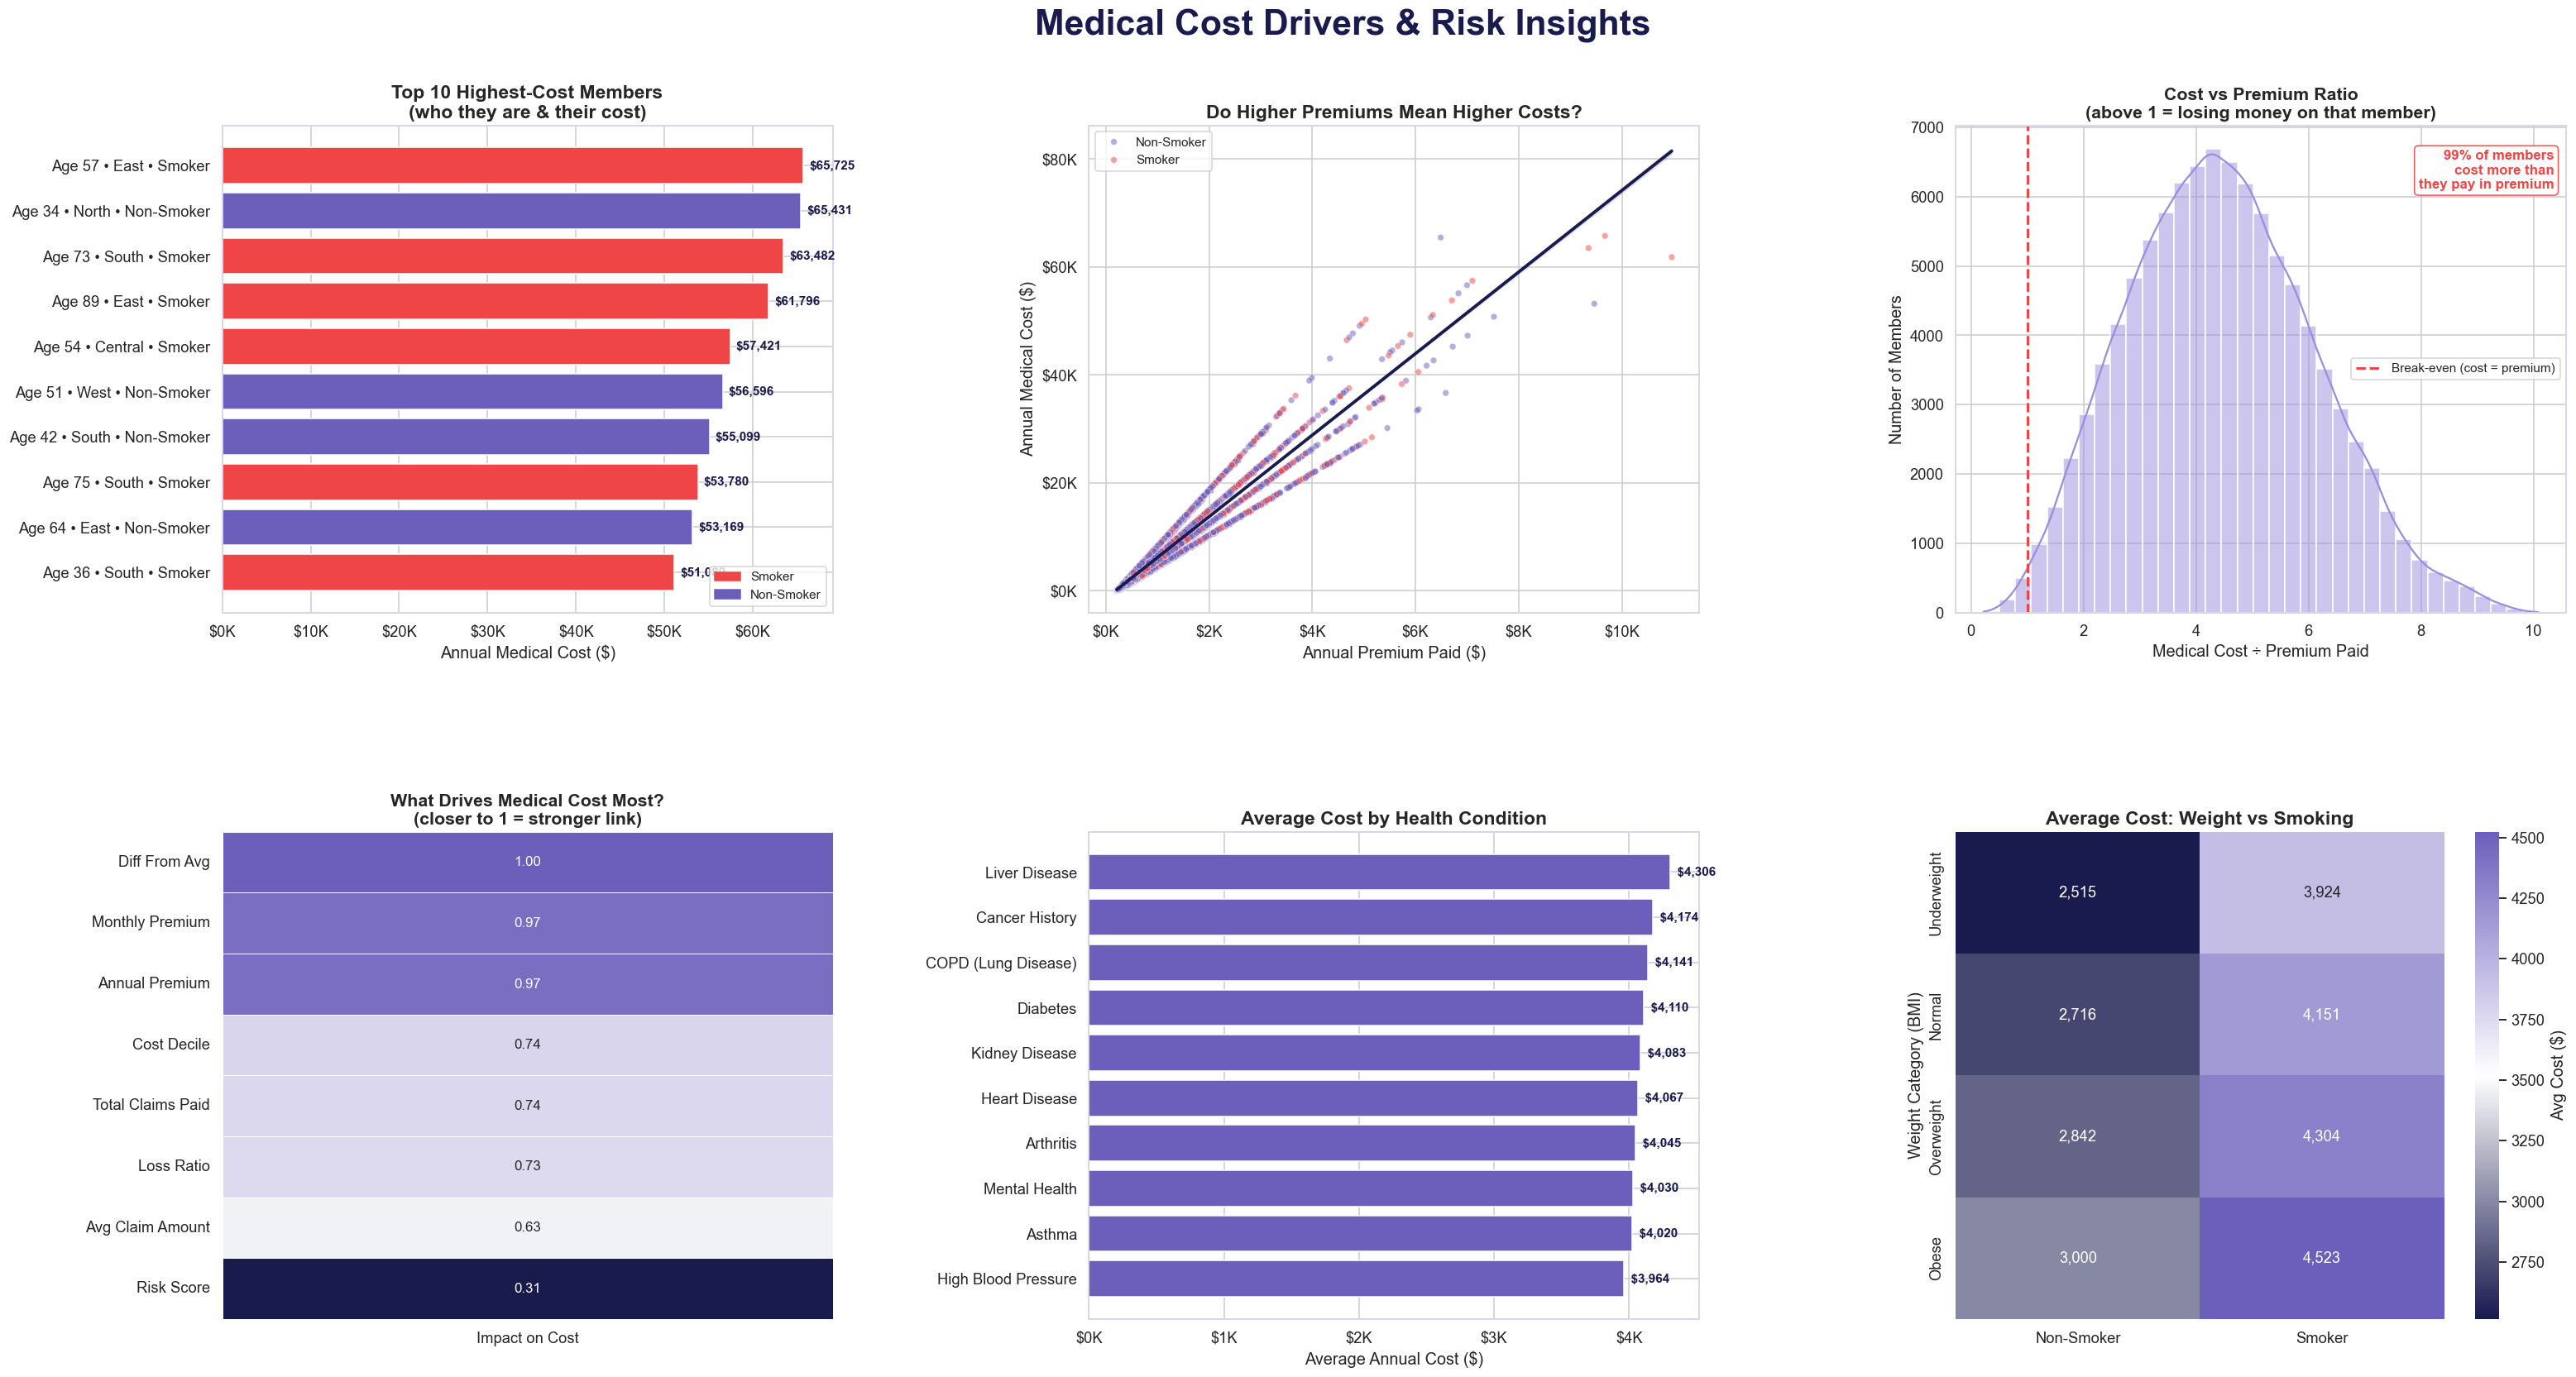

In [ ]:
# ===========================================================
# DASHBOARD 4: Executive Insights Dashboard
# ===========================================================
fig4 = plt.figure(figsize=(28, 16), facecolor="white")

gs4 = GridSpec(
    2, 3,
    figure=fig4,
    hspace=0.45,
    wspace=0.42,
    top=0.90,
    bottom=0.08,
    left=0.06,
    right=0.98
)

fig4.suptitle(
    "Medical Cost Drivers & Risk Insights",
    fontsize=28,
    fontweight="bold",
    color=NAVY
)

# -----------------------------------------------------------
# 1. Top 10 Highest Medical Cost Members
# -----------------------------------------------------------
ax = fig4.add_subplot(gs4[0, 0])

top10 = df.nlargest(10, "annual_medical_cost").copy()
top10 = top10.sort_values("annual_medical_cost", ascending=True)

top10["label"] = (
    "Age " + top10["age"].astype(int).astype(str)
    + " • " + top10["region"].astype(str)
    + " • " + top10["smoker_label"].astype(str)
)

colors_top10 = [RED if s == "Smoker" else PURPLE_DEEP for s in top10["smoker_label"]]
bars = ax.barh(top10["label"], top10["annual_medical_cost"], color=colors_top10)

for bar, v in zip(bars, top10["annual_medical_cost"]):
    ax.text(v + (top10["annual_medical_cost"].max() * 0.01), bar.get_y() + bar.get_height()/2,
            f"${v:,.0f}", va="center", fontsize=10, fontweight="bold", color=NAVY)

ax.set_title("Top 10 Highest-Cost Members\n(who they are & their cost)", fontsize=15)
ax.set_xlabel("Annual Medical Cost ($)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=RED, label="Smoker"), Patch(color=PURPLE_DEEP, label="Non-Smoker")],
          loc="lower right", fontsize=10)

# -----------------------------------------------------------
# 2. Premium vs Medical Cost — with trend line
# -----------------------------------------------------------
ax = fig4.add_subplot(gs4[0, 1])

sns.scatterplot(
    data=df, x="annual_premium", y="annual_medical_cost",
    hue="smoker_label", palette=[PURPLE_DEEP, RED],
    alpha=0.5, ax=ax, s=25
)
sns.regplot(
    data=df, x="annual_premium", y="annual_medical_cost",
    scatter=False, ax=ax, color=NAVY, line_kws={"linewidth": 2.5}
)

ax.set_title("Do Higher Premiums Mean Higher Costs?", fontsize=15)
ax.set_xlabel("Annual Premium Paid ($)")
ax.set_ylabel("Annual Medical Cost ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.legend(title="", fontsize=10)

# -----------------------------------------------------------
# 3. Loss Ratio Distribution — explained in plain words
# -----------------------------------------------------------
ax = fig4.add_subplot(gs4[0, 2])

sns.histplot(df["loss_ratio"], bins=35, kde=True, color=PURPLE, ax=ax)
ax.axvline(1, color=RED, linestyle="--", linewidth=2, label="Break-even (cost = premium)")

pct_over = (df["loss_ratio"] > 1).mean() * 100
ax.text(0.98, 0.95, f"{pct_over:.0f}% of members\ncost more than\nthey pay in premium",
        transform=ax.transAxes, ha="right", va="top", fontsize=11,
        color=RED, fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor=RED, alpha=0.9))

ax.set_title("Cost vs Premium Ratio\n(above 1 = losing money on that member)", fontsize=14)
ax.set_xlabel("Medical Cost ÷ Premium Paid")
ax.set_ylabel("Number of Members")
ax.legend(fontsize=10)

# -----------------------------------------------------------
# 4. Correlation Heatmap — plain-English labels
# -----------------------------------------------------------
ax = fig4.add_subplot(gs4[1, 0])

friendly_names = {
    "age": "Age", "bmi": "BMI (Weight)", "chronic_count": "Chronic Conditions",
    "claims_count": "Number of Claims", "annual_premium": "Annual Premium",
    "income": "Income", "hba1c": "Blood Sugar (HbA1c)", "systolic_bp": "Blood Pressure",
    "medication_count": "Medications Taken", "visits_last_year": "Doctor Visits/Year",
    "hospitalizations_last_3yrs": "Hospital Stays", "risk_score": "Risk Score",
}

corr = (
    df.select_dtypes(include=np.number).corr()["annual_medical_cost"]
      .drop("annual_medical_cost")
      .sort_values(ascending=False)
      .head(8)
      .to_frame(name="Impact on Cost")
)
corr.index = [friendly_names.get(i, i.replace("_", " ").title()) for i in corr.index]

sns.heatmap(corr, annot=True, fmt=".2f", cmap=NAVY_PURPLE_CMAP,
            linewidths=.5, cbar=False, ax=ax, annot_kws={"fontsize": 11})
ax.set_title("What Drives Medical Cost Most?\n(closer to 1 = stronger link)", fontsize=14)
ax.set_xlabel("")

# -----------------------------------------------------------
# 5. Disease Ranking — readable names
# -----------------------------------------------------------
ax = fig4.add_subplot(gs4[1, 1])

disease_friendly = {
    "hypertension": "High Blood Pressure", "diabetes": "Diabetes", "asthma": "Asthma",
    "copd": "COPD (Lung Disease)", "cardiovascular_disease": "Heart Disease",
    "cancer_history": "Cancer History", "kidney_disease": "Kidney Disease",
    "liver_disease": "Liver Disease", "arthritis": "Arthritis", "mental_health": "Mental Health",
}
disease_cost_readable = disease_cost.rename(index=disease_friendly).sort_values()

bars = ax.barh(disease_cost_readable.index, disease_cost_readable.values, color=PURPLE_DEEP)
for bar, v in zip(bars, disease_cost_readable.values):
    ax.text(v, bar.get_y() + bar.get_height()/2, f"  ${v:,.0f}", va="center", fontsize=10, fontweight="bold", color=NAVY)

ax.set_title("Average Cost by Health Condition", fontsize=15)
ax.set_xlabel("Average Annual Cost ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

# -----------------------------------------------------------
# 6. BMI × Smoking — $ formatted
# -----------------------------------------------------------
ax = fig4.add_subplot(gs4[1, 2])

pivot = df.pivot_table(
    values="annual_medical_cost", index="bmi_category",
    columns="smoker_label", aggfunc="mean", observed=False
)

sns.heatmap(pivot, annot=True, fmt=",.0f", cmap=NAVY_PURPLE_CMAP, ax=ax,
            annot_kws={"fontsize": 12}, cbar_kws={"label": "Avg Cost ($)"})
ax.set_title("Average Cost: Weight vs Smoking", fontsize=15)
ax.set_xlabel("")
ax.set_ylabel("Weight Category (BMI)")

# -----------------------------------------------------------
# SAVE & SHOW 
# -----------------------------------------------------------
plt.savefig(
    "Dashboard_4_Executive_Insights.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()